# Task 2A: Depot Demand Forecast

Forecast weekly `pred_total_volume_m3` and `pred_chilled_volume_m3` for every **depot × brand × ISO week** in 2026 weeks 14–23.

See `Task_2a.md` for the full plan. This notebook is built one phase at a time.

## Phase 0: Setup and framing

### Problem definition

| Item | Definition |
|---|---|
| **Unit** | depot × brand × ISO week. 2 depots × 3 brands = 6 series |
| **Target 1:** `pred_total_volume_m3` | `sum(order_volume_m3)` over all orders whose **`order_date`** falls in that ISO week |
| **Target 2:** `pred_chilled_volume_m3` | Same sum, restricted to `temp_requirement == 'chilled'`. This is 0 for Style and Tech |
| **Orders counted** | Every order, whatever its `dispatch_status` (attempted, deferred, not_run) |
| **Week mapping** | `iso_year` / `iso_week` taken from `calendar.csv`, never computed by hand |
| **History** | `deliveries_train.csv` (to 2026 wk 7) + `task1_test_inputs.csv` (2026 wk 8–13) |
| **Forecast origin** | End of 2026 ISO week 13. Nothing after this point may be used as a feature |
| **Horizon** | h = 1…10 weeks ahead (2026 wk 14–23), so 6 series × 10 weeks = 60 rows |

### Evaluation metric

The booklet does not say how Task 2A is scored, so we use:

- **WAPE** = Σ|y − ŷ| / Σ|y|. This is the main metric for comparing models. It is scale-free, so Peliyagoda Fresh (~950 m³/wk) does not drown out Kandy Tech (~20 m³/wk) when we compare across series, and it is still an absolute-error metric.
- **MAE** per series, for diagnosis in m³.
- **RMSE**, reported alongside because it penalises large misses, which happen mostly in festival weeks.

Validation always uses the real horizon structure: train up to a week-13-style origin, then forecast the next 10 weeks. Random splits are never used (see Phase 6).

### Imports and paths

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)


def find_project_root(start: Path) -> Path:
    # Walk up from the notebook folder until data/raw is found.
    for p in [start, *start.parents]:
        if (p / "data" / "raw").is_dir():
            return p
    raise FileNotFoundError("Could not find project root containing data/raw")


ROOT = find_project_root(Path.cwd().resolve())
RAW = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"
MODELS = ROOT / "models" / "task2a"
for d in (PROCESSED, MODELS):
    d.mkdir(parents=True, exist_ok=True)

FILES = {
    "deli_train":      RAW / "Training Data" / "deliveries_train.csv",
    "t1_inputs":  RAW / "Test Data" / "task1_test_inputs.csv",
    "calendar":   RAW / "General Data" / "calendar.csv",
    "outlets":    RAW / "General Data" / "outlets.csv",
    "t2a_inputs": RAW / "Test Data" / "task2a_test_inputs.csv",
    "template":   RAW / "Submission Templates" / "submission_task2a.csv",
}

print("ROOT:", ROOT)
for k, p in FILES.items():
    print(f"  {k:<11} {'OK ' if p.exists() else 'MISSING'}  {p.relative_to(ROOT)}")
assert all(p.exists() for p in FILES.values()), "A required input file is missing"


ROOT: D:\Competetions\Rootcode Tech-Trithlon'2026\Datathon
  deli_train  OK   data\raw\Training Data\deliveries_train.csv
  t1_inputs   OK   data\raw\Test Data\task1_test_inputs.csv
  calendar    OK   data\raw\General Data\calendar.csv
  outlets     OK   data\raw\General Data\outlets.csv
  t2a_inputs  OK   data\raw\Test Data\task2a_test_inputs.csv
  template    OK   data\raw\Submission Templates\submission_task2a.csv


### Problem constants

In [2]:
DEPOTS = ["Kandy", "Peliyagoda"]
BRANDS = ["Fresh", "Style", "Tech"]
SERIES = [(d, b) for d in DEPOTS for b in BRANDS]
CHILLED_BRANDS = {"Fresh"}          # Style and Tech chilled volume is always 0

ORIGIN = (2026, 13)                 # last ISO week of known history
FORECAST_WEEKS = [(2026, w) for w in range(14, 24)]
HORIZON = len(FORECAST_WEEKS)       # 10

DATE_FORMAT = "%m/%d/%Y"            # every raw file (calendar and orders) uses M/D/YYYY
TARGETS = ["pred_total_volume_m3", "pred_chilled_volume_m3"]
KEYS = ["depot", "brand", "iso_year", "iso_week"]
SEED = 42
np.random.seed(SEED)


### Check the framing against the test inputs and template

In [3]:
t2a = pd.read_csv(FILES["t2a_inputs"])
template = pd.read_csv(FILES["template"])

assert len(t2a) == len(SERIES) * HORIZON == 60
assert set(map(tuple, t2a[["depot", "brand"]].values)) == set(SERIES)
assert set(map(tuple, t2a[["iso_year", "iso_week"]].values)) == set(FORECAST_WEEKS)
assert not t2a.duplicated(KEYS).any()
assert template["row_id"].tolist() == t2a["row_id"].tolist(), "Template row order differs from test inputs"
assert list(template.columns) == ["row_id", *TARGETS]

print(f"Test inputs: {len(t2a)} rows, {t2a[['depot','brand']].drop_duplicates().shape[0]} series, "
      f"weeks {t2a.iso_week.min()}-{t2a.iso_week.max()} of {t2a.iso_year.unique()[0]}")
print("Template row_id order matches test inputs.")
t2a.pivot_table(index=["depot", "brand"], columns="iso_week", values="row_id", aggfunc="first")


Test inputs: 60 rows, 6 series, weeks 14-23 of 2026
Template row_id order matches test inputs.


iso_week             14     15     16     17     18     19     20     21     22     23
depot      brand                                                                      
Kandy      Fresh  W0000  W0006  W0012  W0018  W0024  W0030  W0036  W0042  W0048  W0054
           Style  W0001  W0007  W0013  W0019  W0025  W0031  W0037  W0043  W0049  W0055
           Tech   W0002  W0008  W0014  W0020  W0026  W0032  W0038  W0044  W0050  W0056
Peliyagoda Fresh  W0003  W0009  W0015  W0021  W0027  W0033  W0039  W0045  W0051  W0057
           Style  W0004  W0010  W0016  W0022  W0028  W0034  W0040  W0046  W0052  W0058
           Tech   W0005  W0011  W0017  W0023  W0029  W0035  W0041  W0047  W0053  W0059

In [4]:
import pandas as pd

ss = pd.read_csv(FILES["deli_train"])

# Create a helper column that only contains the volume if it is chilled (otherwise 0)
ss['chilled_volume_m3'] = ss['order_volume_m3'].where(ss['temp_requirement'] == 'chilled', 0)

# Group by date, depot, and brand to calculate the sums for all combinations
summary = ss.groupby(['order_date', 'depot', 'brand']).agg(
    total_volume_m3=('order_volume_m3', 'sum'),
    total_chilled_volume_m3=('chilled_volume_m3', 'sum')
).reset_index()

# Calculate the chilled share (handling potential division by zero by filling with 0)
summary['chilled_share'] = (summary['total_chilled_volume_m3'] / summary['total_volume_m3']).fillna(0)

# Optional: If you want to view the specific result for '1/1/2024', 'Kandy', and 'Fresh'
specific_filter = summary[
    (summary['order_date'] == '1/2/2024') & 
    (summary['depot'] == 'Kandy') & 
    (summary['brand'] == 'Fresh')
]

print(specific_filter)

    order_date  depot  brand  total_volume_m3  total_chilled_volume_m3  chilled_share
136   1/2/2024  Kandy  Fresh           68.582                   23.045       0.336021


### Evaluation helpers

Used in every later phase to score baselines, models and backtest folds.

In [5]:
def wape(y, yhat):
    y, yhat = np.asarray(y, float), np.asarray(yhat, float)
    denom = np.abs(y).sum()
    return np.nan if denom == 0 else np.abs(y - yhat).sum() / denom


def mae(y, yhat):
    return float(np.mean(np.abs(np.asarray(y, float) - np.asarray(yhat, float))))


def rmse(y, yhat):
    return float(np.sqrt(np.mean((np.asarray(y, float) - np.asarray(yhat, float)) ** 2)))


def score(df, y="y", yhat="yhat", by=None):
    # WAPE / MAE / RMSE overall, or per group when `by` is given (e.g. ["depot","brand"] or "horizon").
    def _row(g):
        return pd.Series({"n": len(g), "WAPE": wape(g[y], g[yhat]),
                          "MAE": mae(g[y], g[yhat]), "RMSE": rmse(g[y], g[yhat])})
    if by is None:
        return _row(df).to_frame("all").T
    return df.groupby(by, observed=True).apply(_row, include_groups=False)


# Quick self-test
_t = pd.DataFrame({"g": ["a", "a", "b", "b"], "y": [100, 100, 10, 10], "yhat": [90, 110, 15, 5]})
assert np.isclose(wape(_t.y, _t.yhat), 30 / 220)
assert np.isclose(mae(_t.y, _t.yhat), 7.5)
assert np.isclose(rmse(_t.y, _t.yhat), np.sqrt((100 + 100 + 25 + 25) / 4))
score(_t, by="g")


,n,WAPE,MAE,RMSE
g,,,,
a,2.0,0.1,10.0,10.0
b,2.0,0.5,5.0,5.0


### Phase 0 done

- Folders: `notebooks/`, `models/task2a/`, `data/processed/`
- Problem, targets, origin, horizon and metrics are fixed above
- The test inputs (60 rows, 6 series, 2026 wk 14–23) and the template row order are verified

**Next: Phase 1, loading and cleaning the data.**

## Phase 1: Load and clean the data

Steps:
1. Load and validate the calendar.
2. Union `deliveries_train.csv` with `task1_test_inputs.csv`, keeping only order-side columns and adding a `source` tag.
3. Parse every date with an explicit `M/D/YYYY` format.
4. Run integrity checks. Any failure stops the notebook.
5. Keep **every** `dispatch_status`, and measure how much volume would land in the wrong week if `dispatch_date` were used.
6. Join `iso_year` / `iso_week` from the calendar on **`order_date`**.
7. Add `chilled_vol` and save `data/processed/orders_task2a.parquet` and `data/processed/calendar.parquet`.

### 1.1 Calendar

In [6]:
cal = pd.read_csv(FILES["calendar"])
cal["date"] = pd.to_datetime(cal["date"], format=DATE_FORMAT)
cal["festival"] = cal["festival"].fillna("")
cal = cal.sort_values("date").reset_index(drop=True)

iso = cal["date"].dt.isocalendar()
cal_checks = {
    "dates unique":                         cal["date"].is_unique,
    "daily and gap-free":                   (cal["date"].diff().dropna() == pd.Timedelta(days=1)).all(),
    "iso_year/iso_week match ISO standard": ((iso["year"] == cal["iso_year"]) & (iso["week"] == cal["iso_week"])).all(),
    "dow matches date":                     (cal["date"].dt.dayofweek == cal["dow"]).all(),
    "Sundays never operating":              (cal.loc[cal["dow"] == 6, "is_operating"] == 0).all(),
    "covers all forecast weeks":            set(FORECAST_WEEKS) <= set(map(tuple, cal[["iso_year", "iso_week"]].values)),
}
for k, v in cal_checks.items():
    print(f"  [{'PASS' if v else 'FAIL'}] {k}")
assert all(cal_checks.values())
print(f"\nCalendar: {cal.date.min().date()} -> {cal.date.max().date()} ({len(cal)} days)")
print("Non-operating days that are not Sundays:")
display(cal.loc[(cal.is_operating == 0) & (cal.dow != 6), ["date", "dow_name", "iso_year", "iso_week", "festival", "is_holiday"]])


  [PASS] dates unique
  [PASS] daily and gap-free
  [PASS] iso_year/iso_week match ISO standard
  [PASS] dow matches date
  [PASS] Sundays never operating
  [PASS] covers all forecast weeks

Calendar: 2024-01-01 -> 2026-06-28 (910 days)
Non-operating days that are not Sundays:


,date,dow_name,iso_year,iso_week,festival,is_holiday
103,2024-04-13,Sat,2024,15,new_year,1
121,2024-05-01,Wed,2024,18,,1
359,2024-12-25,Wed,2024,52,christmas,1
469,2025-04-14,Mon,2025,16,new_year,1
470,2025-04-15,Tue,2025,16,,1
486,2025-05-01,Thu,2025,18,,1
724,2025-12-25,Thu,2025,52,christmas,1
833,2026-04-13,Mon,2026,16,new_year,1
834,2026-04-14,Tue,2026,16,,1
851,2026-05-01,Fri,2026,18,vesak,1


### 1.2 Load and union the order files

In [7]:
ORDER_COLS = ["delivery_id", "order_date", "dispatch_date", "dispatch_status", "outlet_id", "brand",
              "district", "depot", "temp_requirement", "order_units", "order_weight_kg", "order_volume_m3"]
# Route, vehicle and time-window columns describe supply (how orders were delivered), not demand, so they are dropped.

train_raw = pd.read_csv(FILES["deli_train"])
t1_raw = pd.read_csv(FILES["t1_inputs"])
assert list(train_raw.columns) == list(t1_raw.columns), "Train and Task 1 test inputs have different columns"

orders = pd.concat(
    [train_raw[ORDER_COLS].assign(source="train"), t1_raw[ORDER_COLS].assign(source="t1_inputs")],
    ignore_index=True,
)
for c in ["order_date", "dispatch_date"]:
    orders[c] = pd.to_datetime(orders[c], format=DATE_FORMAT)   # raises if any value does not match
for c in ["depot", "brand", "temp_requirement", "dispatch_status", "source"]:
    orders[c] = orders[c].astype("category")

print(f"train: {len(train_raw):,} rows | t1_inputs: {len(t1_raw):,} rows | union: {len(orders):,} rows")
orders.groupby("source", observed=True).agg(
    rows=("delivery_id", "size"),
    first_order=("order_date", "min"),
    last_order=("order_date", "max"),
    volume_m3=("order_volume_m3", "sum"),
)


train: 92,307 rows | t1_inputs: 5,014 rows | union: 97,321 rows


,rows,first_order,last_order,volume_m3
source,,,,
t1_inputs,5014,2026-02-16,2026-03-28,10767.324
train,92307,2024-01-01,2026-02-14,191599.874


### 1.3 Integrity checks

In [8]:
outlets = pd.read_csv(FILES["outlets"])
chk = orders.merge(outlets[["outlet_id", "brand", "depot", "district"]], on="outlet_id", how="left",
                   suffixes=("", "_ref"), indicator=True)
cal_dates = set(cal["date"])
op_dates = set(cal.loc[cal.is_operating == 1, "date"])
not_run = orders["dispatch_status"] == "not_run"

checks = {
    "delivery_id unique across both files":          orders["delivery_id"].is_unique,
    "no missing values in order columns":            orders.drop(columns="dispatch_date").notna().all().all(),
    "dispatch_date missing only for not_run":        orders["dispatch_date"].isna().eq(not_run).all(),
    "every order_date is in the calendar":           orders["order_date"].isin(cal_dates).all(),
    "every order_date is an operating day":          orders["order_date"].isin(op_dates).all(),
    "order_volume_m3 > 0":                           (orders["order_volume_m3"] > 0).all(),
    "order_units > 0 and order_weight_kg > 0":       ((orders["order_units"] > 0) & (orders["order_weight_kg"] > 0)).all(),
    "dispatch_date >= order_date":                   (orders["dispatch_date"].dropna() >= orders.loc[~not_run, "order_date"]).all(),
    "only known depots / brands":                    orders["depot"].isin(DEPOTS).all() and orders["brand"].isin(BRANDS).all(),
    "only Fresh has chilled orders":                 (orders.loc[orders.temp_requirement == "chilled", "brand"] == "Fresh").all(),
    "every outlet_id exists in outlets.csv":         (chk["_merge"] == "both").all(),
    "brand/depot/district match outlets.csv":        ((chk.brand == chk.brand_ref) & (chk.depot == chk.depot_ref)
                                                      & (chk.district == chk.district_ref)).all(),
    "max 1 order per outlet x date x temperature":   not orders.duplicated(["outlet_id", "order_date", "temp_requirement"]).any(),
    "no order dates overlap between the two files":  orders.loc[orders.source == "train", "order_date"].max()
                                                     < orders.loc[orders.source == "t1_inputs", "order_date"].min(),
}
for k, v in checks.items():
    print(f"  [{'PASS' if v else 'FAIL'}] {k}")
assert all(checks.values()), "Integrity check failed"


  [PASS] delivery_id unique across both files
  [PASS] no missing values in order columns
  [PASS] dispatch_date missing only for not_run
  [PASS] every order_date is in the calendar
  [PASS] every order_date is an operating day
  [PASS] order_volume_m3 > 0
  [PASS] order_units > 0 and order_weight_kg > 0
  [PASS] dispatch_date >= order_date
  [PASS] only known depots / brands
  [PASS] only Fresh has chilled orders
  [PASS] every outlet_id exists in outlets.csv
  [PASS] brand/depot/district match outlets.csv
  [PASS] max 1 order per outlet x date x temperature
  [PASS] no order dates overlap between the two files


### 1.4 Dispatch status: keep everything, group by `order_date`

The rules count every order as demand. This cell shows how much volume each status carries, and how much volume would land in the **wrong ISO week** if we grouped by `dispatch_date`.

In [9]:
status = (orders.groupby(["source", "dispatch_status"], observed=True)
          .agg(orders=("delivery_id", "size"), volume_m3=("order_volume_m3", "sum")))
status["vol_share_%"] = 100 * status["volume_m3"] / status.groupby(level="source")["volume_m3"].transform("sum")
display(status.round(1))

lag = (orders["dispatch_date"] - orders["order_date"]).dt.days
print("Days from order to dispatch, by status:")
display(lag.groupby(orders["dispatch_status"], observed=True).describe()[["count", "min", "50%", "max"]])

wk = cal.set_index("date")[["iso_year", "iso_week"]]
ord_wk = wk.reindex(orders["order_date"]).to_numpy()
dis_wk = wk.reindex(orders["dispatch_date"]).to_numpy()
moved = (~not_run) & (ord_wk != dis_wk).any(axis=1)
print(f"Orders whose dispatch_date falls in a different ISO week from order_date: {moved.sum():,} "
      f"({orders.loc[moved, 'order_volume_m3'].sum():,.0f} m3, "
      f"{100 * orders.loc[moved, 'order_volume_m3'].sum() / orders['order_volume_m3'].sum():.2f}% of all volume)")
print(f"not_run orders (no dispatch_date, would be lost entirely by a dispatch_date grouping): {not_run.sum():,} "
      f"({orders.loc[not_run, 'order_volume_m3'].sum():,.0f} m3)")


orders  volume_m3  vol_share_%
source    dispatch_status                                
t1_inputs attempted          4924    10607.8         98.5
          deferred             90      159.5          1.5
train     attempted         90351   188057.7         98.2
          deferred           1543     2707.6          1.4
          not_run             413      834.6          0.4

Days from order to dispatch, by status:


,count,min,50%,max
dispatch_status,,,,
attempted,95275.0,0.0,0.0,0.0
deferred,1633.0,1.0,1.0,5.0
not_run,0.0,NaN,NaN,NaN


Orders whose dispatch_date falls in a different ISO week from order_date: 215 (429 m3, 0.21% of all volume)
not_run orders (no dispatch_date, would be lost entirely by a dispatch_date grouping): 413 (835 m3)


### 1.5 Attach ISO weeks from the calendar and add `chilled_vol`

In [10]:
CAL_COLS = ["date", "iso_year", "iso_week", "dow", "is_payday", "festival", "festival_ramp",
            "is_holiday", "monsoon", "is_operating"]
orders = orders.merge(cal[CAL_COLS].rename(columns={"date": "order_date"}), on="order_date", how="left",
                      validate="many_to_one")
assert orders["iso_week"].notna().all()

orders["chilled_vol"] = np.where(orders["temp_requirement"] == "chilled", orders["order_volume_m3"], 0.0)
orders = orders.sort_values(["order_date", "depot", "brand", "outlet_id", "temp_requirement"]).reset_index(drop=True)

weeks = orders[["iso_year", "iso_week"]].drop_duplicates()
print(f"Weeks covered: {len(weeks)} "
      f"(from {tuple(weeks.iloc[0])} to {tuple(weeks.iloc[-1])}); last history week == ORIGIN: {tuple(weeks.iloc[-1]) == ORIGIN}")
assert tuple(weeks.iloc[-1]) == ORIGIN

orders.to_parquet(PROCESSED / "orders_task2a.parquet", index=False)
cal.to_parquet(PROCESSED / "calendar.parquet", index=False)
print(f"Saved {len(orders):,} orders -> {(PROCESSED / 'orders_task2a.parquet').relative_to(ROOT)}")
print(f"Saved {len(cal):,} calendar days -> {(PROCESSED / 'calendar.parquet').relative_to(ROOT)}")
orders.head()


Weeks covered: 117 (from (2024, 1) to (2026, 13)); last history week == ORIGIN: True

Saved 97,321 orders -> data\processed\orders_task2a.parquet
Saved 910 calendar days -> data\processed\calendar.parquet


,delivery_id,order_date,dispatch_date,dispatch_status,outlet_id,brand,district,depot,temp_requirement,order_units,order_weight_kg,order_volume_m3,source,iso_year,iso_week,dow,is_payday,festival,festival_ramp,is_holiday,monsoon,is_operating,chilled_vol
0,ORD0000083,2024-01-01,2024-01-01,attempted,OUT076,Fresh,Kandy,Kandy,ambient,19,116.3,0.641,train,2024,1,0,0,,0.0,0,0,1,0.000
1,ORD0000084,2024-01-01,2024-01-01,attempted,OUT077,Fresh,Kandy,Kandy,ambient,16,95.3,0.506,train,2024,1,0,0,,0.0,0,0,1,0.000
2,ORD0000085,2024-01-01,2024-01-01,attempted,OUT077,Fresh,Kandy,Kandy,chilled,10,65.8,0.370,train,2024,1,0,0,,0.0,0,0,1,0.370
3,ORD0000086,2024-01-01,2024-01-01,attempted,OUT078,Fresh,Kandy,Kandy,ambient,19,115.7,0.663,train,2024,1,0,0,,0.0,0,0,1,0.000
4,ORD0000087,2024-01-01,2024-01-01,attempted,OUT078,Fresh,Kandy,Kandy,chilled,22,142.1,0.767,train,2024,1,0,0,,0.0,0,0,1,0.767


### 1.6 First look at the clean data

In [11]:
# Order sizes per brand: are there extreme orders?
size = orders.groupby("brand", observed=True)["order_volume_m3"].describe(percentiles=[.5, .99])
size["max/p99"] = size["max"] / size["99%"]
display(size.round(2))

# How often does each outlet order? (orders per outlet per operating week)
per_outlet = (orders.groupby(["brand", "outlet_id", "iso_year", "iso_week"], observed=True)
              .agg(n=("delivery_id", "size"), days=("order_date", "nunique")).reset_index())
print("Average orders and order-days per outlet per week it orders in:")
display(per_outlet.groupby("brand", observed=True)[["n", "days"]].mean().round(2))

# Style: does each outlet always order on the same weekday?
sty = orders[orders.brand == "Style"]
top_dow_share = sty.groupby("outlet_id")["dow"].agg(lambda s: s.value_counts(normalize=True).iloc[0])
print(f"Style outlets: share of orders on each outlet's most common weekday -> "
      f"min {top_dow_share.min():.2f}, median {top_dow_share.median():.2f}")

# Weeks with no orders at all per series (these become 0 in the Phase 2 grid)
all_weeks = len(weeks)
present = orders.groupby(["depot", "brand"], observed=True)[["iso_year", "iso_week"]].apply(
    lambda g: len(g.drop_duplicates()))
print(f"\nWeeks with at least one order, out of {all_weeks}:")
display(present.rename("weeks_present").to_frame().assign(weeks_missing=lambda d: all_weeks - d.weeks_present))


,count,mean,std,min,50%,99%,max,max/p99
brand,,,,,,,,
Fresh,92631.0,1.84,1.01,0.23,1.69,5.22,10.83,2.07
Style,2890.0,9.01,3.69,1.54,8.37,20.46,31.44,1.54
Tech,1800.0,3.31,2.11,0.18,2.78,10.31,15.34,1.49


Average orders and order-days per outlet per week it orders in:


,n,days
brand,,
Fresh,9.90,5.94
Style,1.00,1.00
Tech,1.37,1.37


Style outlets: share of orders on each outlet's most common weekday -> min 1.00, median 1.00

Weeks with at least one order, out of 117:


weeks_present  weeks_missing
depot      brand                              
Kandy      Fresh            117              0
           Style            117              0
           Tech             117              0
Peliyagoda Fresh            117              0
           Style            117              0
           Tech             117              0

### Phase 1 done: findings

- **Clean union:** 97,321 orders (92,307 train + 5,014 Task 1 test inputs) covering 117 ISO weeks, 2024 wk 1 to 2026 wk 13. All 14 integrity checks pass. Every series has orders in every week.
- **Status:** attempted is about 98.2% of volume, deferred 1.4% and not_run 0.4%. Deferred orders ship 1–5 days later, mostly 1 day.
- **Grouping by `dispatch_date` would have been wrong:** 215 orders (429 m³) would move to another ISO week, and all 413 not_run orders (835 m³) have no dispatch date, so they would be dropped.
- **2026 wk 8–13 has no not_run orders.** Based on the train rate this undercounts by about 8 m³/week in total, which is small but should be mentioned.
- **Order behaviour:** Fresh outlets order on about 6 days a week, with ambient and chilled as separate orders (67% of outlet-days have both). Style outlets order exactly once a week, always on the same weekday. Tech orders 1–2 times a week.
- **Large orders cluster before festivals:** 55% of the top 0.1% of Fresh orders fall on `festival_ramp > 0` days, against 18% of all days. The largest Style orders also fall on ramp days.
- **Calendar differences between years:** Vesak and Poson move between ISO weeks (2025: wk 20 and 24; 2026: wk 18 and 22). Vesak 2026 falls on 1 May, which is a non-operating day, so wk 18 has 5 operating days. New Year (wk 16, 13–14 Apr closed) is the only close match to 2025.
- **2026 wk 10 Style:** the number of orders was unchanged (9 Kandy, 16 Peliyagoda) but the orders were larger, and there is no calendar flag. This is checked in Phase 3.

Outputs: `data/processed/orders_task2a.parquet` and `data/processed/calendar.parquet`. **Next: Phase 2, building the modelling tables.**

## Phase 2: Build the modelling tables

Phase 2 builds four tables from the Phase 1 outputs:

| Table | Grain | Used for |
|---|---|---|
| `weekly_calendar` | ISO week (2024 wk 1 to 2026 wk 26) | Calendar features for history *and* the 10 forecast weeks |
| `style_schedule` | Style outlet | Each outlet's fixed ordering weekday |
| `weekly_panel` | series × week: 6 × 117 history rows + 60 forecast rows | The submission level, and Phase 3 plots |
| `daily_panel` | series × calendar day | The structural model in Phase 5. Closed days are 0 |

Forecast rows have `is_future = 1` and NaN targets, so features for the test weeks come from the same code as the history features.

### 2.1 Reload the Phase 1 outputs

Phase 2 and later can run without rerunning Phase 1.

In [12]:
orders = pd.read_parquet(PROCESSED / "orders_task2a.parquet")
cal = pd.read_parquet(PROCESSED / "calendar.parquet")

LAST_HISTORY_DATE = orders["order_date"].max()
origin_week_end = cal.loc[(cal.iso_year == ORIGIN[0]) & (cal.iso_week == ORIGIN[1]), "date"].max()
print(f"Orders: {len(orders):,} | last order date: {LAST_HISTORY_DATE.date()} | origin week ends: {origin_week_end.date()}")


Orders: 97,321 | last order date: 2026-03-28 | origin week ends: 2026-03-29


### 2.2 Weekly calendar features

From the daily calendar:
- **`festival_ramp`** rises 0.1 → 1.0 over the 10 days ending on the festival day, then drops to 0.
- **Paydays** fall on the 25th and the last day of each month.
- **Closed weekdays** are non-Sunday days with `is_operating = 0`.

Festival distance is counted in weeks and capped at ±8. The capped value means "no festival nearby".

In [13]:
MAX_FEST_DIST = 8

c = cal.copy()
c["closed_weekday"] = ((c.is_operating == 0) & (c.dow != 6)).astype(int)
c["payday_operating"] = c.is_payday * c.is_operating
c["ramp_operating"] = c.festival_ramp * c.is_operating

wcal = (c.groupby(["iso_year", "iso_week"])
        .agg(week_start=("date", "min"), n_days=("date", "size"),
             n_operating_days=("is_operating", "sum"), n_closed_weekdays=("closed_weekday", "sum"),
             n_holidays=("is_holiday", "sum"), n_paydays=("is_payday", "sum"),
             n_paydays_operating=("payday_operating", "sum"), monsoon=("monsoon", "max"),
             ramp_max=("festival_ramp", "max"), ramp_sum=("festival_ramp", "sum"),
             ramp_sum_operating=("ramp_operating", "sum"))
        .reset_index())
assert (wcal["n_days"] == 7).all(), "Every ISO week in the calendar should be complete"
wcal["week_idx"] = np.arange(len(wcal))

fest = (c.loc[c.festival != "", ["iso_year", "iso_week", "date", "festival", "is_operating"]]
        .rename(columns={"date": "festival_date", "festival": "festival_name", "is_operating": "festival_day_operating"}))
assert not fest.duplicated(["iso_year", "iso_week"]).any(), "Two festivals in one week"
wcal = wcal.merge(fest, on=["iso_year", "iso_week"], how="left")
wcal["has_festival"] = wcal["festival_name"].notna().astype(int)
wcal["festival_name"] = wcal["festival_name"].fillna("")

# Distance (in weeks) to the next and previous festival week, and the name of the next festival
fw = wcal.loc[wcal.has_festival == 1, ["week_idx", "festival_name"]].to_numpy()
idx = wcal["week_idx"].to_numpy()
nxt = np.array([next((f for f in fw if f[0] >= i), None) for i in idx], dtype=object)
prv = np.array([next((f for f in fw[::-1] if f[0] <= i), None) for i in idx], dtype=object)
wcal["weeks_to_next_festival"] = [min(f[0] - i, MAX_FEST_DIST) if f is not None else MAX_FEST_DIST for f, i in zip(nxt, idx)]
wcal["weeks_since_last_festival"] = [min(i - f[0], MAX_FEST_DIST) if f is not None else MAX_FEST_DIST for f, i in zip(prv, idx)]
wcal["next_festival_name"] = [f[1] if f is not None and f[0] - i <= MAX_FEST_DIST else "" for f, i in zip(nxt, idx)]
# Signed offset to the nearest festival week: -1 = week before, 0 = festival week, +1 = week after
wcal["fest_rel_week"] = np.where(wcal.weeks_to_next_festival <= wcal.weeks_since_last_festival,
                                 -wcal.weeks_to_next_festival, wcal.weeks_since_last_festival)
wcal.loc[wcal.fest_rel_week.abs() >= MAX_FEST_DIST, "fest_rel_week"] = np.nan

wcal.to_parquet(PROCESSED / "weekly_calendar.parquet", index=False)
print(f"Weekly calendar: {len(wcal)} weeks, {wcal.week_start.min().date()} -> {wcal.week_start.max().date()}")
print("\nForecast weeks:")
fc_cols = ["iso_week", "week_start", "n_operating_days", "n_closed_weekdays", "n_paydays_operating", "monsoon",
           "ramp_max", "ramp_sum_operating", "festival_name", "festival_day_operating", "fest_rel_week", "next_festival_name"]
wcal.loc[wcal.set_index(["iso_year", "iso_week"]).index.isin(FORECAST_WEEKS), fc_cols]


Weekly calendar: 130 weeks, 2024-01-01 -> 2026-06-22

Forecast weeks:


,iso_week,week_start,n_operating_days,n_closed_weekdays,n_paydays_operating,monsoon,ramp_max,ramp_sum_operating,festival_name,festival_day_operating,fest_rel_week,next_festival_name
117,14,2026-03-30,6,0,1,1,0.2,0.1,,NaN,-2.0,new_year
118,15,2026-04-06,6,0,0,1,0.9,3.3,,NaN,-1.0,new_year
119,16,2026-04-13,4,2,0,1,1.0,0.0,new_year,0.0,0.0,new_year
120,17,2026-04-20,6,0,1,1,0.5,1.0,,NaN,-1.0,vesak
121,18,2026-04-27,5,1,1,1,1.0,3.0,vesak,0.0,0.0,vesak
122,19,2026-05-04,6,0,0,1,0.0,0.0,,NaN,1.0,poson
123,20,2026-05-11,6,0,0,1,0.0,0.0,,NaN,-2.0,poson
124,21,2026-05-18,6,0,0,1,0.4,0.6,,NaN,-1.0,poson
125,22,2026-05-25,6,0,2,1,1.0,4.5,poson,1.0,0.0,poson
126,23,2026-06-01,6,0,0,1,0.0,0.0,,NaN,1.0,


### 2.3 Style ordering schedule

Each Style outlet orders once a week on a fixed weekday. If that weekday is closed, the order is **lost**: it is not moved to another day. So the number of operating "scheduled days" in a week is a known, exact driver of how many Style orders that week gets.

In [14]:
sty = orders[orders.brand == "Style"]
style_schedule = (sty.groupby(["outlet_id", "depot"], observed=True)
                  .agg(fixed_dow=("dow", lambda s: s.mode()[0]),
                       share_on_fixed_dow=("dow", lambda s: (s == s.mode()[0]).mean()),
                       first_order=("order_date", "min"), last_order=("order_date", "max"),
                       n_orders=("delivery_id", "size"))
                  .reset_index())
assert (style_schedule.share_on_fixed_dow == 1).all()
style_schedule.to_parquet(PROCESSED / "style_schedule.parquet", index=False)

print("Style outlets per depot and fixed weekday (0 = Mon):")
display(style_schedule.pivot_table(index="depot", columns="fixed_dow", values="outlet_id", aggfunc="size", fill_value=0))
print("Active span: all outlets first ordered in", sorted(style_schedule.first_order.dt.date.unique())[:3],
      "| last ordered in", sorted(style_schedule.last_order.dt.date.unique())[:3])


def style_scheduled(dates: pd.DataFrame) -> pd.DataFrame:
    # Number of Style outlets per depot whose fixed weekday is an operating day on each date.
    sched = style_schedule.groupby(["depot", "fixed_dow"], observed=True).size().rename("n_sched").reset_index()
    out = dates[["date", "dow", "is_operating"]].merge(sched, left_on="dow", right_on="fixed_dow", how="left")
    out["n_style_scheduled"] = out["n_sched"].fillna(0) * out["is_operating"]
    return out[["date", "depot", "n_style_scheduled"]]


day_sched = style_scheduled(cal)
week_sched = (day_sched.merge(cal[["date", "iso_year", "iso_week"]], on="date")
              .groupby(["depot", "iso_year", "iso_week"], observed=True)["n_style_scheduled"].sum().reset_index())


Style outlets per depot and fixed weekday (0 = Mon):


fixed_dow,0,2,3,4,5
depot,,,,,
Kandy,2,1,5,0,1
Peliyagoda,2,3,6,5,0


Active span: all outlets first ordered in [datetime.date(2024, 1, 1), datetime.date(2024, 1, 3), datetime.date(2024, 1, 4)] | last ordered in [datetime.date(2026, 3, 23), datetime.date(2026, 3, 25), datetime.date(2026, 3, 26)]


### 2.4 Weekly panel

Complete grid of 6 series × 117 history weeks, plus the 60 forecast rows. A week with no orders becomes 0, not a missing row.

In [15]:
hist_weeks = wcal[(wcal.week_start >= orders.order_date.min()) & (wcal.week_start <= origin_week_end)]
grid = pd.MultiIndex.from_product(
    [DEPOTS, BRANDS, list(map(tuple, hist_weeks[["iso_year", "iso_week"]].values))], names=["depot", "brand", "yw"]
).to_frame(index=False)
grid[["iso_year", "iso_week"]] = pd.DataFrame(grid.pop("yw").tolist(), index=grid.index)

wk_agg = (orders.groupby(["depot", "brand", "iso_year", "iso_week"], observed=True)
          .agg(total_vol=("order_volume_m3", "sum"), chilled_vol=("chilled_vol", "sum"),
               n_orders=("delivery_id", "size"), n_outlets_ordering=("outlet_id", "nunique"),
               n_order_days=("order_date", "nunique"), source=("source", "first"))
          .reset_index())
wk_agg["depot"] = wk_agg["depot"].astype(str)
wk_agg["brand"] = wk_agg["brand"].astype(str)
wk_agg["source"] = wk_agg["source"].astype(str)

hist = grid.merge(wk_agg, on=KEYS, how="left", validate="one_to_one")
count_cols = ["total_vol", "chilled_vol", "n_orders", "n_outlets_ordering", "n_order_days"]
hist[count_cols] = hist[count_cols].fillna(0)
hist["source"] = hist["source"].fillna("train")
hist["is_future"] = 0
hist["row_id"] = ""

fut = t2a[["row_id", *KEYS]].assign(is_future=1, source="forecast")
weekly = pd.concat([hist, fut], ignore_index=True)
weekly = weekly.merge(wcal, on=["iso_year", "iso_week"], how="left", validate="many_to_one")
weekly = weekly.merge(week_sched, on=["depot", "iso_year", "iso_week"], how="left")
weekly.loc[weekly.brand != "Style", "n_style_scheduled"] = np.nan

weekly["chilled_share"] = np.where(weekly.brand == "Fresh", weekly.chilled_vol / weekly.total_vol, np.nan)
weekly["vol_per_order"] = weekly.total_vol / weekly.n_orders
weekly["vol_per_op_day"] = weekly.total_vol / weekly.n_operating_days
weekly["series"] = weekly.depot + "-" + weekly.brand
weekly = weekly.sort_values(["depot", "brand", "iso_year", "iso_week"]).reset_index(drop=True)

# --- checks ---
h = weekly[weekly.is_future == 0]
f = weekly[weekly.is_future == 1]
panel_checks = {
    "history rows = 6 x 117":                    len(h) == len(SERIES) * 117,
    "forecast rows = 60, row_ids match test":    len(f) == 60 and set(f.row_id) == set(t2a.row_id),
    "no duplicate series-weeks":                 not weekly.duplicated(KEYS).any(),
    "no NaN targets in history":                 h[["total_vol", "chilled_vol"]].notna().all().all(),
    "total volume preserved":                    np.isclose(h.total_vol.sum(), orders.order_volume_m3.sum()),
    "chilled volume preserved":                  np.isclose(h.chilled_vol.sum(), orders.chilled_vol.sum()),
    "chilled = 0 for Style and Tech":            (h.loc[h.brand != "Fresh", "chilled_vol"] == 0).all(),
    "chilled <= total":                          (h.chilled_vol <= h.total_vol + 1e-9).all(),
    "Style orders <= scheduled outlets":         (h.loc[h.brand == "Style", "n_orders"]
                                                  <= h.loc[h.brand == "Style", "n_style_scheduled"]).all(),
    "last history week is ORIGIN":               tuple(h[["iso_year", "iso_week"]].iloc[-1]) == ORIGIN,
}
for k, v in panel_checks.items():
    print(f"  [{'PASS' if v else 'FAIL'}] {k}")
assert all(panel_checks.values())

weekly.to_parquet(PROCESSED / "weekly_panel.parquet", index=False)
print(f"\nSaved weekly panel: {len(weekly)} rows x {weekly.shape[1]} columns")
weekly.loc[weekly.series == "Peliyagoda-Fresh",
           ["iso_year", "iso_week", "total_vol", "chilled_vol", "chilled_share", "n_orders", "n_operating_days",
            "ramp_sum_operating", "festival_name", "fest_rel_week", "source"]].iloc[60:75]


  [PASS] history rows = 6 x 117


  [PASS] forecast rows = 60, row_ids match test
  [PASS] no duplicate series-weeks
  [PASS] no NaN targets in history
  [PASS] total volume preserved
  [PASS] chilled volume preserved
  [PASS] chilled = 0 for Style and Tech
  [PASS] chilled <= total
  [PASS] Style orders <= scheduled outlets
  [PASS] last history week is ORIGIN

Saved weekly panel: 762 rows x 37 columns


,iso_year,iso_week,total_vol,chilled_vol,chilled_share,n_orders,n_operating_days,ramp_sum_operating,festival_name,fest_rel_week,source
441,2025,9,996.661,364.294,0.365514,490.0,6,0.0,,6.0,train
442,2025,10,901.454,333.368,0.369811,490.0,6,0.0,,-6.0,train
443,2025,11,895.865,333.749,0.372544,490.0,6,0.0,,-5.0,train
444,2025,12,937.630,351.276,0.374642,490.0,6,0.0,,-4.0,train
445,2025,13,975.478,363.394,0.372529,490.0,6,0.0,,-3.0,train
446,2025,14,1015.800,386.037,0.380032,490.0,6,0.1,,-2.0,train
447,2025,15,1351.007,500.989,0.370826,490.0,6,3.3,,-1.0,train
448,2025,16,623.490,231.204,0.370822,323.0,4,0.0,new_year,0.0,train
449,2025,17,960.817,365.674,0.380587,490.0,6,0.0,,1.0,train
450,2025,18,810.853,308.580,0.380562,403.0,5,0.1,,-2.0,train


### 2.5 Daily panel

Every series × every calendar day. Closed days (Sundays and holidays) are 0 in history and stay in the table, so a model can learn that closed days have no demand. Days after the origin have NaN targets.

In [16]:
MAX_FEST_DAYS = 30
fest_dates = np.sort(cal.loc[cal.festival != "", "date"].to_numpy())
d = cal["date"].to_numpy()
nxt_i = np.searchsorted(fest_dates, d, side="left")
prv_i = np.searchsorted(fest_dates, d, side="right") - 1
days_to = np.where(nxt_i < len(fest_dates), (fest_dates[np.minimum(nxt_i, len(fest_dates) - 1)] - d) / np.timedelta64(1, "D"), MAX_FEST_DAYS)
days_since = np.where(prv_i >= 0, (d - fest_dates[np.maximum(prv_i, 0)]) / np.timedelta64(1, "D"), MAX_FEST_DAYS)
cal_d = cal.assign(days_to_next_festival=np.minimum(days_to, MAX_FEST_DAYS),
                   days_since_last_festival=np.minimum(days_since, MAX_FEST_DAYS))

dgrid = pd.MultiIndex.from_product([DEPOTS, BRANDS, cal["date"]], names=["depot", "brand", "date"]).to_frame(index=False)
d_agg = (orders.groupby(["depot", "brand", "order_date"], observed=True)
         .agg(total_vol=("order_volume_m3", "sum"), chilled_vol=("chilled_vol", "sum"),
              n_orders=("delivery_id", "size"), n_outlets_ordering=("outlet_id", "nunique"))
         .reset_index().rename(columns={"order_date": "date"}))
d_agg["depot"] = d_agg["depot"].astype(str)
d_agg["brand"] = d_agg["brand"].astype(str)

daily = dgrid.merge(d_agg, on=["depot", "brand", "date"], how="left", validate="one_to_one")
daily = daily.merge(cal_d, on="date", how="left", validate="many_to_one")
daily["is_future"] = (daily.date > origin_week_end).astype(int)
dcols = ["total_vol", "chilled_vol", "n_orders", "n_outlets_ordering"]
daily.loc[daily.is_future == 0, dcols] = daily.loc[daily.is_future == 0, dcols].fillna(0)
daily = daily.merge(day_sched, on=["date", "depot"], how="left")
daily.loc[daily.brand != "Style", "n_style_scheduled"] = np.nan
daily["series"] = daily.depot + "-" + daily.brand
daily = daily.sort_values(["depot", "brand", "date"]).reset_index(drop=True)

# --- checks ---
dh = daily[daily.is_future == 0]
roll = dh.groupby(KEYS)[["total_vol", "chilled_vol"]].sum().reset_index()
cmp = roll.merge(weekly[weekly.is_future == 0][[*KEYS, "total_vol", "chilled_vol"]], on=KEYS, suffixes=("_d", "_w"))
daily_checks = {
    "rows = 6 series x calendar days":           len(daily) == len(SERIES) * len(cal),
    "no volume on closed days":                  (dh.loc[dh.is_operating == 0, "total_vol"] == 0).all(),
    "daily sums = weekly panel (total)":         np.allclose(cmp.total_vol_d, cmp.total_vol_w),
    "daily sums = weekly panel (chilled)":       np.allclose(cmp.chilled_vol_d, cmp.chilled_vol_w),
    "future days have NaN targets":              daily.loc[daily.is_future == 1, "total_vol"].isna().all(),
    "future days start the day after origin":    daily.loc[daily.is_future == 1, "date"].min() == origin_week_end + pd.Timedelta(days=1),
}
for k, v in daily_checks.items():
    print(f"  [{'PASS' if v else 'FAIL'}] {k}")
assert all(daily_checks.values())

daily.to_parquet(PROCESSED / "daily_panel.parquet", index=False)
print(f"\nSaved daily panel: {len(daily):,} rows ({len(dh):,} history, {len(daily) - len(dh):,} future)")


  [PASS] rows = 6 series x calendar days
  [PASS] no volume on closed days
  [PASS] daily sums = weekly panel (total)
  [PASS] daily sums = weekly panel (chilled)
  [PASS] future days have NaN targets
  [PASS] future days start the day after origin

Saved daily panel: 5,460 rows (4,914 history, 546 future)


### 2.6 What the tables show

In [17]:
h = weekly[weekly.is_future == 0].copy()
normal = h[(h.n_operating_days == 6) & (h.ramp_max == 0) & (h.has_festival == 0)]

# Level, noise and growth per series (normal weeks only)
lvl = normal.groupby("series").agg(mean_weekly=("total_vol", "mean"), std_weekly=("total_vol", "std"))
lvl["CV"] = lvl.std_weekly / lvl.mean_weekly
per_day = normal.groupby(["series", "iso_year"]).vol_per_op_day.mean().unstack()
lvl["growth_24_25_%"] = 100 * (per_day[2025] / per_day[2024] - 1)
lvl["growth_25_26_%"] = 100 * (per_day[2026] / per_day[2025] - 1)
print("Normal weeks (6 operating days, no festival ramp):")
display(lvl.round(2))

# Chilled share of Fresh
cs = h[h.brand == "Fresh"]
print("Chilled share of Fresh: normal weeks vs ramp weeks")
display(cs.assign(ramp_week=cs.ramp_max > 0).groupby(["depot", "ramp_week"]).chilled_share.agg(["mean", "std", "min", "max"]).round(4))

# Festival weeks relative to a local baseline (median of normal weeks 3-8 weeks earlier)
base = {}
for s, g in h.groupby("series"):
    g = g.set_index("week_idx")
    for wi in g.index:
        win = g.loc[(g.index >= wi - 8) & (g.index <= wi - 3)]
        win = win[(win.n_operating_days == 6) & (win.ramp_max == 0)]
        base[(s, wi)] = win.total_vol.median() if len(win) else np.nan
h["baseline"] = [base[(s, wi)] for s, wi in zip(h.series, h.week_idx)]
h["ratio_to_base"] = h.total_vol / h.baseline

ev = h[h.fest_rel_week.between(-2, 1)].copy()
ev["fest"] = np.where(ev.fest_rel_week >= 0,
                      h.set_index(["series", "week_idx"]).reindex(list(zip(ev.series, ev.week_idx - ev.fest_rel_week.fillna(0).astype(int))))["festival_name"].to_numpy(),
                      ev.next_festival_name)
print("Weekly volume / local baseline around festival weeks (mean across both depots; -1 = week before):")
display(ev.pivot_table(index=["fest", "brand"], columns="fest_rel_week", values="ratio_to_base", aggfunc="mean").round(2))

# Short weeks: is the closed day's demand lost or moved?
print("Short weeks: volume / baseline vs operating-day share")
sw = h[h.n_closed_weekdays > 0].pivot_table(index=["iso_year", "iso_week", "n_operating_days", "festival_name"],
                                            columns="brand", values="ratio_to_base", aggfunc="mean").round(2)
sw["op_days/6"] = (sw.index.get_level_values("n_operating_days") / 6).round(2)
display(sw)

# Style: are order counts fully explained by the schedule?
st = h[h.brand == "Style"]
print(f"Style weeks where n_orders == scheduled outlets: {(st.n_orders == st.n_style_scheduled).mean():.1%}")
print("Forecast weeks, scheduled Style orders:")
display(weekly[(weekly.is_future == 1) & (weekly.brand == "Style")]
        .pivot_table(index="depot", columns="iso_week", values="n_style_scheduled"))

# Fresh: order counts per operating day are almost constant, so volume changes come from order size
fr = h[h.brand == "Fresh"].assign(orders_per_op_day=lambda d: d.n_orders / d.n_operating_days)
print("Fresh orders per operating day:")
display(fr.groupby("depot").orders_per_op_day.describe()[["mean", "std", "min", "max"]].round(2))


Normal weeks (6 operating days, no festival ramp):


,mean_weekly,std_weekly,CV,growth_24_25_%,growth_25_26_%
series,,,,,
Kandy-Fresh,490.25,29.39,0.06,6.53,4.37
Kandy-Style,78.43,8.80,0.11,2.28,0.70
Kandy-Tech,21.96,7.49,0.34,-7.58,6.29
Peliyagoda-Fresh,936.86,54.25,0.06,5.83,3.67
Peliyagoda-Style,137.78,14.93,0.11,2.52,6.15
Peliyagoda-Tech,28.90,9.11,0.32,1.77,21.61


Chilled share of Fresh: normal weeks vs ramp weeks


mean     std     min     max
depot      ramp_week                                
Kandy      False      0.3634  0.0089  0.3465  0.3795
           True       0.3638  0.0101  0.3451  0.3817
Peliyagoda False      0.3680  0.0081  0.3521  0.3910
           True       0.3690  0.0101  0.3511  0.3854

Weekly volume / local baseline around festival weeks (mean across both depots; -1 = week before):


...

brand                                             Fresh  Style  Tech  op_days/6
iso_year iso_week n_operating_days festival_name                               
2024     15       5                new_year        1.29   1.66  1.10       0.83
         18       5                                0.91   0.79  0.65       0.83
         52       5                christmas       1.09   1.08  0.94       0.83
2025     16       4                new_year        0.70   0.67  1.08       0.67
         18       5                                0.88   0.64  1.48       0.83
         52       5                christmas       1.12   1.01  1.85       0.83

Style weeks where n_orders == scheduled outlets: 100.0%
Forecast weeks, scheduled Style orders:


iso_week,14,15,16,17,18,19,20,21,22,23
depot,,,,,,,,,,
Kandy,9.0,9.0,7.0,9.0,9.0,9.0,9.0,9.0,9.0,9.0
Peliyagoda,16.0,16.0,14.0,16.0,11.0,16.0,16.0,16.0,16.0,16.0


Fresh orders per operating day:


,mean,std,min,max
depot,,,,
Kandy,51.66,0.09,51.20,52.25
Peliyagoda,81.62,0.30,79.67,82.60


In [18]:
# Chilled share by part of the year: is it seasonal?
fr = fr.assign(period=pd.cut(fr.iso_week, [0, 7, 13, 23, 53], labels=["wk1-7", "wk8-13", "wk14-23", "wk24+"]))
print("Chilled share of Fresh (volume-weighted) by year and part of the year:")
fr.groupby(["depot", "iso_year", "period"], observed=True).apply(
    lambda g: g.chilled_vol.sum() / g.total_vol.sum(), include_groups=False).unstack().round(4)


Chilled share of Fresh (volume-weighted) by year and part of the year:


period                wk1-7  wk8-13  wk14-23   wk24+
depot      iso_year                                 
Kandy      2024      0.3595  0.3698   0.3728  0.3609
           2025      0.3551  0.3651   0.3732  0.3630
           2026      0.3558  0.3618      NaN     NaN
Peliyagoda 2024      0.3632  0.3710   0.3794  0.3667
           2025      0.3617  0.3711   0.3781  0.3669
           2026      0.3611  0.3642      NaN     NaN

### Phase 2 done: findings

- **Tables built and checked.** All 16 checks pass. Daily totals add up exactly to weekly totals, and weekly totals match the order file. Saved to `data/processed/`: `weekly_calendar`, `style_schedule`, `weekly_panel` (762 rows), `daily_panel` (5,460 rows).
- **Order counts are almost fixed. Volume changes come from order size.**
  - Fresh gets about 51.7 (Kandy) and 81.6 (Peliyagoda) orders per operating day, with std < 0.3.
  - Style gets exactly one order per scheduled outlet in 100% of weeks.
  - Tech order counts vary (std about 1.6–2.4 a week) and explain much of Tech's noise (corr about 0.75).
- **A closed day's demand is lost, not moved to another day.**
  - Fresh in 2025 wk 16 (4 operating days) came in at 0.70 × baseline, against 4/6 = 0.67.
  - In the 1 May weeks (5 operating days), Fresh came in at about 0.88–0.91 × baseline, against 0.83. A little of the lost day comes back on other days.
  - **Style loses the order completely.** 2026 scheduled Style orders: wk 16 is Kandy 7/9 and Peliyagoda 14/16. Wk 18 is Kandy 9/9 and Peliyagoda 11/16, because Peliyagoda has 5 Friday outlets.
- **The surge comes from ramp days, so where it lands depends on the weekday the festival falls on.**
  - New Year 2026 matches 2025 exactly (wk 15 `ramp_sum_operating` = 3.3 in both years).
  - Vesak 2026 falls on a Friday, so its ramp lands in **wk 18 itself** (3.0), not the week before.
  - Poson's ramp lands in wk 22 (4.5).
  - **Use `ramp_sum_operating` rather than `fest_rel_week`** to model this.
- **The pre-festival uplift differs by festival.** Fresh week −1 vs baseline: New Year +29%, Christmas +22%, Deepavali +15%, Vesak +13%, Esala/Thai Pongal +8–9%, Poson +4%. Style shows the same order. Tech is inconsistent.
- **Noise and growth:**
  - Fresh CV is 0.06, Style 0.11, Tech about 0.33.
  - Fresh grows about 4–6% a year, all of it from larger orders (Peliyagoda vol/order: 1.91 → 2.02 → 2.04).
- **The chilled share is seasonal.** It doesn't move in festival weeks, but it is about +0.7 pp higher in wk 14–23 than in wk 8–13 in both 2024 and 2025. Using the recent share (about 0.362 / 0.364) would under-forecast chilled by about 2%. Apply the seasonal step from previous years.

**Next: Phase 3, exploratory analysis and plots.**

## Phase 3: Exploratory analysis and visualization

Each plot answers one question and leads to a modelling decision. All figures are saved to `reports/figures/task2a/` for the preprocessing document and the video.

**Shared definitions:**
- **Clean week:** 6 operating days, no festival ramp, no festival.
- **Baseline:** for each series and week, the median `vol_per_op_day` of the clean weeks 3–8 weeks earlier. It uses only the past and skips the weeks right before, so it isn't contaminated by the build-up to a festival.
- **`ratio_opd`:** `vol_per_op_day / baseline`. It measures demand intensity with the effect of closed days removed.
- **`ratio_week`:** `total_vol / (6 × baseline)`. It measures the weekly total against a normal full week.

Colours: Fresh is blue, Style orange, Tech aqua, and they stay the same in every plot. Grey bands mark festival weeks.

### 3.0 Plot setup and shared baseline

In [19]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

FIGS = ROOT / "reports" / "figures" / "task2a"
FIGS.mkdir(parents=True, exist_ok=True)

INK, INK2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
NEUTRAL_BAND = "#f0efec"
C1, C2, C3 = "#2a78d6", "#eb6834", "#1baf7a"            # categorical slots 1-3 (validated all-pairs)
BRAND_COLOR = {"Fresh": C1, "Style": C2, "Tech": C3}
YEAR_COLOR = {2026: C1, 2025: C2, 2024: C3}

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans", "Arial"], "font.size": 9,
    "text.color": INK, "axes.labelcolor": INK2, "axes.titlecolor": INK, "axes.titlesize": 10,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.grid.axis": "y", "grid.color": GRID, "grid.linewidth": 0.7, "grid.linestyle": "-",
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "lines.linewidth": 1.6, "lines.solid_capstyle": "round", "lines.solid_joinstyle": "round",
    "legend.frameon": False, "figure.dpi": 110,
})


def save(fig, name):
    # Retry: on Windows an image viewer or file watcher can briefly lock the PNG.
    import time
    for attempt in range(5):
        try:
            fig.savefig(FIGS / f"{name}.png", dpi=160, bbox_inches="tight")
            break
        except OSError:
            if attempt == 4:
                raise
            time.sleep(1)
    plt.show()


wk = pd.read_parquet(PROCESSED / "weekly_panel.parquet")
dy = pd.read_parquet(PROCESSED / "daily_panel.parquet")
od = pd.read_parquet(PROCESSED / "orders_task2a.parquet")
hw = wk[wk.is_future == 0].sort_values(["series", "week_idx"]).copy()

hw["clean"] = (hw.n_operating_days == 6) & (hw.ramp_max == 0) & (hw.has_festival == 0)
hw["baseline"] = (hw.assign(v=hw.vol_per_op_day.where(hw.clean))
                  .groupby("series")["v"].transform(lambda s: s.shift(3).rolling(6, min_periods=2).median()))
hw["ratio_opd"] = hw.vol_per_op_day / hw.baseline
hw["ratio_week"] = hw.total_vol / (6 * hw.baseline)

fest_weeks = wk[(wk.has_festival == 1)].drop_duplicates(["iso_year", "iso_week"])[["week_idx", "week_start", "festival_name"]]
fc_start = wk.loc[wk.is_future == 1, "week_start"].min()
fc_end = wk.loc[wk.is_future == 1, "week_start"].max() + pd.Timedelta(days=6)
t1_start = od.loc[od.source == "t1_inputs", "order_date"].min()
SERIES_ORDER = [f"{d}-{b}" for b in BRANDS for d in DEPOTS]
print(f"Figures -> {FIGS.relative_to(ROOT)} | baseline available for {hw.baseline.notna().mean():.0%} of history weeks")


Figures -> reports\figures\task2a | baseline available for 89% of history weeks


### Plot 1: Weekly volume per series
**Question:** what do the level, trend and spikes look like, and do the Task 1 test-input weeks continue the training series smoothly?

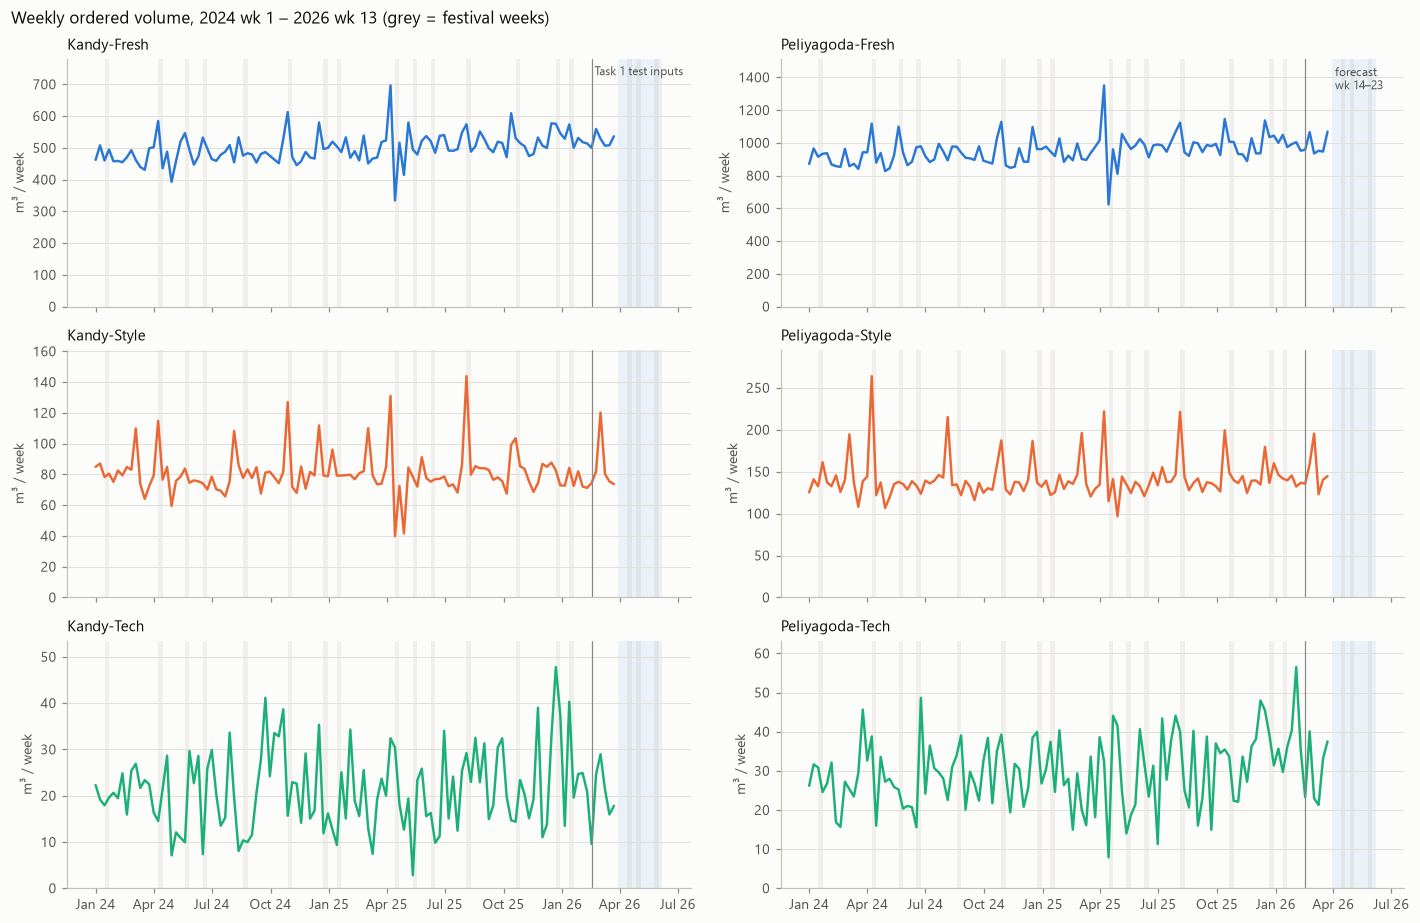

Mean vol_per_op_day, last 6 train weeks vs the 6 Task 1 weeks:


part,t1 wk 8-13,train wk 2-7,change_pct
series,,,
Kandy-Fresh,87.2,88.0,-0.8
Kandy-Style,14.1,12.6,11.2
Kandy-Tech,3.3,4.0,-17.8
Peliyagoda-Fresh,164.6,165.9,-0.8
Peliyagoda-Style,25.0,23.4,6.6
Peliyagoda-Tech,5.0,6.5,-23.7


In [20]:
fig, axes = plt.subplots(3, 2, figsize=(13, 8.5), sharex=True)
for ax, s in zip(axes.flat, SERIES_ORDER):
    g = hw[hw.series == s]
    for _, f in fest_weeks.iterrows():
        ax.axvspan(f.week_start, f.week_start + pd.Timedelta(days=7), color=NEUTRAL_BAND, lw=0, zorder=0)
    ax.axvspan(fc_start, fc_end, color=C1, alpha=0.08, lw=0, zorder=0)
    ax.plot(g.week_start, g.total_vol, color=BRAND_COLOR[g.brand.iloc[0]])
    ax.axvline(t1_start, color=MUTED, lw=0.8)
    ax.set_title(s, loc="left")
    ax.set_ylim(0, g.total_vol.max() * 1.12)
    ax.set_ylabel("m³ / week")
axes[0, 0].text(t1_start, axes[0, 0].get_ylim()[1] * 0.97, " Task 1 test inputs", color=INK2, va="top", fontsize=8)
axes[0, 1].text(fc_start, axes[0, 1].get_ylim()[1] * 0.97, " forecast\n wk 14–23", color=INK2, va="top", fontsize=8)
axes[-1, 0].xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
fig.suptitle("Weekly ordered volume, 2024 wk 1 – 2026 wk 13 (grey = festival weeks)", x=0.01, ha="left", fontsize=11)
fig.tight_layout()
save(fig, "p3_01_weekly_series")

# Continuity: Task 1 weeks vs the 6 training weeks just before them
cont = hw[hw.week_start >= t1_start - pd.Timedelta(weeks=6)].assign(part=lambda d: np.where(d.week_start >= t1_start, "t1 wk 8-13", "train wk 2-7"))
print("Mean vol_per_op_day, last 6 train weeks vs the 6 Task 1 weeks:")
cont.pivot_table(index="series", columns="part", values="vol_per_op_day").assign(change_pct=lambda d: 100 * (d.iloc[:, 0] / d.iloc[:, 1] - 1)).round(1)


### Plot 2: Year-over-year overlay
**Question:** do the April–May patterns repeat each year? The forecast weeks are shaded.

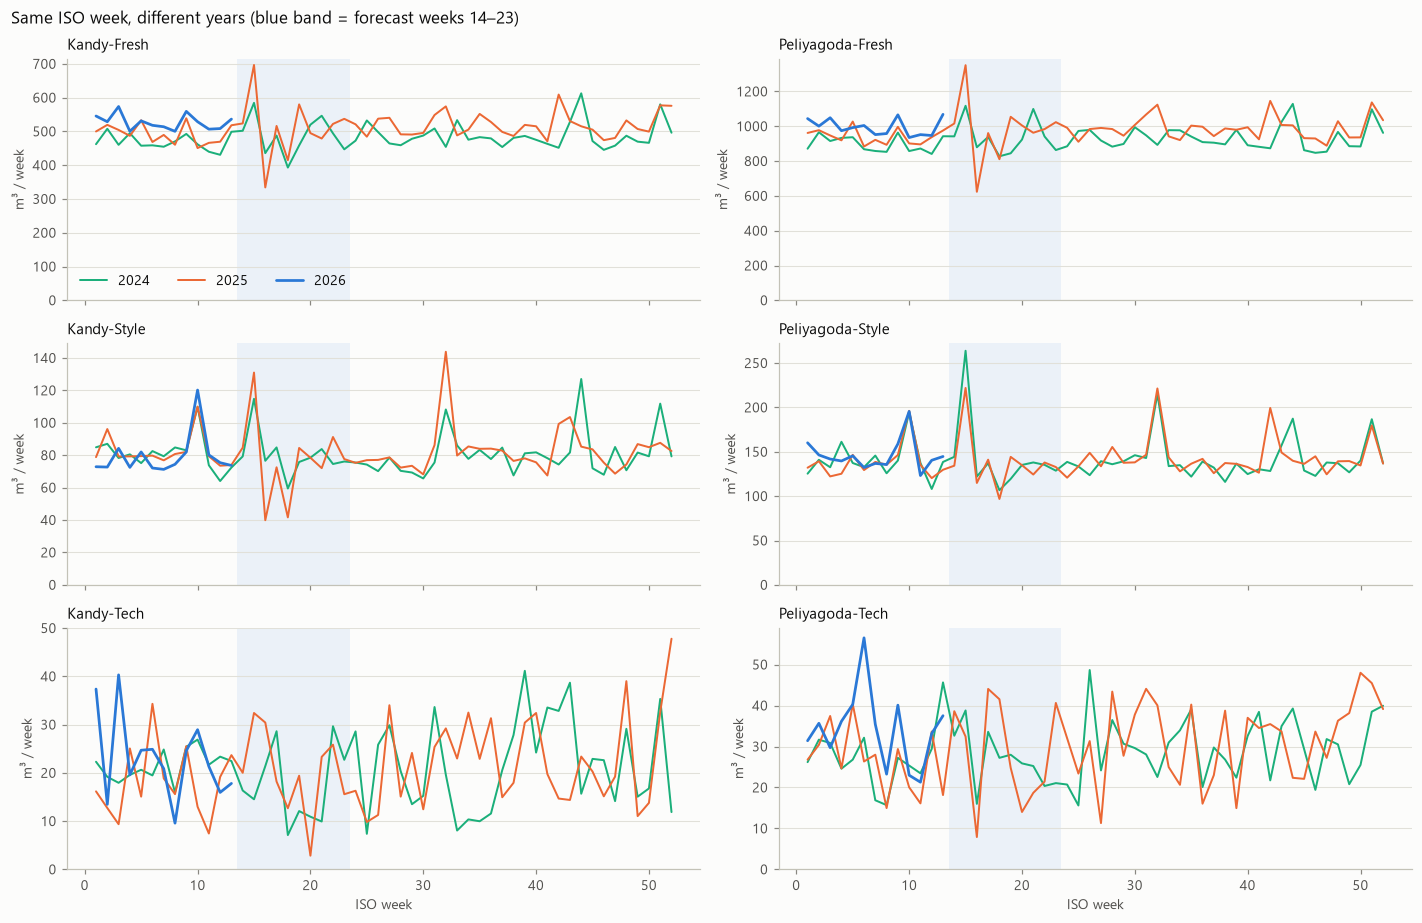

Forecast-window weeks in previous years, total volume (m³):


n_operating_days      ramp_sum_operating      total_vol        
iso_year             2024 2025               2024 2025      2024    2025
iso_week                                                                
14                    6.0  6.0                0.6  0.1     942.1  1015.8
15                    5.0  6.0                3.5  3.3    1117.6  1351.0
16                    6.0  4.0                0.0  0.0     879.4   623.5
17                    6.0  6.0                0.0  0.0     938.6   960.8
18                    5.0  5.0                0.0  0.1     827.6   810.9
19                    6.0  6.0                0.0  3.3     844.8  1054.3
20                    6.0  6.0                1.5  1.0     923.4  1004.6
21                    6.0  6.0                3.4  0.0    1099.4   962.8
22                    6.0  6.0                0.0  0.0     941.3   983.7
23                    6.0  6.0                0.0  2.7     863.4  1023.6

In [21]:
fig, axes = plt.subplots(3, 2, figsize=(13, 8.5), sharex=True)
for ax, s in zip(axes.flat, SERIES_ORDER):
    ax.axvspan(13.5, 23.5, color=C1, alpha=0.08, lw=0)
    for y in [2024, 2025, 2026]:
        g = hw[(hw.series == s) & (hw.iso_year == y)]
        ax.plot(g.iso_week, g.total_vol, color=YEAR_COLOR[y], lw=1.8 if y == 2026 else 1.3, label=str(y))
    ax.set_title(s, loc="left")
    ax.set_ylim(0, None)
    ax.set_ylabel("m³ / week")
for ax in axes[-1]:
    ax.set_xlabel("ISO week")
axes[0, 0].legend(loc="lower left", ncol=3)
fig.suptitle("Same ISO week, different years (blue band = forecast weeks 14–23)", x=0.01, ha="left", fontsize=11)
fig.tight_layout()
save(fig, "p3_02_year_overlay")

print("Forecast-window weeks in previous years, total volume (m³):")
hw[hw.iso_week.between(14, 23) & (hw.brand == "Fresh") & (hw.depot == "Peliyagoda")].pivot_table(
    index="iso_week", columns="iso_year", values=["total_vol", "n_operating_days", "ramp_sum_operating"]).round(1)


### Plot 3: Festival event study
**Question:** how big is the pre-festival surge, and how does it vary by festival and brand? This uses `ratio_opd`, so closed days don't show up as a fake drop in demand. Values are averaged over both depots and all years.

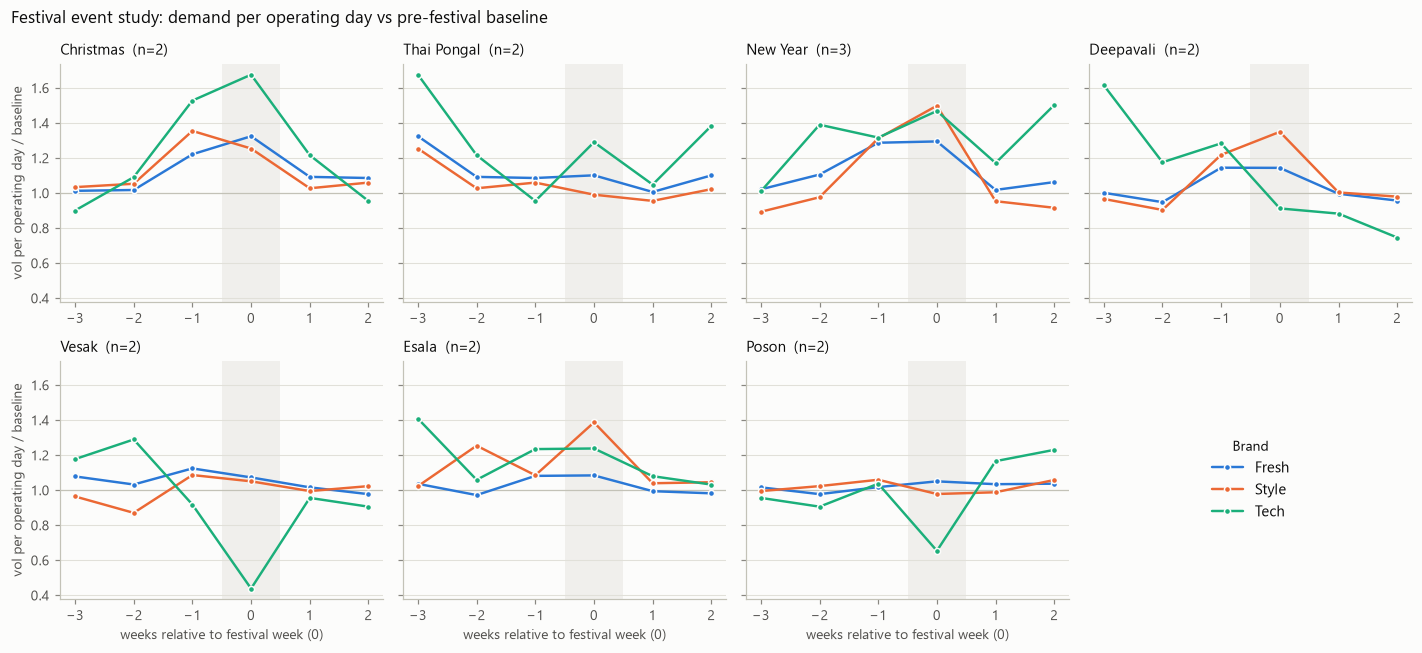

Peak of weeks -1 / 0 and when it happens (Fresh). Earlier weeks can belong to the previous festival, e.g. Thai Pongal wk -3 = Christmas:


,rel,ratio_opd
festival,,
christmas,0,1.325
new_year,0,1.296
deepavali,-1,1.146
vesak,-1,1.125
thai_pongal,0,1.102
esala,0,1.086
poson,0,1.052


Does the surge week follow the ramp? Fresh ratio_opd vs ramp_sum_operating (all festival-window weeks):
  corr = 0.64


In [22]:
rows = []
for _, f in fest_weeks.iterrows():
    for rel in range(-3, 3):
        sel = hw[hw.week_idx == f.week_idx + rel]
        for _, r in sel.iterrows():
            rows.append({"festival": f.festival_name, "year": f.week_start.year, "rel": rel, "brand": r.brand,
                         "series": r.series, "ratio_opd": r.ratio_opd, "ramp_op": r.ramp_sum_operating})
ev = pd.DataFrame(rows).dropna(subset=["ratio_opd"])
ev_mean = ev.groupby(["festival", "brand", "rel"]).ratio_opd.mean().reset_index()

order = (ev_mean[(ev_mean.brand == "Fresh")].groupby("festival").ratio_opd.max().sort_values(ascending=False).index.tolist())
fig, axes = plt.subplots(2, 4, figsize=(13, 6), sharey=True)
for ax, fname in zip(axes.flat, order):
    ax.axhline(1, color=AXIS, lw=0.8)
    ax.axvspan(-0.5, 0.5, color=NEUTRAL_BAND, lw=0, zorder=0)
    for b in BRANDS:
        g = ev_mean[(ev_mean.festival == fname) & (ev_mean.brand == b)]
        ax.plot(g.rel, g.ratio_opd, color=BRAND_COLOR[b], marker="o", ms=4, mec=SURFACE, mew=1, label=b)
    n_years = ev[ev.festival == fname].year.nunique()
    ax.set_title(f"{fname.replace('_', ' ').title()}  (n={n_years})", loc="left")
    ax.set_xticks(range(-3, 3))
axes.flat[-1].axis("off")
h_, l_ = axes.flat[0].get_legend_handles_labels()
axes.flat[-1].legend(h_, l_, loc="center", title="Brand", fontsize=10)
for ax in axes[1]:
    ax.set_xlabel("weeks relative to festival week (0)")
for ax in axes[:, 0]:
    ax.set_ylabel("vol per operating day / baseline")
fig.suptitle("Festival event study: demand per operating day vs pre-festival baseline", x=0.01, ha="left", fontsize=11)
fig.tight_layout()
save(fig, "p3_03_event_study")

print("Peak of weeks -1 / 0 and when it happens (Fresh). Earlier weeks can belong to the previous festival, e.g. Thai Pongal wk -3 = Christmas:")
pk = ev_mean[(ev_mean.brand == "Fresh") & ev_mean.rel.isin([-1, 0])].loc[lambda d: d.groupby("festival").ratio_opd.idxmax()]
display(pk.set_index("festival")[["rel", "ratio_opd"]].sort_values("ratio_opd", ascending=False).round(3))

print("Does the surge week follow the ramp? Fresh ratio_opd vs ramp_sum_operating (all festival-window weeks):")
fr_ev = ev[ev.brand == "Fresh"]
print(f"  corr = {fr_ev[['ratio_opd', 'ramp_op']].corr().iloc[0, 1]:.2f}")


### Plot 4: Order size by day relative to the festival
**Question:** is the ramp effect roughly linear, so `festival_ramp` can be used directly as a feature? Each order is compared with its outlet's median order on normal days, so the effect of the Style schedule is removed.

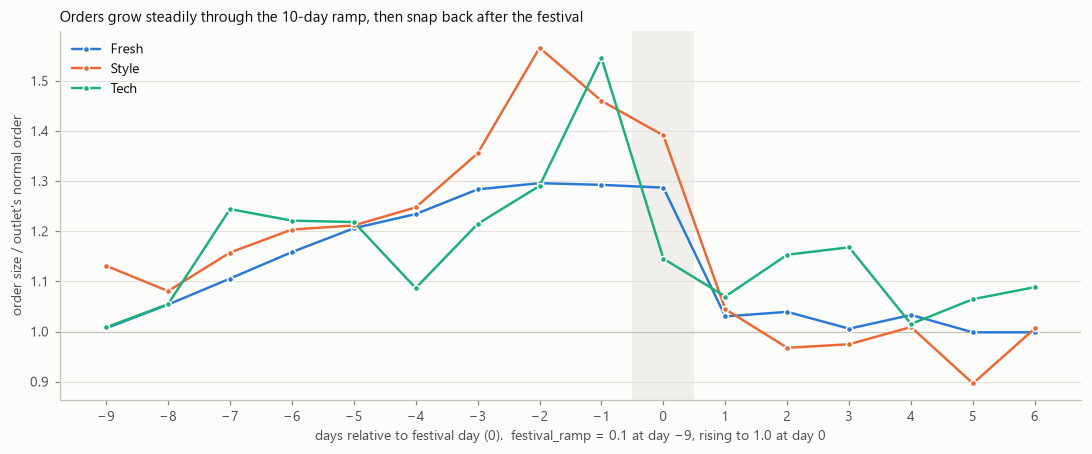

Linear fit on ramp days: size_ratio = a + b * festival_ramp


,a (intercept),b (slope),uplift at ramp 1.0,R² of binned means
brand,,,,
Fresh,1.006,0.342,0.348,0.912
Style,1.025,0.438,0.463,0.778
Tech,1.048,0.281,0.329,0.335


In [23]:
cal_rel = dy[["date", "days_to_next_festival", "days_since_last_festival", "festival_ramp"]].drop_duplicates("date")
o = od.merge(cal_rel.drop(columns="festival_ramp"), left_on="order_date", right_on="date", how="left")
o["rel_day"] = np.where(o.days_to_next_festival <= 9, -o.days_to_next_festival,
                        np.where(o.days_since_last_festival <= 6, o.days_since_last_festival, np.nan))
normal_day = o.rel_day.isna() & (o.festival_ramp == 0)
o["outlet_med"] = o.outlet_id.map(o[normal_day].groupby("outlet_id").order_volume_m3.median())
o["size_ratio"] = o.order_volume_m3 / o.outlet_med

prof = o.dropna(subset=["rel_day"]).groupby(["brand", "rel_day"], observed=True).size_ratio.mean().reset_index()
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.axhline(1, color=AXIS, lw=0.8)
ax.axvspan(-0.5, 0.5, color=NEUTRAL_BAND, lw=0, zorder=0)
for b in BRANDS:
    g = prof[prof.brand == b]
    ax.plot(g.rel_day, g.size_ratio, color=BRAND_COLOR[b], marker="o", ms=4, mec=SURFACE, mew=1, label=b)
ax.set_xticks(range(-9, 7))
ax.set_xlabel("days relative to festival day (0).  festival_ramp = 0.1 at day −9, rising to 1.0 at day 0")
ax.set_ylabel("order size / outlet's normal order")
ax.legend(loc="upper left")
ax.set_title("Orders grow steadily through the 10-day ramp, then snap back after the festival", loc="left")
fig.tight_layout()
save(fig, "p3_04_ramp_profile")

print("Linear fit on ramp days: size_ratio = a + b * festival_ramp")
fit = []
for b in BRANDS:
    g = o[(o.brand == b) & (o.festival_ramp > 0)]
    m, c = np.polyfit(g.festival_ramp, g.size_ratio, 1)
    binned = g.groupby("festival_ramp").size_ratio.mean()
    r2 = np.corrcoef(binned.index, binned.values)[0, 1] ** 2
    fit.append({"brand": b, "a (intercept)": c, "b (slope)": m, "uplift at ramp 1.0": c + m - 1, "R² of binned means": r2})
pd.DataFrame(fit).set_index("brand").round(3)


### Plot 5: Day of week and payday
**Question:** are there day-of-week and payday effects? Only Fresh orders every day, so the weekday plot uses Fresh. The payday effect is measured on order size, so it works for all brands.

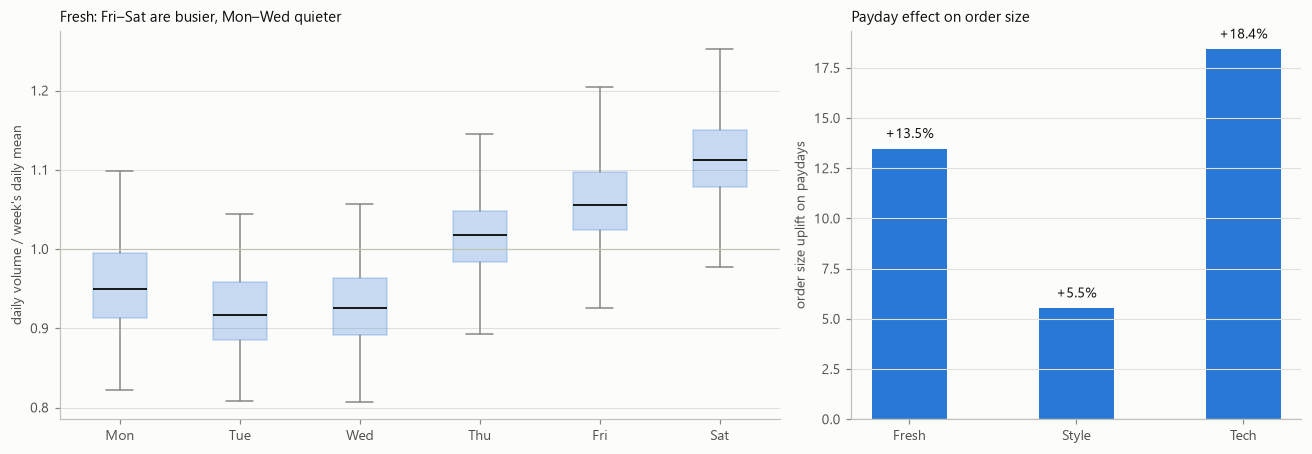

Fresh day-of-week factor (mean daily volume / week mean, normal weeks):


dow,Mon,Tue,Wed,Thu,Fri,Sat
depot,,,,,,
Kandy,0.938,0.892,0.964,0.993,1.091,1.114
Peliyagoda,0.965,0.949,0.893,1.042,1.032,1.114


Payday uplift on order size (%): {'Fresh': 13.5, 'Style': 5.5, 'Tech': 18.4}


In [24]:
fd = dy[(dy.is_future == 0) & (dy.brand == "Fresh") & (dy.is_operating == 1) & (dy.festival_ramp == 0)].copy()
fd["week_mean"] = fd.groupby(["series", "iso_year", "iso_week"]).total_vol.transform("mean")
fd["day_ratio"] = fd.total_vol / fd.week_mean
dows = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw={"width_ratios": [1.6, 1]})
data = [fd.loc[fd.dow == i, "day_ratio"].dropna() for i in range(6)]
bp = ax1.boxplot(data, tick_labels=dows, widths=0.45, patch_artist=True, showfliers=False,
                 medianprops={"color": INK, "lw": 1.2}, whiskerprops={"color": MUTED}, capprops={"color": MUTED},
                 boxprops={"facecolor": C1, "alpha": 0.25, "edgecolor": C1})
ax1.axhline(1, color=AXIS, lw=0.8)
ax1.set_ylabel("daily volume / week's daily mean")
ax1.set_title("Fresh: Fri–Sat are busier, Mon–Wed quieter", loc="left")

nd = o[normal_day]
pay = nd.groupby(["brand", "is_payday"], observed=True).size_ratio.mean().unstack()
uplift = 100 * (pay[1] / pay[0] - 1)
bars = ax2.bar(uplift.index, uplift.values, width=0.45, color=C1)
for rect, v in zip(bars, uplift.values):
    ax2.text(rect.get_x() + rect.get_width() / 2, v + (0.4 if v >= 0 else -0.4), f"{v:+.1f}%",
             ha="center", va="bottom" if v >= 0 else "top", color=INK, fontsize=9)
ax2.axhline(0, color=AXIS, lw=0.8)
ax2.set_ylabel("order size uplift on paydays")
ax2.set_title("Payday effect on order size", loc="left")
fig.tight_layout()
save(fig, "p3_05_dow_payday")

print("Fresh day-of-week factor (mean daily volume / week mean, normal weeks):")
display(fd.groupby(["depot", "dow"]).day_ratio.mean().unstack().rename(columns=dict(enumerate(dows))).round(3))
print("Payday uplift on order size (%):", uplift.round(1).to_dict())


### Plot 6: Weekly volume vs operating days
**Question:** do short weeks lose the closed day's demand, or does it move to the other days? The reference line is `operating_days / 6`, which is what we would see if the demand were simply lost.

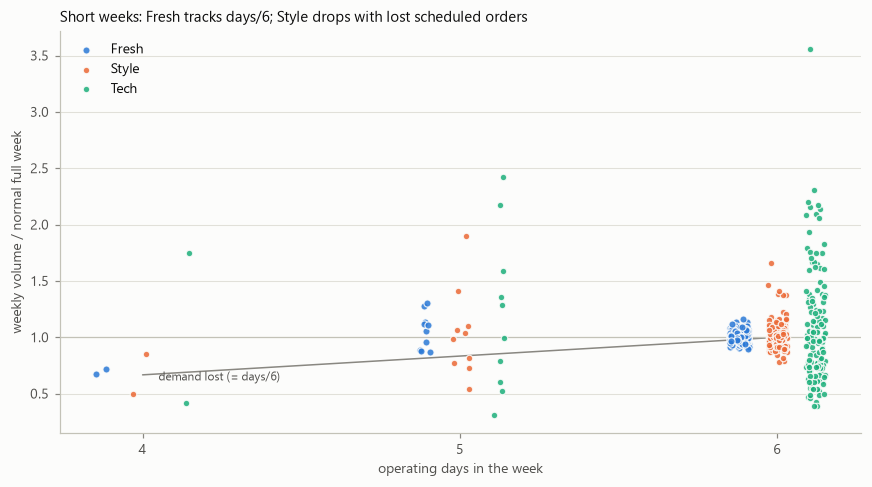

Short weeks in detail (ratio_week; days/6 = expected if the closed day is lost):


brand                                             Fresh  Style  Tech  days/6
iso_year iso_week n_operating_days festival_name                            
2024     15       5                new_year        1.29   1.66  1.10    0.83
         18       5                                0.91   0.79  0.65    0.83
         52       5                christmas       1.09   1.08  0.94    0.83
2025     16       4                new_year        0.70   0.67  1.08    0.67
         18       5                                0.88   0.64  1.48    0.83
         52       5                christmas       1.12   1.01  1.85    0.83

In [25]:
fig, ax = plt.subplots(figsize=(8, 4.5))
xs = np.array([4, 5, 6])
ax.plot(xs, xs / 6, color=MUTED, lw=1, zorder=1)
ax.text(4.05, 4 / 6 - 0.05, "demand lost (= days/6)", color=INK2, fontsize=8)
ax.axhline(1, color=AXIS, lw=0.8)
rng = np.random.default_rng(0)
for i, b in enumerate(BRANDS):
    g = hw[(hw.brand == b) & hw.ratio_week.notna() & (hw.ramp_max == 0) & (hw.has_festival == 0)
           | (hw.brand == b) & hw.ratio_week.notna() & (hw.n_operating_days < 6)]
    x = g.n_operating_days + (i - 1) * 0.12 + rng.uniform(-0.03, 0.03, len(g))
    ax.scatter(x, g.ratio_week, s=18 if b != "Fresh" else 22, color=BRAND_COLOR[b], edgecolor=SURFACE, lw=0.8,
               label=b, alpha=0.85, zorder=2)
ax.set_xticks(xs)
ax.set_xlabel("operating days in the week")
ax.set_ylabel("weekly volume / normal full week")
ax.legend(loc="upper left")
ax.set_title("Short weeks: Fresh tracks days/6; Style drops with lost scheduled orders", loc="left")
fig.tight_layout()
save(fig, "p3_06_operating_days")

print("Short weeks in detail (ratio_week; days/6 = expected if the closed day is lost):")
sw = hw[hw.n_operating_days < 6].pivot_table(index=["iso_year", "iso_week", "n_operating_days", "festival_name"],
                                             columns="brand", values="ratio_week").round(2)
sw["days/6"] = (sw.index.get_level_values("n_operating_days") / 6).round(2)
sw


### Plot 7: Chilled share over time
**Question:** is a constant chilled share enough, or does it change around festivals or with the season? Weeks 14–23 of each year are shaded.

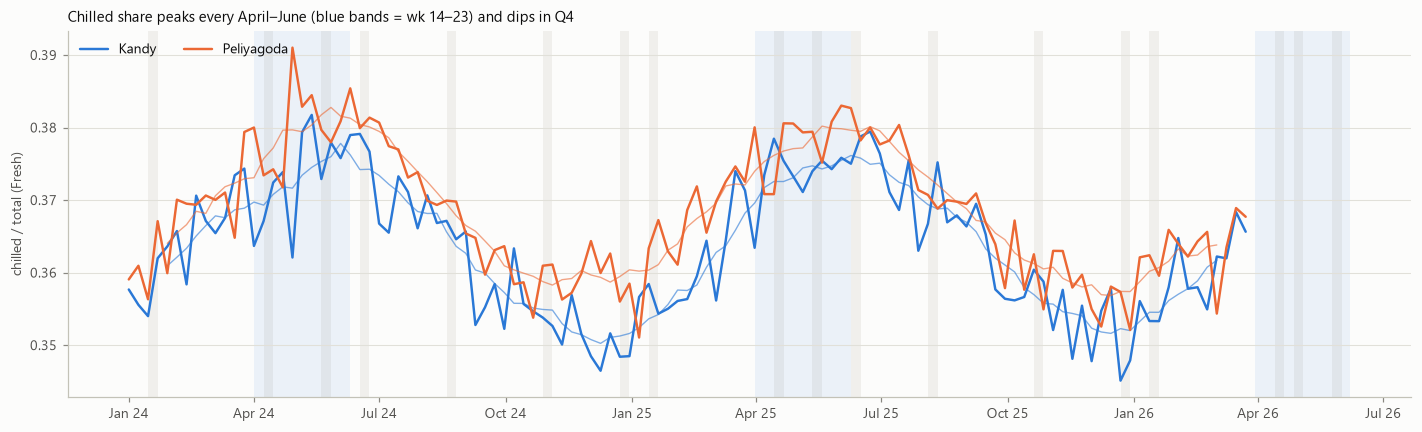

Mean chilled share by ISO-week band, both years:


band,wk1-7,wk8-13,wk14-23,wk24-39,wk40+
depot,,,,,
Kandy,0.3568,0.3655,0.3731,0.3688,0.3536
Peliyagoda,0.3621,0.3687,0.3788,0.3730,0.3592


In [26]:
fr = hw[hw.brand == "Fresh"]
fig, ax = plt.subplots(figsize=(13, 4))
for y in [2024, 2025]:
    a = wk[(wk.iso_year == y) & (wk.iso_week == 14)].week_start.iloc[0]
    b = wk[(wk.iso_year == y) & (wk.iso_week == 23)].week_start.iloc[0] + pd.Timedelta(days=7)
    ax.axvspan(a, b, color=C1, alpha=0.08, lw=0)
ax.axvspan(fc_start, fc_end, color=C1, alpha=0.08, lw=0)
for _, f in fest_weeks.iterrows():
    ax.axvspan(f.week_start, f.week_start + pd.Timedelta(days=7), color=NEUTRAL_BAND, lw=0, zorder=0)
for dpt, col in zip(DEPOTS, [C1, C2]):
    g = fr[fr.depot == dpt]
    ax.plot(g.week_start, g.chilled_share, color=col, label=dpt)
    ax.plot(g.week_start, g.chilled_share.rolling(8, center=True).mean(), color=col, lw=0.9, alpha=0.6)
ax.set_ylabel("chilled / total (Fresh)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
ax.legend(loc="upper left", ncol=2)
ax.set_title("Chilled share peaks every April–June (blue bands = wk 14–23) and dips in Q4", loc="left")
fig.tight_layout()
save(fig, "p3_07_chilled_share")

print("Mean chilled share by ISO-week band, both years:")
fr.assign(band=pd.cut(fr.iso_week, [0, 7, 13, 23, 39, 53], labels=["wk1-7", "wk8-13", "wk14-23", "wk24-39", "wk40+"])) \
  .groupby(["depot", "band"], observed=True).chilled_share.mean().unstack().round(4)


### Plot 8: Order count vs order size
**Question:** does growth come from more orders or bigger orders? Both are indexed to 100 at the 2024 clean-week average, so they share one axis.

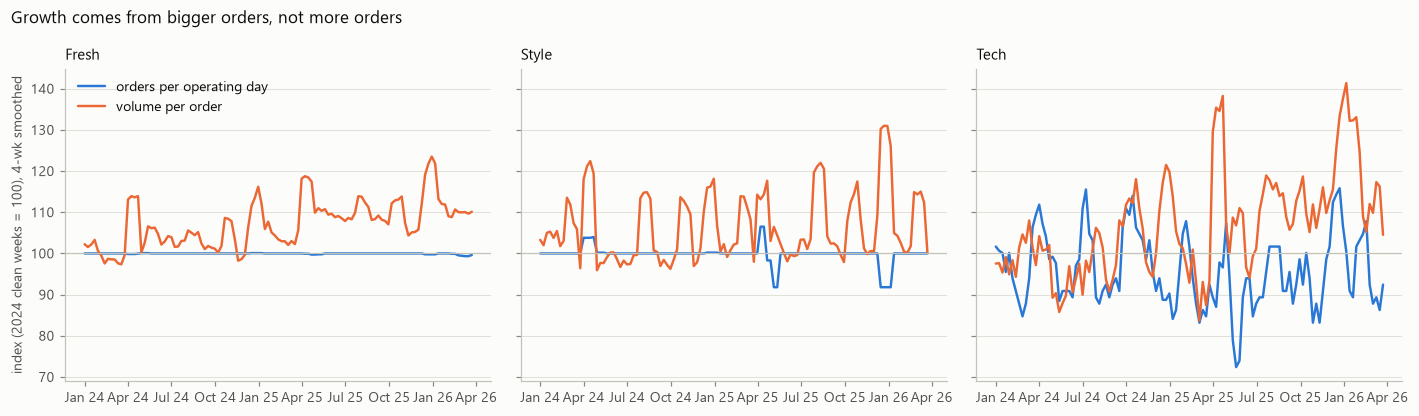

Clean-week averages by year (both depots combined):


orders_per_op_day                 vol_per_order            
iso_year              2024    2025    2026          2024  2025  2026
brand                                                               
Fresh               133.33  133.33  132.97          1.72  1.82  1.90
Style                 4.17    4.17    4.17          8.48  8.69  9.05
Tech                  2.70    2.49    2.61          3.12  3.30  3.64

In [27]:
agg = hw.groupby(["brand", "week_start", "iso_year"], as_index=False).agg(
    n_orders=("n_orders", "sum"), total_vol=("total_vol", "sum"), op=("n_operating_days", "first"), clean=("clean", "all"))
agg["orders_per_op_day"] = agg.n_orders / agg.op
agg["vol_per_order"] = agg.total_vol / agg.n_orders
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for ax, b in zip(axes, BRANDS):
    g = agg[agg.brand == b].copy()
    ref = g[(g.iso_year == 2024) & g.clean]
    for col, c, lab in [("orders_per_op_day", C1, "orders per operating day"), ("vol_per_order", C2, "volume per order")]:
        idx = 100 * g[col] / ref[col].mean()
        ax.plot(g.week_start, idx.rolling(4, center=True, min_periods=1).mean(), color=c, label=lab)
    ax.axhline(100, color=AXIS, lw=0.8)
    ax.set_title(b, loc="left")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
axes[0].set_ylabel("index (2024 clean weeks = 100), 4-wk smoothed")
axes[0].legend(loc="upper left")
fig.suptitle("Growth comes from bigger orders, not more orders", x=0.01, ha="left", fontsize=11)
fig.tight_layout()
save(fig, "p3_08_orders_vs_size")

print("Clean-week averages by year (both depots combined):")
agg[agg.clean].groupby(["brand", "iso_year"])[["orders_per_op_day", "vol_per_order"]].mean().unstack().round(2)


### Plot 9: Trend, festival effects and noise
**Question:** how much of each series is trend, how much is calendar or festival effect, and how much is plain noise?

With only about 2.25 years of data, an STL decomposition with a 52-week period can't separate seasonality from noise: each seasonal value is fitted from just 2–3 points. So this plot splits `vol_per_op_day` in a simpler way:
- **Trend:** a centred 13-week rolling median of clean weeks.
- **Event deviation:** the deviation from trend in non-clean weeks (festival ramps, festivals, closures).
- **Noise:** the deviation from trend in clean weeks.

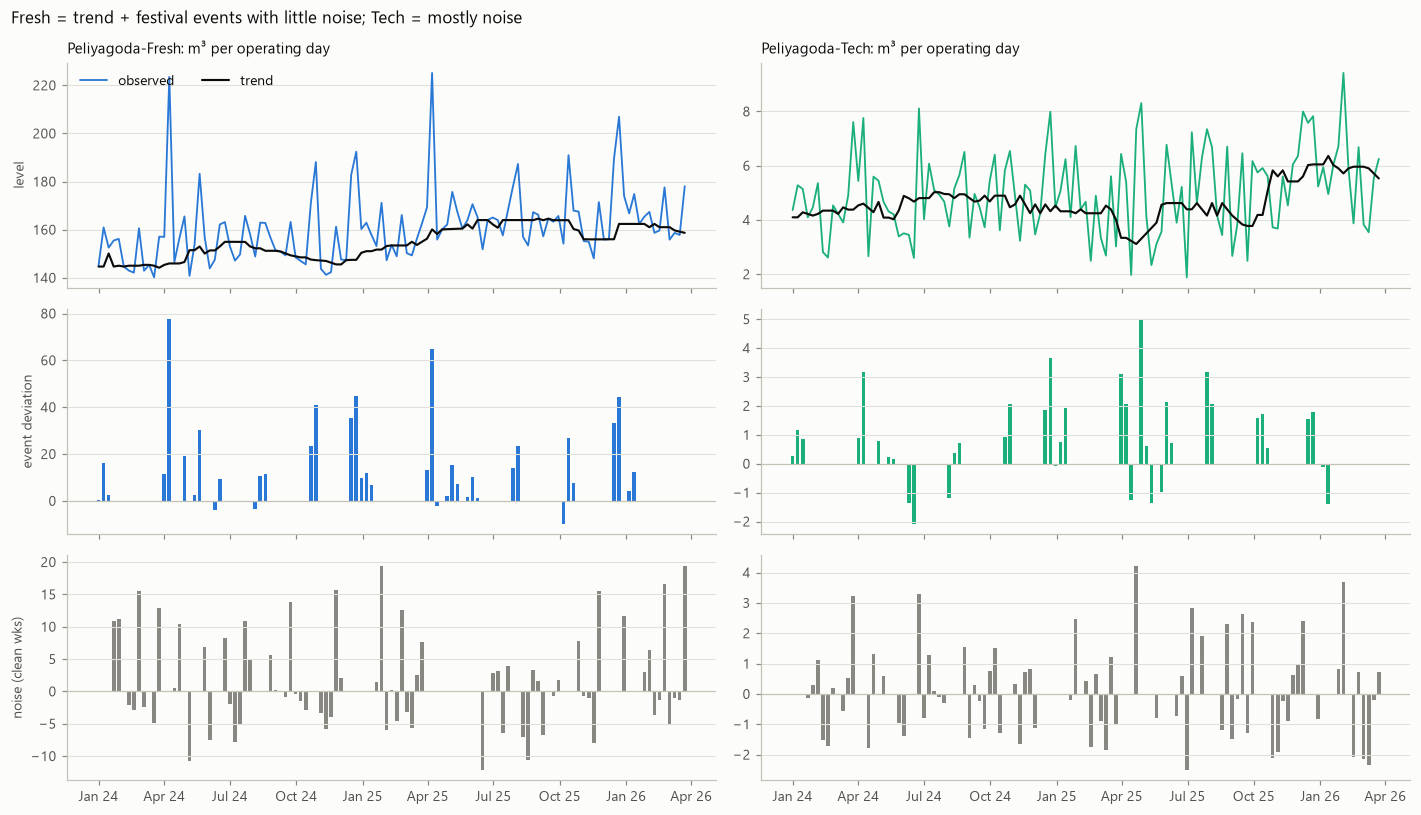

,trend growth %/yr,trend share,event share,noise share,noise CV (clean wks)
series,,,,,
Kandy-Fresh,5.158,0.160,0.809,0.149,0.045
Peliyagoda-Fresh,4.193,0.201,0.793,0.163,0.045
Kandy-Style,-2.893,0.035,0.777,0.256,0.108
Peliyagoda-Style,0.988,0.018,0.808,0.200,0.100
Kandy-Tech,2.878,0.075,0.564,0.436,0.338
Peliyagoda-Tech,14.257,0.198,0.407,0.639,0.301


In [28]:
dec_rows, dec = [], {}
for s in SERIES_ORDER:
    g = hw[hw.series == s].set_index("week_start")
    y = g.vol_per_op_day
    trend = y.where(g.clean).rolling(13, center=True, min_periods=5).median().interpolate().bfill().ffill()
    dev = y - trend
    event = dev.where(~g.clean, 0.0)
    noise = dev.where(g.clean, 0.0)
    dec[s] = (y, trend, event, noise)
    dec_rows.append({"series": s, "trend growth %/yr": 100 * ((trend.iloc[-1] / trend.iloc[0]) ** (52 / len(trend)) - 1),
                     "trend share": trend.var() / y.var(), "event share": event.var() / y.var(),
                     "noise share": noise.var() / y.var(), "noise CV (clean wks)": noise[g.clean].std() / y.mean()})
dec_tab = pd.DataFrame(dec_rows).set_index("series")

fig, axes = plt.subplots(3, 2, figsize=(13, 7.5), sharex=True)
for j, s in enumerate(["Peliyagoda-Fresh", "Peliyagoda-Tech"]):
    y, trend, event, noise = dec[s]
    col = BRAND_COLOR[s.split("-")[1]]
    axes[0, j].plot(y.index, y.values, color=col, lw=1.2, label="observed")
    axes[0, j].plot(trend.index, trend.values, color=INK, lw=1.4, label="trend")
    axes[0, j].set_title(f"{s}: m³ per operating day", loc="left")
    axes[1, j].bar(event.index, event.values, width=5, color=col)
    axes[2, j].bar(noise.index, noise.values, width=5, color=MUTED)
    for i in (1, 2):
        axes[i, j].axhline(0, color=AXIS, lw=0.8)
axes[0, 0].legend(loc="upper left", ncol=2)
for i, lab in enumerate(["level", "event deviation", "noise (clean wks)"]):
    axes[i, 0].set_ylabel(lab)
axes[-1, 0].xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
fig.suptitle("Fresh = trend + festival events with little noise; Tech = mostly noise", x=0.01, ha="left", fontsize=11)
fig.tight_layout()
save(fig, "p3_09_trend_event_noise")
dec_tab.round(3)


### Plot 10: The 2026 week 10 Style spike
**Question:** is it a one-off outlier, one huge order, or a repeating pattern?

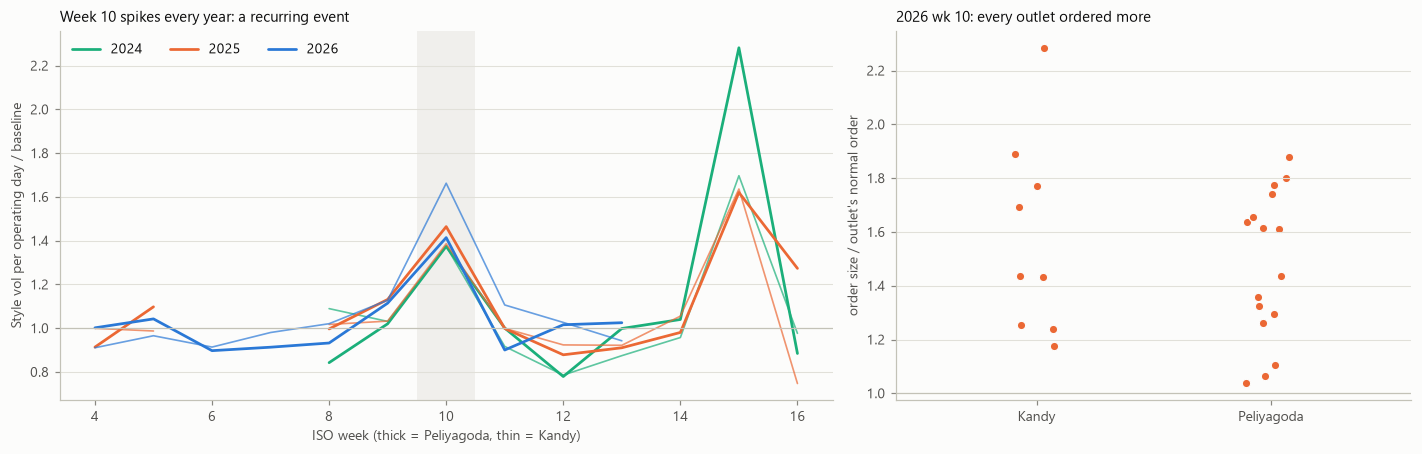

Style week 10 in every year (m³):


depot     Kandy               Peliyagoda              
iso_year   2024   2025   2026       2024   2025   2026
iso_week                                              
9          83.0   82.0   82.0      140.0  146.0  159.0
10        110.0  110.0  120.0      194.0  196.0  195.0
11         74.0   79.0   80.0      137.0  135.0  123.0

2026 wk 10: 25 Style orders, 100% above their outlet's normal size, median ratio 1.44
Unflagged ISO weeks that are >12% above (or >10% below) baseline in BOTH 2024 and 2025:


iso_year        2024  2025
brand iso_week            
Style 10        1.37  1.43
Tech  8         0.70  0.62
      17        1.23  1.57
      28        1.27  1.49
      40        1.59  1.51
      45        0.90  0.79
      46        0.71  0.70

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1.5, 1]})
sty = hw[(hw.brand == "Style") & hw.iso_week.between(4, 16)]
for y in [2024, 2025, 2026]:
    for dpt, ls in zip(DEPOTS, ["-", "-"]):
        g = sty[(sty.iso_year == y) & (sty.depot == dpt)]
        ax1.plot(g.iso_week, g.ratio_opd, color=YEAR_COLOR[y], lw=1.8 if dpt == "Peliyagoda" else 1.1,
                 alpha=1 if dpt == "Peliyagoda" else 0.7, label=f"{y}" if dpt == "Peliyagoda" else None)
ax1.axvspan(9.5, 10.5, color=NEUTRAL_BAND, lw=0, zorder=0)
ax1.axhline(1, color=AXIS, lw=0.8)
ax1.set_xlabel("ISO week (thick = Peliyagoda, thin = Kandy)")
ax1.set_ylabel("Style vol per operating day / baseline")
ax1.legend(loc="upper left", ncol=3)
ax1.set_title("Week 10 spikes every year: a recurring event", loc="left")

w10 = o[(o.brand == "Style") & (o.iso_year == 2026) & (o.iso_week == 10)]
for k, dpt in enumerate(DEPOTS):
    v = w10[w10.depot == dpt].size_ratio
    ax2.scatter(np.full(len(v), k) + rng.uniform(-0.12, 0.12, len(v)), v, s=30, color=C2, edgecolor=SURFACE, lw=0.8)
ax2.axhline(1, color=AXIS, lw=0.8)
ax2.set_xticks([0, 1], DEPOTS)
ax2.set_xlim(-0.6, 1.6)
ax2.set_ylabel("order size / outlet's normal order")
ax2.set_title("2026 wk 10: every outlet ordered more", loc="left")
fig.tight_layout()
save(fig, "p3_10_style_week10")

print("Style week 10 in every year (m³):")
display(hw[(hw.brand == "Style") & hw.iso_week.between(9, 11)].pivot_table(index="iso_week", columns=["depot", "iso_year"], values="total_vol").round(0))
print(f"2026 wk 10: {len(w10)} Style orders, {(w10.size_ratio > 1).mean():.0%} above their outlet's normal size, "
      f"median ratio {w10.size_ratio.median():.2f}")

# Scan: other unflagged weeks that repeat in both 2024 and 2025 (no ramp, no festival, no closure)
cand = hw[(hw.ramp_max == 0) & (hw.has_festival == 0) & (hw.n_operating_days == 6) & hw.iso_year.isin([2024, 2025])]
rep = cand.pivot_table(index=["brand", "iso_week"], columns="iso_year", values="ratio_opd", aggfunc="mean")
rep = rep[((rep[2024] > 1.12) & (rep[2025] > 1.12)) | ((rep[2024] < 0.9) & (rep[2025] < 0.9))]
print("Unflagged ISO weeks that are >12% above (or >10% below) baseline in BOTH 2024 and 2025:")
rep.round(2)


### Phase 3 done: findings and modelling decisions

| # | Finding | Modelling decision |
|---|---|---|
| 1 | The Task 1 weeks continue the training series smoothly. Fresh per operating day changes −0.8%. Style is +7–11% because of the wk 10 event. Tech is −18 to −24%, within its noise. | Use the union as one continuous history. No level break. |
| 2 | 2025 wk 14–23 has the same shape as 2026 (wk 15 surge, wk 16 drop, wk 18 dip). 2024 differs because New Year fell on a Saturday in wk 15. | F1 (2025) is the main backtest fold. Align on ramp and operating days, not on ISO week. |
| 3 | **Uplift per operating day** in the peak week: Christmas 1.33, New Year 1.30, Deepavali 1.15, Vesak 1.13, Thai Pongal 1.10, Esala 1.09, Poson 1.05. Demand is back to about 1.0 within one week. Per operating day, the festival week is **not** a dip: the weekly drop comes only from closed days. | Use a festival-specific multiplier (or strong vs weak festival groups) applied to the ramp. No separate "festival-week dip" term, because operating days handle it. |
| 4 | Fresh order size rises almost linearly over the ramp (R² 0.91, slope about 0.34), levels off at about 1.30 over the last 3 days, and returns to 1.0 the day after the festival. Style is steeper (peak about 1.55). Tech is noisy. | Use daily `festival_ramp` as a linear feature with a brand-specific slope. No post-festival term. |
| 5 | Fresh day of week: Mon 0.95, Tue 0.92, Wed 0.92, Thu 1.02, Fri 1.06, Sat 1.11. Paydays make orders bigger: Fresh +13.5%, Tech +18%, Style +5.5%. | The daily structural model needs DOW and payday factors. Losing Mon+Tue (2026 wk 16) costs about 31% of a week, not 33%. |
| 6 | In short weeks Fresh falls roughly in line with days/6 (a little recovery when 1 May is closed). How much Style drops depends on which scheduled outlets are lost. Tech shows no pattern. | Sum the daily forecasts over operating days only. Style = `n_style_scheduled` × order size. |
| 7 | The chilled share follows a **smooth yearly cycle**: about 0.35 in Dec–Jan and about 0.38 in May–Jul. Festivals don't move it. 2026 runs slightly below 2025 (−0.3 pp Kandy, −0.7 pp Peliyagoda in wk 8–13). | Chilled share for wk 14–23 = last year's share for the same week + the 2026 vs 2025 offset from wk 8–13. Not a flat recent average. |
| 8 | Orders per operating day are flat (Fresh 133.3 every year, Style 4.17). All the growth is in order size (Fresh 1.72 → 1.82 → 1.90 m³/order). | Model the level as volume per operating day with a slow trend. Order counts are effectively known. |
| 9 | Noise in clean weeks (CV): Fresh 4.5%, Style 10%, Tech 30–34%. Fresh trend is about +4–5% a year. | Tech's WAPE floor is about 30%: keep its model simple and smoothed. Fresh rewards getting the festival effects right. |
| 10 | The **Style wk 10 spike happens every year** (Kandy 110 / 110 / 120, Peliyagoda 194 / 196 / 195 m³), and all 25 outlets ordered more (median 1.44×). Style wk 32 also spikes in both years. Neither is a calendar flag. | Not an outlier, so keep it. Exclude Style wk 10 and wk 32 from the Style baseline window. Neither is in the forecast window. |
| 11 | Scan of unflagged weeks: Tech wk 17 is above baseline in both years (1.23 and 1.57), and wk 17 *is* in the forecast window. With Tech's noise this is weak evidence (n = 2). | At most a small, shrunk uplift for Tech wk 17. Test it on F1 and F2 before using it. |

**Next: Phase 4, horizon-safe feature engineering.**

## Phase 4: Horizon-safe feature engineering

**The rule:** at the forecast origin (end of 2026 wk 13) nothing after wk 13 is known. Lag-1 doesn't exist for a 10-week-ahead forecast.

**Approach: origin-level features.**
- Each row of the feature table is one *(origin week, series, target week)* triple, with `h = target − origin` from 1 to 10.
- Features of two kinds:
  - **Outcome features** (levels, trends, last-year analogs, chilled share) use only weeks ≤ origin.
  - **Calendar features** of the target week (operating days, ramp, festival, Style schedule) are known in advance, so they are allowed.
- Training origins run from 2024 wk 13 (13 weeks of history) to 2026 wk 12. The real origin is 2026 wk 13, and its 60 rows are the submission rows.
- One origin → up to 10 target weeks, so the model learns how accuracy decays with `h`. The same table later gives the backtest folds of Phase 6 for free: F1 = origin 2025 wk 13.

**Example row:** origin 2025 wk 13, target 2025 wk 15, Peliyagoda-Fresh, h = 2.
- `lvl_med8` = median per-operating-day volume of the last 8 clean weeks up to 2025 wk 13.
- `ramp_sum_operating` = 3.3, the target week's New Year run-up.
- `fr_ratio` = how far above normal the *previous* New Year's wk −1 was (2024 wk 14).
- `y_total` = 1,351 m³, the actual 2025 wk 15 volume.

**Clean week** (used for every level feature): 6 operating days, no ramp, no festival, and for Style not ISO wk 10 or 32 (the recurring Style events from Phase 3).

### 4.1 Setup: calendar-only helpers

In [30]:
wk = pd.read_parquet(PROCESSED / "weekly_panel.parquet").sort_values(["series", "week_idx"]).reset_index(drop=True)
dy = pd.read_parquet(PROCESSED / "daily_panel.parquet")

ORIGIN_IDX = int(wk.loc[(wk.iso_year == ORIGIN[0]) & (wk.iso_week == ORIGIN[1]), "week_idx"].iloc[0])
FIRST_ORIGIN = 12                     # 2024 wk 13: the first origin with 13 weeks of history
STYLE_EVENT_WEEKS = {10, 32}          # recurring Style spikes (Phase 3, finding 10)

# Columns that are only known after the week has happened. Everything else in the panels is calendar.
WK_OUTCOMES = ["total_vol", "chilled_vol", "n_orders", "n_outlets_ordering", "n_order_days",
               "chilled_share", "vol_per_order", "vol_per_op_day"]
DY_OUTCOMES = ["total_vol", "chilled_vol", "n_orders", "n_outlets_ordering"]

# Festival the week is closest to (ties go to the upcoming one, as in fest_rel_week)
fest_at = wk[wk.has_festival == 1].drop_duplicates("week_idx").set_index("week_idx").festival_name
src_week = (wk.week_idx - wk.fest_rel_week.fillna(0)).astype(int)
wk["near_festival"] = np.where(wk.fest_rel_week > 0, src_week.map(fest_at), wk.next_festival_name)
wk["fest_day_closed"] = ((wk.has_festival == 1) & (wk.festival_day_operating == 0)).astype(int)

week_start = wk.drop_duplicates("week_idx").set_index("week_idx").week_start
n_hist_days = (dy.is_future == 0).sum()
# The daily panel runs a few weeks past wk 23; keep only the weeks the weekly panel has
dy = dy.merge(wk[["iso_year", "iso_week", "week_idx"]].drop_duplicates(), on=["iso_year", "iso_week"], how="inner")
assert (dy.is_future == 0).sum() == n_hist_days


def clean_flag(df):
    c = (df.n_operating_days == 6) & (df.ramp_max == 0) & (df.has_festival == 0)
    return c & ~((df.brand == "Style") & df.iso_week.isin(STYLE_EVENT_WEEKS))


print(f"Origin index {ORIGIN_IDX} = {ORIGIN}; training origins {FIRST_ORIGIN}..{ORIGIN_IDX - 1}")
print("near_festival for the forecast weeks:",
      wk[(wk.series == 'Kandy-Fresh') & (wk.is_future == 1)][["iso_week", "fest_rel_week", "near_festival"]]
      .set_index("iso_week").T.to_string())


Origin index 116 = (2026, 13); training origins 12..115
near_festival for the forecast weeks: iso_week             14        15        16     17     18     19     20     21     22     23
fest_rel_week      -2.0      -1.0       0.0   -1.0    0.0    1.0   -2.0   -1.0    0.0    1.0
near_festival  new_year  new_year  new_year  vesak  vesak  vesak  poson  poson  poson  poson


### 4.2 The feature builder

`origin_features(wk_all, dy_all, o)` returns the rows for one origin. **The first line cuts the outcome data at the origin**, so nothing after it can leak in. 4.4 proves this with a test.

| Group | Features | Built from |
|---|---|---|
| Level | `lvl4`, `lvl8`, `lvl13` (mean), `lvl_med8` (median) of `vol_per_op_day` over the last N clean weeks; `cv13`; `trend26` (log-slope per week over clean weeks in the last 26); `weeks_since_clean` | weeks ≤ origin |
| Growth | `yoy8`: last 8 clean weeks vs the same ISO weeks a year earlier | weeks ≤ origin |
| Mix | `opd_orders8` (orders per operating day), `vpo8` (m³ per order), `outlets4` (outlets ordering, max of last 4 weeks) | weeks ≤ origin |
| ISO analog | `ly_total`, `ly_vpod`, `ly_ratio_opd`, `ly_n_op`, `ly_ramp`: the same ISO week last year | week t − 52 (≤ origin since h ≤ 10) |
| Festival analog | `fr_ratio`, `fr_ratio_brand`, `fr_ramp`: the last week before the origin with the **same nearest festival and same `fest_rel_week`** | weeks ≤ origin |
| Festival strength | `fest_strength`: peak `ratio_opd` (wk −1 or 0) at the last full occurrence of the target's festival, brand average; `ramp_x_strength = ramp_sum_operating × (fest_strength − 1)` | weeks ≤ origin |
| Day mix | `dow_weight`: Σ over the target's operating days of the series' day-of-week factor (6.0 = a normal full week) | factors from days ≤ origin, operating days from the calendar |
| Chilled (Fresh) | `share_recent6`, `share_ly_recent6`, `share_ly_target`, `share_seasonal = share_ly_target + (share_recent6 − share_ly_recent6)` | weeks ≤ origin |
| Calendar | `n_operating_days`, `n_closed_weekdays`, `n_paydays_operating`, `ramp_max`, `ramp_sum_operating`, `has_festival`, `fest_day_closed`, `weeks_to/since_*`, `fest_rel_week`, `near_festival`, `monsoon`, `n_style_scheduled` | calendar (known) |
| Targets | `y_total`, `y_chilled`, `y_share`, `y_ratio_opd = vol_per_op_day / lvl_med8`, `y_ratio_week = y_total / (6 × lvl_med8)` | target week (training labels only) |

`ratio_opd` for past weeks is recomputed inside the builder from the cut history. It uses a **more robust baseline than Phase 3**: the median of the last 6 clean weeks that are at least 3 weeks back, however far back that is. Phase 3's fixed 3–8-week window is empty after the April–May festival run, which left last year's ratio missing for 2026 wk 22–23.

In [31]:
CAL_FEATS = ["n_operating_days", "n_closed_weekdays", "n_paydays_operating", "ramp_max", "ramp_sum_operating",
             "has_festival", "fest_day_closed", "weeks_to_next_festival", "weeks_since_last_festival",
             "fest_rel_week", "monsoon", "n_style_scheduled"]
LEVEL_FEATS = ["lvl4", "lvl8", "lvl13", "lvl_med8", "cv13", "trend26", "weeks_since_clean", "yoy8",
               "opd_orders8", "vpo8", "outlets4"]
SEASONAL_FEATS = ["ly_total", "ly_vpod", "ly_ratio_opd", "ly_n_op", "ly_ramp",
                  "fr_ratio", "fr_ratio_brand", "fr_ramp", "fest_strength", "ramp_x_strength", "dow_weight"]
SHARE_FEATS = ["share_recent6", "share_ly_recent6", "share_ly_target", "share_seasonal"]
ID_COLS = ["origin_idx", "h", "week_idx", "depot", "brand", "series", "iso_year", "iso_week", "row_id", "is_future", "near_festival"]
Y_COLS = ["y_total", "y_chilled", "y_share", "y_ratio_opd", "y_ratio_week"]


def past_clean_median(v, gap=3, n=6):
    # Median of the last n clean weeks that are at least `gap` weeks back, however far back they are.
    # (Phase 3 used a fixed 3-8 week window, which is empty after a run of festival weeks.)
    m = v.shift(gap).dropna().rolling(n, min_periods=2).median()
    return m.reindex(v.index).ffill()


def origin_features(wk_all, dy_all, o):
    # ---- 1. Cut every outcome at the origin. Below this line only `hist` / `dh` carry outcomes.
    hist = wk_all[wk_all.week_idx <= o].copy()
    dh = dy_all[dy_all.week_idx <= o].copy()

    hist["clean"] = clean_flag(hist)
    hist["base"] = hist.vol_per_op_day.where(hist.clean).groupby(hist.series).transform(past_clean_median)
    hist["ratio_opd"] = hist.vol_per_op_day / hist.base

    # ---- 2. Per-series level, growth and mix features
    rows = []
    for s, g in hist.groupby("series"):
        c = g[g.clean]
        v, idx = c.vol_per_op_day.to_numpy(), c.week_idx.to_numpy()
        f = {"series": s, "lvl4": v[-4:].mean(), "lvl8": v[-8:].mean(), "lvl13": v[-13:].mean(),
             "lvl_med8": np.median(v[-8:]), "cv13": v[-13:].std(ddof=1) / v[-13:].mean(),
             "weeks_since_clean": o - idx[-1],
             "opd_orders8": (c.n_orders / c.n_operating_days).to_numpy()[-8:].mean(),
             "vpo8": c.vol_per_order.to_numpy()[-8:].mean(),
             "outlets4": g.n_outlets_ordering.tail(4).max()}
        m = (idx > o - 26) & (v > 0)
        f["trend26"] = np.polyfit(idx[m], np.log(v[m]), 1)[0] if m.sum() >= 8 else np.nan
        ly = c.set_index("week_idx").vol_per_op_day.reindex(idx[-8:] - 52)
        ok = ly.notna().to_numpy()
        f["yoy8"] = v[-8:][ok].sum() / ly[ok].sum() if ok.sum() >= 4 else np.nan
        if g.brand.iloc[0] == "Fresh":
            r6 = g[g.week_idx > o - 6]
            l6 = g[(g.week_idx > o - 58) & (g.week_idx <= o - 52)]
            f["share_recent6"] = r6.chilled_vol.sum() / r6.total_vol.sum()
            f["share_ly_recent6"] = l6.chilled_vol.sum() / l6.total_vol.sum() if len(l6) == 6 else np.nan
        rows.append(f)
    lvl = pd.DataFrame(rows)

    # ---- 3. Target weeks: calendar of t (known) + outcomes of t only as labels
    tg = wk_all[(wk_all.week_idx > o) & (wk_all.week_idx <= o + HORIZON)]
    if o < ORIGIN_IDX:
        tg = tg[tg.week_idx <= ORIGIN_IDX]      # training origins need known labels
    t = tg[["week_idx", "depot", "brand", "series", "iso_year", "iso_week", "row_id", "is_future", "near_festival",
            *CAL_FEATS, "total_vol", "chilled_vol", "chilled_share", "vol_per_op_day"]].copy()
    t.insert(0, "origin_idx", o)
    t.insert(1, "h", t.week_idx - o)
    t = t.merge(lvl, on="series", how="left")

    # ISO analog: same ISO week last year
    ly = hist.set_index(["series", "week_idx"])
    key = pd.MultiIndex.from_arrays([t.series, t.week_idx - 52])
    for col, src in [("ly_total", "total_vol"), ("ly_vpod", "vol_per_op_day"), ("ly_ratio_opd", "ratio_opd"),
                     ("ly_n_op", "n_operating_days"), ("ly_ramp", "ramp_sum_operating"), ("share_ly_target", "chilled_share")]:
        t[col] = ly[src].reindex(key).to_numpy()
    t.loc[t.brand != "Fresh", "share_ly_target"] = np.nan

    # Festival-relative analog: latest past week with the same nearest festival and relative week
    fr = (hist.dropna(subset=["ratio_opd"]).sort_values("week_idx")
          .groupby(["series", "near_festival", "fest_rel_week"])[["ratio_opd", "ramp_sum_operating"]].last()
          .rename(columns={"ratio_opd": "fr_ratio", "ramp_sum_operating": "fr_ramp"}).reset_index())
    t = t.merge(fr, on=["series", "near_festival", "fest_rel_week"], how="left")
    t["fr_ratio_brand"] = t.groupby(["week_idx", "brand"]).fr_ratio.transform("mean")

    # Festival strength: peak ratio_opd over rel -1/0 of the last complete occurrence, averaged over depots
    pk = hist[hist.fest_rel_week.isin([-1, 0])].assign(occ=lambda d: d.week_idx - d.fest_rel_week)
    pk = pk.groupby(["series", "brand", "near_festival", "occ"]).agg(peak=("ratio_opd", "max"), n=("ratio_opd", "count"))
    pk = (pk[pk.n == 2].groupby(["brand", "near_festival", "occ"]).peak.mean().reset_index()
          .sort_values("occ").groupby(["brand", "near_festival"]).peak.last().rename("fest_strength").reset_index())
    t = t.merge(pk, on=["brand", "near_festival"], how="left")
    t["ramp_x_strength"] = t.ramp_sum_operating * (t.fest_strength - 1)

    # Day-of-week weight: DOW factors from clean operating days up to the origin
    dh = dh.merge(hist[["series", "week_idx", "clean"]], on=["series", "week_idx"])
    dh = dh[dh.clean & (dh.is_operating == 1)]
    fac = (dh.groupby(["series", "dow"]).total_vol.mean() / dh.groupby("series").total_vol.mean()).rename("fac")
    dc = dy_all[dy_all.week_idx.isin(t.week_idx.unique()) & (dy_all.is_operating == 1)][["series", "week_idx", "dow"]]
    dc = dc.join(fac, on=["series", "dow"])
    t = t.merge(dc.groupby(["series", "week_idx"]).fac.sum().rename("dow_weight").reset_index(),
                on=["series", "week_idx"], how="left")

    # Chilled share, seasonal version (Phase 3, finding 7)
    t["share_seasonal"] = t.share_ly_target + (t.share_recent6 - t.share_ly_recent6)

    # Labels
    t = t.rename(columns={"total_vol": "y_total", "chilled_vol": "y_chilled", "chilled_share": "y_share"})
    t["y_ratio_opd"] = t.pop("vol_per_op_day") / t.lvl_med8
    t["y_ratio_week"] = t.y_total / (6 * t.lvl_med8)
    return t[ID_COLS + CAL_FEATS + LEVEL_FEATS + SEASONAL_FEATS + SHARE_FEATS + Y_COLS]


# One origin, as a quick look
origin_features(wk, dy, 64).query("series == 'Peliyagoda-Fresh'")[
    ["h", "iso_week", "n_operating_days", "ramp_sum_operating", "near_festival", "fest_rel_week",
     "lvl_med8", "ly_ratio_opd", "fr_ratio", "fest_strength", "dow_weight", "y_total", "y_ratio_week"]].round(3)


,h,iso_week,n_operating_days,ramp_sum_operating,near_festival,fest_rel_week,lvl_med8,ly_ratio_opd,fr_ratio,fest_strength,dow_weight,y_total,y_ratio_week
30,1,14,6,0.1,new_year,-2.0,151.957,1.092,1.092,1.547,6.000,1015.800,1.114
31,2,15,6,3.3,new_year,-1.0,151.957,1.563,1.092,1.547,6.000,1351.007,1.482
32,3,16,4,0.0,new_year,0.0,151.957,1.017,1.563,1.547,4.094,623.490,0.684
33,4,17,6,0.0,new_year,1.0,151.957,1.085,1.017,1.547,6.000,960.817,1.054
34,5,18,5,0.1,vesak,-2.0,151.957,1.148,0.965,1.234,4.952,810.853,0.889
35,6,19,6,3.3,vesak,-1.0,151.957,0.965,1.054,1.234,6.000,1054.270,1.156
36,7,20,6,1.0,vesak,0.0,151.957,1.054,1.255,1.234,6.000,1004.640,1.102
37,8,21,6,0.0,vesak,1.0,151.957,1.255,1.075,1.234,6.000,962.755,1.056
38,9,22,6,0.0,poson,-2.0,151.957,1.075,0.986,1.098,6.000,983.700,1.079
39,10,23,6,2.7,poson,-1.0,151.957,0.986,1.010,1.098,6.000,1023.616,1.123


### 4.3 Build the full feature table (all origins)

In [32]:
feat = pd.concat([origin_features(wk, dy, o) for o in range(FIRST_ORIGIN, ORIGIN_IDX + 1)], ignore_index=True)
FEATURES = CAL_FEATS + LEVEL_FEATS + SEASONAL_FEATS + SHARE_FEATS

# Integrity
assert not feat.duplicated(["origin_idx", "series", "week_idx"]).any()
assert feat.h.between(1, HORIZON).all()
assert (feat.week_idx > feat.origin_idx).all()
sub = feat[feat.origin_idx == ORIGIN_IDX]
assert len(sub) == 60 and sub.is_future.all() and sub.y_total.isna().all()
assert set(sub.row_id) == set(t2a.row_id)
assert feat.loc[feat.is_future == 0, "y_total"].notna().all()
assert ((feat.brand == "Fresh") | feat[SHARE_FEATS].isna().all(axis=1)).all()

feat.to_parquet(PROCESSED / "features_origin.parquet", index=False)
print(f"features_origin.parquet: {len(feat):,} rows x {feat.shape[1]} cols "
      f"({feat.origin_idx.nunique()} origins, {len(FEATURES)} features); submission rows: {len(sub)}")

# Missing values: which features need history that early origins don't have?
na = feat.loc[feat.is_future == 0, FEATURES].isna().mean().loc[lambda s: s > 0].sort_values(ascending=False)
first_full = {c: int(feat.loc[feat[c].notna(), "origin_idx"].min()) for c in na.index}
pd.DataFrame({"share_missing": na.round(3), "first_origin_with_value": first_full}).assign(
    note=lambda d: np.where(d.index.str.startswith("share"), "NaN for Style/Tech by design", ""))


features_origin.parquet: 6,030 rows x 54 cols (105 origins, 38 features); submission rows: 60


,share_missing,first_origin_with_value,note
share_ly_recent6,0.817,57,NaN for Style/Tech by design
share_seasonal,0.817,57,NaN for Style/Tech by design
share_ly_target,0.782,42,NaN for Style/Tech by design
n_style_scheduled,0.667,12,
share_recent6,0.667,12,NaN for Style/Tech by design
yoy8,0.462,58,
fr_ratio,0.447,49,
fr_ramp,0.447,49,
fr_ratio_brand,0.447,49,
ly_ratio_opd,0.417,49,


### 4.4 Leakage test

For three origins, **every outcome after the origin is replaced with random numbers**, in both the weekly and the daily panel. The features must not change at all. If any feature read the future, this test would fail.

In [33]:
rng = np.random.default_rng(SEED)
feat_cols = [c for c in ID_COLS + FEATURES]
for o in [40, 64, 100, ORIGIN_IDX]:
    wk_bad, dy_bad = wk.copy(), dy.copy()
    fw, fd = wk_bad.week_idx > o, dy_bad.week_idx > o
    wk_bad.loc[fw, WK_OUTCOMES] = rng.uniform(0, 5000, (fw.sum(), len(WK_OUTCOMES)))
    dy_bad.loc[fd, DY_OUTCOMES] = rng.uniform(0, 500, (fd.sum(), len(DY_OUTCOMES)))
    a = origin_features(wk, dy, o)[feat_cols]
    b = origin_features(wk_bad, dy_bad, o)[feat_cols]
    pd.testing.assert_frame_equal(a, b)
    print(f"origin {o:>3} ({int(week_start[o].year)} wk {int(wk.loc[wk.week_idx == o, 'iso_week'].iloc[0]):>2}): "
          f"{len(a)} rows, {len(FEATURES)} features identical with a corrupted future  ✓")


origin  40 (2024 wk 41): 60 rows, 38 features identical with a corrupted future  ✓


origin  64 (2025 wk 13): 60 rows, 38 features identical with a corrupted future  ✓


origin 100 (2025 wk 49): 60 rows, 38 features identical with a corrupted future  ✓


origin 116 (2026 wk 13): 60 rows, 38 features identical with a corrupted future  ✓


### 4.5 Which level feature, and how fast does accuracy decay with h?

Test the level features alone on **clean target weeks** (no festival effect to predict): forecast = `level × n_operating_days`. Origins from 2025 wk 1 onward, so every series has a year of history. `lvl_trend` extrapolates `lvl_med8` with `trend26` (clipped to ±1% a week) from the middle of its 8-week window to the target.

WAPE of level x operating days on clean target weeks (2,434 rows):


,lvl4,lvl8,lvl13,lvl_med8,lvl_trend
brand,,,,,
Fresh,4.0,4.0,4.0,4.4,4.5
Style,5.8,5.5,5.3,5.5,6.3
Tech,30.2,30.0,29.8,31.1,32.3


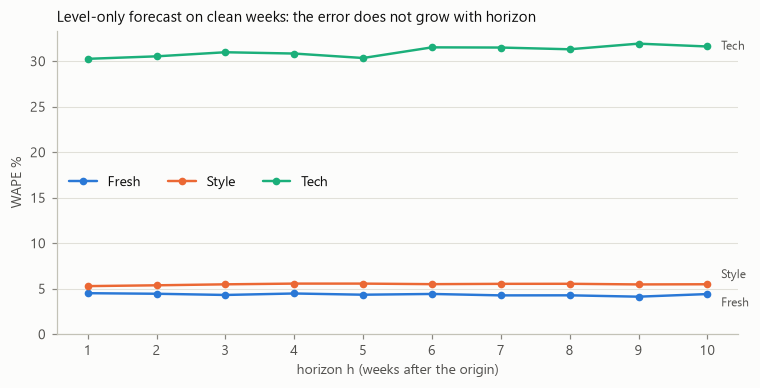

WAPE % by horizon (lvl_med8):


h,1,2,3,4,5,6,7,8,9,10
brand,,,,,,,,,,
Fresh,4.5,4.5,4.3,4.5,4.3,4.4,4.3,4.3,4.1,4.4
Style,5.3,5.4,5.5,5.6,5.6,5.5,5.5,5.5,5.5,5.5
Tech,30.3,30.5,31.0,30.8,30.4,31.5,31.5,31.3,31.9,31.6


In [34]:
ev = feat[(feat.is_future == 0) & (feat.origin_idx >= 52)].copy()
ev["t_clean"] = clean_flag(ev)
ev["lvl_trend"] = ev.lvl_med8 * np.exp(ev.trend26.clip(-0.01, 0.01).fillna(0) * (ev.h + 4.5))
LEVELS = ["lvl4", "lvl8", "lvl13", "lvl_med8", "lvl_trend"]
c = ev[ev.t_clean]
lev_tab = pd.DataFrame({lv: c.groupby("brand").apply(lambda g: wape(g.y_total, g[lv] * g.n_operating_days)) for lv in LEVELS})
print(f"WAPE of level x operating days on clean target weeks ({len(c):,} rows):")
display((100 * lev_tab).round(1))

hz = c.groupby(["brand", "h"]).apply(lambda g: wape(g.y_total, g.lvl_med8 * g.n_operating_days)).unstack("brand")
fig, ax = plt.subplots(figsize=(7, 3.6))
for b, dy_lab in zip(BRANDS, [-1.0, 1.0, 0.0]):
    ax.plot(hz.index, 100 * hz[b], color=BRAND_COLOR[b], marker="o", ms=4, label=b)
    ax.text(hz.index[-1] + 0.2, 100 * hz[b].iloc[-1] + dy_lab, b, color=INK2, va="center", fontsize=8)
ax.set_xlabel("horizon h (weeks after the origin)")
ax.set_ylabel("WAPE %")
ax.set_ylim(0, None)
ax.set_xticks(range(1, 11))
ax.legend(loc="center left", ncol=3)
ax.set_title("Level-only forecast on clean weeks: the error does not grow with horizon", loc="left")
fig.tight_layout()
save(fig, "p4_01_horizon_decay")
print("WAPE % by horizon (lvl_med8):")
(100 * hz.T).round(1)


### 4.6 Do the festival analogs carry signal?

Fresh only, target weeks inside a festival window (ramp > 0 or festival week), h = 4 so each target week appears once per series. The question: which last-year analog best predicts this year's `y_ratio_opd`, the ISO-week one or the festival-relative one?

Fresh festival-window weeks, actual ratio_opd vs each analog:


,n,corr,MAE vs actual
ISO-week analog,34.0,0.714,0.088
festival-relative analog,34.0,0.058,0.123
1 + ramp × (strength − 1) / 3.3,34.0,0.917,0.045


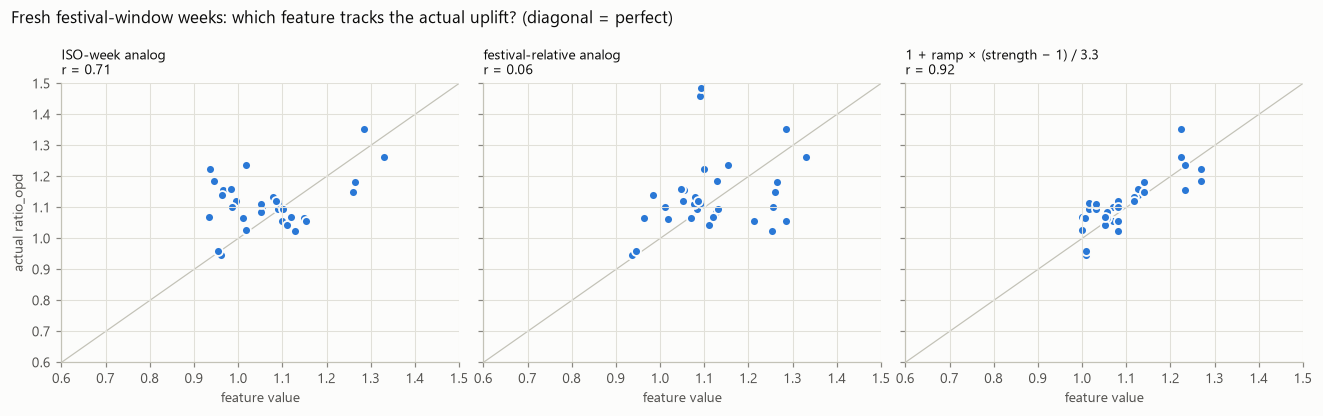

F1 origin (2025 wk 13), Peliyagoda-Fresh: analogs vs actual


,n_operating_days,ramp_sum_operating,near_festival,fest_rel_week,ly_ramp,ly_ratio_opd,fr_ramp,fr_ratio,fest_strength,dow_weight,y_ratio_opd
iso_week,,,,,,,,,,,
14,6,0.1,new_year,-2.0,0.6,1.09,0.0,1.09,1.55,6.00,1.11
15,6,3.3,new_year,-1.0,3.5,1.56,0.6,1.09,1.55,6.00,1.48
16,4,0.0,new_year,0.0,0.0,1.02,3.5,1.56,1.55,4.09,1.03
17,6,0.0,new_year,1.0,0.0,1.09,0.0,1.02,1.55,6.00,1.05
18,5,0.1,vesak,-2.0,0.0,1.15,0.0,0.96,1.23,4.95,1.07
19,6,3.3,vesak,-1.0,0.0,0.96,1.5,1.05,1.23,6.00,1.16
20,6,1.0,vesak,0.0,1.5,1.05,3.4,1.26,1.23,6.00,1.10
21,6,0.0,vesak,1.0,3.4,1.26,0.0,1.07,1.23,6.00,1.06
22,6,0.0,poson,-2.0,0.0,1.07,0.0,0.99,1.10,6.00,1.08


Real origin (2026 wk 13), Peliyagoda-Fresh: the features the final model will see


,n_operating_days,ramp_sum_operating,near_festival,fest_rel_week,ly_ramp,ly_ratio_opd,fr_ramp,fr_ratio,fest_strength,dow_weight
iso_week,,,,,,,,,,
14,6,0.1,new_year,-2.0,0.1,1.13,0.1,1.13,1.49,6.00
15,6,3.3,new_year,-1.0,3.3,1.48,3.3,1.48,1.49,6.00
16,4,0.0,new_year,0.0,0.0,1.02,0.0,1.02,1.49,4.10
17,6,1.0,vesak,-1.0,0.0,1.04,3.3,1.15,1.19,6.00
18,5,3.0,vesak,0.0,0.1,1.06,1.0,1.06,1.19,4.96
19,6,0.0,vesak,1.0,3.3,1.15,0.0,1.01,1.19,6.00
20,6,0.0,poson,-2.0,1.0,1.06,0.0,1.04,1.09,6.00
21,6,0.6,poson,-1.0,0.0,1.01,2.7,1.08,1.09,6.00
22,6,4.5,poson,0.0,0.0,1.04,1.9,1.04,1.09,6.00


In [35]:
fw = ev[(ev.brand == "Fresh") & ((ev.ramp_sum_operating > 0) | (ev.has_festival == 1)) & (ev.h == 4)].copy()
fw["ramp_pred"] = 1 + fw.ramp_x_strength / 3.3          # strength spread over a full 3.3 run-up week
cands = {"ly_ratio_opd": "ISO-week analog", "fr_ratio": "festival-relative analog", "ramp_pred": "1 + ramp × (strength − 1) / 3.3"}
sig = pd.DataFrame({lab: {"n": int(fw[col].notna().sum()),
                          "corr": fw[["y_ratio_opd", col]].corr().iloc[0, 1],
                          "MAE vs actual": (fw.y_ratio_opd - fw[col]).abs().mean()}
                    for col, lab in cands.items()}).T
print("Fresh festival-window weeks, actual ratio_opd vs each analog:")
display(sig.round(3))

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)
for ax, (col, lab) in zip(axes, cands.items()):
    d = fw.dropna(subset=[col])
    ax.plot([0.6, 1.5], [0.6, 1.5], color=AXIS, lw=0.8, zorder=0)
    ax.scatter(d[col], d.y_ratio_opd, s=34, color=C1, edgecolor=SURFACE, linewidth=1.2)
    ax.set_title(f"{lab}\nr = {sig.loc[lab, 'corr']:.2f}", loc="left", fontsize=9)
    ax.set_xlabel("feature value")
    ax.set_xlim(0.6, 1.5)
    ax.grid(axis="x")
axes[0].set_ylabel("actual ratio_opd")
axes[0].set_ylim(0.6, 1.5)
fig.suptitle("Fresh festival-window weeks: which feature tracks the actual uplift? (diagonal = perfect)", x=0.01, ha="left", fontsize=11)
fig.tight_layout()
save(fig, "p4_02_festival_analogs")

show = ["iso_week", "n_operating_days", "ramp_sum_operating", "near_festival", "fest_rel_week",
        "ly_ramp", "ly_ratio_opd", "fr_ramp", "fr_ratio", "fest_strength", "dow_weight"]
print("F1 origin (2025 wk 13), Peliyagoda-Fresh: analogs vs actual")
display(feat[(feat.origin_idx == 64) & (feat.series == "Peliyagoda-Fresh")][show + ["y_ratio_opd"]].round(2).set_index("iso_week"))
print("Real origin (2026 wk 13), Peliyagoda-Fresh: the features the final model will see")
sub[sub.series == "Peliyagoda-Fresh"][show].round(2).set_index("iso_week")


### 4.7 Chilled share features
Fresh target weeks with a year of history: which share feature, multiplied by the *actual* total, gets chilled volume closest? This isolates the share error from the total error.

In [36]:
cs = ev[(ev.brand == "Fresh") & ev.share_seasonal.notna()]
share_tab = pd.DataFrame({col: {"MAE (pp)": 100 * (cs.y_share - cs[col]).abs().mean(),
                                "bias (pp)": 100 * (cs[col] - cs.y_share).mean(),
                                "chilled WAPE %": 100 * wape(cs.y_chilled, cs.y_total * cs[col])}
                          for col in ["share_recent6", "share_ly_target", "share_seasonal"]}).T
print(f"{len(cs):,} Fresh target rows (origins 2025 wk 7 onward)")
display(share_tab.round(2))
print("Same comparison on the F1 window only (origin 2025 wk 13, target wk 14-23):")
f1 = cs[cs.origin_idx == 64]
pd.DataFrame({col: [100 * (f1.y_share - f1[col]).abs().mean(), 100 * (f1[col] - f1.y_share).mean()]
              for col in ["share_recent6", "share_ly_target", "share_seasonal"]}, index=["MAE (pp)", "bias (pp)"]).round(2)


1,090 Fresh target rows (origins 2025 wk 7 onward)


,MAE (pp),bias (pp),chilled WAPE %
share_recent6,0.69,0.01,1.84
share_ly_target,0.45,0.00,1.19
share_seasonal,0.48,0.00,1.26


Same comparison on the F1 window only (origin 2025 wk 13, target wk 14-23):


,share_recent6,share_ly_target,share_seasonal
MAE (pp),0.79,0.46,0.56
bias (pp),-0.76,0.04,-0.19


### 4.8 Feature signal by brand
Spearman correlation of each feature with `y_ratio_week` (the weekly total relative to the origin's level), origins from 2025 wk 1 onward. It shows what drives the weekly number per brand, before any model is fit.

In [37]:
num = [f for f in FEATURES if f not in ("weeks_since_clean",)] + ["h"]
corr = pd.DataFrame({b: ev[ev.brand == b][num + ["y_ratio_week"]].corr(method="spearman")["y_ratio_week"].drop("y_ratio_week")
                     for b in BRANDS})
corr = corr.dropna(how="all")
corr.reindex(corr.abs().max(axis=1).sort_values(ascending=False).index).head(18).round(2)


,Fresh,Style,Tech
ramp_x_strength,0.51,0.25,0.12
ramp_sum_operating,0.50,0.22,0.18
fr_ramp,0.44,0.16,0.11
ramp_max,0.40,0.13,0.14
ly_ratio_opd,0.36,0.39,0.17
fr_ratio_brand,0.37,0.26,0.09
weeks_to_next_festival,-0.35,-0.02,-0.17
fr_ratio,0.34,0.21,0.04
n_paydays_operating,0.30,0.01,0.16
n_operating_days,0.19,0.26,-0.09


### Phase 4 done: findings and decisions for Phase 5

| # | Finding | Decision for Phase 5 |
|---|---|---|
| 1 | `features_origin.parquet`: **6,030 rows × 54 columns**. 105 origins (2024 wk 13 to 2026 wk 13) × 6 series × up to 10 target weeks, 38 features. The 60 rows from origin 2026 wk 13 are exactly the submission rows. | Every Phase 5 model trains on this table, and every Phase 6 fold is a filter on `origin_idx` (F1 = 64). |
| 2 | **Leakage test passes.** Replacing every outcome after the origin with random numbers leaves all 38 features unchanged, for 4 origins including the real one. | The table is horizon-safe by construction. Re-run 4.4 after any feature change. |
| 3 | On clean weeks, level × operating days alone gives WAPE **Fresh 4.0%, Style 5.3%, Tech 30%**, close to each series' noise floor (Phase 3). The **mean** of 8 or 13 clean weeks beats the median (Fresh 4.0 vs 4.4). Extrapolating `trend26` makes every brand worse. | Base level = mean of the last 8–13 clean weeks. **No trend term** over a 10-week horizon. |
| 4 | **Error does not grow with h** (Fresh 4.1–4.5% from h = 1 to h = 10). The level is stable for 10 weeks. | One origin level serves all 10 weeks. `h` is a minor feature. |
| 5 | For Fresh festival weeks, **ramp × festival strength predicts the uplift best** (r = 0.92, MAE 0.045). The ISO-week analog does worse (r = 0.71, MAE 0.088), and the festival-relative analog fails (r = 0.06). The festival falls on a different weekday each year, so "the week before the festival" holds a different share of the run-up: 2024 New Year was a Saturday, so its wk −1 had ramp 0.6, not 3.3. | Model the festival effect as `ramp_sum_operating × (fest_strength − 1)`, learned per brand. Use analogs only as weak extra features. |
| 6 | Festival strength going into 2026 (Fresh, from the 2025 occurrence): **New Year 1.49, Vesak 1.19, Poson 1.09**. | These are the inputs the 2026 forecast will scale the ramps by. |
| 7 | `dow_weight` turns closed days into lost demand correctly: 2026 wk 16 (Mon + Tue closed) = 4.10 days, not 4; wk 18 (Fri 1 May closed) = 4.96, not 5. | Use `dow_weight` instead of `n_operating_days` wherever a model scales by "days of demand". |
| 8 | Chilled share: **last year's same-week share is best** (MAE 0.45 pp, chilled WAPE 1.2%). Adding the 2026-vs-2025 offset slightly hurts (0.48 pp). The recent 6-week share is worst (0.69 pp) and under-forecasts the F1 window by 0.76 pp. | Default: `share_ly_target`. Phase 6 confirms it against `share_seasonal`. This updates Phase 3 finding 7. |
| 9 | Signal by brand (Spearman with `y_ratio_week`). **Fresh:** ramp × strength 0.51, paydays 0.30. **Style:** last year's same week 0.39, operating days 0.26 (the schedule). **Tech:** nothing above 0.22. | Fresh needs ramp, strength and payday terms. Style needs the schedule and the seasonal analog. Tech = level × days. |
| 10 | Past-week ratios now use a more robust baseline than Phase 3: the last 6 clean weeks at least 3 weeks back, however far that is. Without it, last year's ratio was missing for 2026 wk 22–23. | No action; already in the features. |

**Next: Phase 5, models from simple to complex.**

## Phase 5: Models, from simple to complex

Every model is a function of one **origin** `o`. It may only use data up to the end of week `o`, and it forecasts weeks `o+1 … o+10`, exactly like the real task (origin 2026 wk 13).

| Model | Idea | Uses |
|---|---|---|
| `B1_SEASONAL` | Same ISO week last year × growth (`yoy8`) | `features_origin` |
| `B2_RECENT` | Normal level (`lvl8`) × operating days | `features_origin` |
| `STRUCT` | Daily: level × day-of-week × payday × (1 + festival slope × ramp), summed over the week's operating days | `daily_panel`, learned per origin |
| `LGBM` | One global LightGBM on all 6 series, predicting the ratio of the week to a normal week | `features_origin` |
| `ENS` | Average of `STRUCT` and `LGBM` | — |

**Chilled (all models):** `pred_chilled = pred_total × share`, Fresh only. The share is last year's same-week share (`share_ly_target`). `B2_RECENT` uses the recent 6-week share, as in the plan. Style and Tech chilled = 0.

**Scoring here:** a quick comparison on all origins from 2025 wk 7 to 2026 wk 3 (every model has a forecast there), and on F1. The full validation (per horizon, per fold, blend weights) is Phase 6. All forecasts are saved to `backtest_preds.parquet` for it.

### 5.0 Setup

In [38]:
import lightgbm as lgb

feat = pd.read_parquet(PROCESSED / "features_origin.parquet")
wk["clean"] = clean_flag(wk)                      # calendar-only flag, safe for any week

# Which festival each ramp day belongs to (the first festival on or after the date)
fd = (wk[wk.has_festival == 1].drop_duplicates("week_idx")[["festival_date", "festival_name"]]
      .sort_values("festival_date").reset_index(drop=True))
fdates = fd.festival_date.to_numpy()
dyx = dy.merge(wk[["series", "week_idx", "clean"]], on=["series", "week_idx"])
pos = np.minimum(np.searchsorted(fdates, dyx.date.to_numpy()), len(fdates) - 1)
in_ramp = (dyx.festival_ramp > 0).to_numpy()
dyx["ramp_fest"] = np.where(in_ramp, fd.festival_name.to_numpy()[pos], "")
dyx["ramp_fest_date"] = pd.Series(np.where(in_ramp, fdates[pos], np.datetime64("NaT", "us")), index=dyx.index)
assert (dyx.loc[in_ramp, "ramp_fest_date"] >= dyx.loc[in_ramp, "date"]).all()

week_end = week_start + pd.Timedelta(days=6)
PRED_ORIGINS = list(range(FIRST_ORIGIN, ORIGIN_IDX - HORIZON + 1)) + [ORIGIN_IDX]   # backtest origins + the real one
F1_ORIGIN = 64
MODEL_LABEL = {"B1_SEASONAL": "Seasonal naive", "B2_RECENT": "Recent-mean naive", "STRUCT": "Structural",
               "LGBM": "LightGBM", "ENS": "Ensemble (STRUCT + LGBM)"}
print(f"{len(PRED_ORIGINS)} origins; ramp days tagged with their festival: {in_ramp.sum():,}")


96 origins; ramp days tagged with their festival: 1,080


### 5.1 Baselines

- **`B1_SEASONAL`** = `ly_total × yoy8`. `yoy8` = last 8 clean weeks vs the same weeks a year earlier. Only available from origin 2025 wk 7.
- **`B2_RECENT`** = `lvl8 × n_operating_days`, i.e. the mean volume per operating day of the last 8 clean weeks times the target week's open days.

In [39]:
base_cols = ["origin_idx", "series", "depot", "brand", "week_idx", "iso_year", "iso_week", "h", "row_id", "is_future",
             "y_total", "y_chilled", "n_operating_days", "ramp_sum_operating", "has_festival",
             "share_recent6", "share_ly_target"]
P = feat[feat.origin_idx.isin(PRED_ORIGINS)].copy()
P["B1_SEASONAL"] = P.ly_total * P.yoy8
P["B2_RECENT"] = P.lvl8 * P.n_operating_days

print("Example, F1 origin, Peliyagoda-Fresh:")
P[(P.origin_idx == F1_ORIGIN) & (P.series == "Peliyagoda-Fresh")][
    ["iso_week", "ly_total", "yoy8", "B1_SEASONAL", "lvl8", "n_operating_days", "B2_RECENT", "y_total"]].round(2).set_index("iso_week")


Example, F1 origin, Peliyagoda-Fresh:


,ly_total,yoy8,B1_SEASONAL,lvl8,n_operating_days,B2_RECENT,y_total
iso_week,,,,,,,
14,942.06,1.05,988.82,154.3,6,925.81,1015.80
15,1117.57,1.05,1173.05,154.3,6,925.81,1351.01
16,879.39,1.05,923.04,154.3,4,617.21,623.49
17,938.57,1.05,985.16,154.3,6,925.81,960.82
18,827.62,1.05,868.70,154.3,5,771.51,810.85
19,844.84,1.05,886.78,154.3,6,925.81,1054.27
20,923.44,1.05,969.28,154.3,6,925.81,1004.64
21,1099.40,1.05,1153.97,154.3,6,925.81,962.76
22,941.30,1.05,988.02,154.3,6,925.81,983.70


### 5.2 Structural model

For every operating day `d` of a target week:

```
pred_day = L × f[dow] × (1 + p × payday) × (1 + b[brand, festival] × ramp)
pred_week = Σ pred_day over the week's operating days      (closed days add nothing: demand is lost)
```

Everything is learned from data up to the origin:

| Piece | How it is estimated |
|---|---|
| `f[dow]` day-of-week factor | Clean weeks: each day ÷ its week's daily mean, averaged per weekday (non-payday days), normalised to mean 1. **Tech: flat (1.0)**, too noisy. For Style it captures the outlets' fixed order days. |
| `p` payday uplift | Per brand, pooled over depots: payday days vs other days after removing `f`. |
| `L` level | Last 13 clean weeks (**Tech: 26**): total volume ÷ Σ `f × payday` factor over their operating days. |
| `b` festival slope | For each past festival (complete before the origin) and brand: `b = Σ ramp·(actual/expected − 1) / Σ ramp²`, with *expected* using the level from just before that festival's ramp. `b[brand, festival]` = mean over the past occurrences of that festival. Unseen festival, or Tech: the brand's mean over all festivals. |

At ramp 1.0 (the festival day, if open) a day is `1 + b` times normal. The ramp is linear (Phase 3: R² 0.91 for Fresh).

In [40]:
def fit_structural(o, n_lvl=13, n_lvl_tech=26, fest_agg="mean"):
    d = dyx[dyx.week_idx <= o]                                    # history only
    is_tech = lambda s: s.endswith("Tech")
    nwin = lambda s: n_lvl_tech if is_tech(s) else n_lvl

    # Day-of-week factors from clean weeks
    cd = d[d.clean & (d.is_operating == 1)].copy()
    cd["q"] = cd.total_vol / cd.groupby(["series", "week_idx"]).total_vol.transform("mean")
    f = cd[cd.is_payday == 0].groupby(["series", "dow"]).q.mean()
    f = f / f.groupby(level="series").transform("mean")
    f[np.array([is_tech(s) for s in f.index.get_level_values("series")])] = 1.0

    def fac(df):
        return f.reindex(pd.MultiIndex.from_arrays([df.series, df.dow])).fillna(0).to_numpy()

    # Payday uplift per brand
    cd["f"] = fac(cd)
    cd = cd[cd.f > 0]
    cd["x"] = cd.q / cd.f
    pay = cd.groupby(["brand", "is_payday"]).x.mean().unstack()
    p = (pay[1] / pay[0] - 1).rename("p")

    def expected(df):
        return fac(df) * (1 + df.brand.map(p).to_numpy() * df.is_payday.to_numpy())

    # Level: volume / expected factor over the last N clean weeks before a given week
    cd["e"] = expected(cd)
    wkly = cd.groupby(["series", "week_idx"]).agg(v=("total_vol", "sum"), e=("e", "sum")).reset_index()
    lv = {s: (g.week_idx.to_numpy(), g.v.to_numpy(), g.e.to_numpy()) for s, g in wkly.groupby("series")}

    def level(s, before):
        idx, v, e = lv[s]
        m = idx < before
        return v[m][-nwin(s):].sum() / e[m][-nwin(s):].sum() if m.sum() >= 2 else np.nan

    L = {s: level(s, o + 1) for s in lv}

    # Festival slopes from complete past festivals
    rd = d[(d.festival_ramp > 0) & (d.is_operating == 1) & (d.ramp_fest_date <= week_end[o])].copy()
    rd["e"] = expected(rd)
    rd = rd[rd.e > 0]
    start = rd.groupby(["series", "ramp_fest_date"]).week_idx.transform("min")
    rd["L"] = [level(s, w) for s, w in zip(rd.series, start)]
    rd["dev"] = rd.total_vol / (rd.L * rd.e) - 1
    rd = rd.dropna(subset=["dev"])
    rd["num"], rd["den"] = rd.festival_ramp * rd.dev, rd.festival_ramp ** 2
    occ = (rd.groupby(["brand", "ramp_fest", "ramp_fest_date"]).agg(num=("num", "sum"), den=("den", "sum"))
           .reset_index().sort_values("ramp_fest_date"))
    occ["b"] = occ.num / occ.den                                  # least-squares slope through the origin
    bF = occ.groupby(["brand", "ramp_fest"]).b.agg(fest_agg)
    bP = occ.groupby("brand").b.mean()
    return dict(o=o, f=f, p=p, L=L, occ=occ, bF=bF, bP=bP, expected=expected)


def predict_structural(m):
    o = m["o"]
    last = o + HORIZON if o == ORIGIN_IDX else min(o + HORIZON, ORIGIN_IDX)
    td = dyx[(dyx.week_idx > o) & (dyx.week_idx <= last) & (dyx.is_operating == 1)].copy()
    b = m["bF"].reindex(pd.MultiIndex.from_arrays([td.brand, td.ramp_fest])).to_numpy()
    b = np.where(np.isnan(b) | (td.brand == "Tech").to_numpy(), td.brand.map(m["bP"]).to_numpy(), b)
    td["pred"] = td.series.map(m["L"]) * m["expected"](td) * (1 + np.nan_to_num(b) * td.festival_ramp)
    return td.groupby(["series", "week_idx"]).pred.sum().rename("STRUCT").reset_index().assign(origin_idx=o)


STRUCT_FITS = {o: fit_structural(o) for o in PRED_ORIGINS}
P = P.drop(columns="STRUCT", errors="ignore").merge(
    pd.concat([predict_structural(STRUCT_FITS[o]) for o in PRED_ORIGINS]), on=["origin_idx", "series", "week_idx"], how="left")
assert P.STRUCT.notna().all()

# What the model learned at the F1 origin and at the real origin
for o in (F1_ORIGIN, ORIGIN_IDX):
    m = STRUCT_FITS[o]
    print(f"\n=== Origin {o} ({int(wk.loc[wk.week_idx == o, 'iso_year'].iloc[0])} wk {int(wk.loc[wk.week_idx == o, 'iso_week'].iloc[0])}) ===")
    print("Level L (m³ per average operating day):", {k: round(v, 1) for k, v in m["L"].items()})
    print("Payday uplift p:", m["p"].round(3).to_dict())
    print("Day-of-week factors f (Mon..Sat):")
    display(m["f"].unstack("dow").drop(columns=6, errors="ignore").round(3))
    print("Festival slope b (uplift at ramp 1.0), mean over past occurrences:")
    display(m["bF"].unstack("brand").round(3))



=== Origin 64 (2025 wk 13) ===
Level L (m³ per average operating day): {'Kandy-Fresh': np.float64(80.4), 'Kandy-Style': np.float64(13.1), 'Kandy-Tech': np.float64(3.6), 'Peliyagoda-Fresh': np.float64(154.1), 'Peliyagoda-Style': np.float64(22.4), 'Peliyagoda-Tech': np.float64(4.5)}
Payday uplift p: {'Fresh': 0.064, 'Style': 0.051, 'Tech': -0.001}
Day-of-week factors f (Mon..Sat):


dow,0,1,2,3,4,5
series,,,,,,
Kandy-Fresh,0.931,0.891,0.963,0.996,1.102,1.117
Kandy-Style,1.946,0.000,0.924,2.459,0.000,0.670
Kandy-Tech,1.000,1.000,1.000,1.000,1.000,1.000
Peliyagoda-Fresh,0.962,0.949,0.886,1.046,1.040,1.117
Peliyagoda-Style,0.673,0.000,1.141,2.182,2.005,0.000
Peliyagoda-Tech,1.000,1.000,1.000,1.000,1.000,1.000


Festival slope b (uplift at ramp 1.0), mean over past occurrences:


brand,Fresh,Style,Tech
ramp_fest,,,
christmas,0.637,0.837,0.387
deepavali,0.414,0.731,0.029
esala,0.194,0.192,-0.453
new_year,0.772,1.117,0.647
poson,0.198,0.026,-0.480
thai_pongal,0.237,0.166,-0.254
vesak,0.346,0.038,-0.531



=== Origin 116 (2026 wk 13) ===
Level L (m³ per average operating day): {'Kandy-Fresh': np.float64(86.2), 'Kandy-Style': np.float64(12.8), 'Kandy-Tech': np.float64(3.8), 'Peliyagoda-Fresh': np.float64(162.8), 'Peliyagoda-Style': np.float64(23.4), 'Peliyagoda-Tech': np.float64(5.2)}
Payday uplift p: {'Fresh': 0.068, 'Style': 0.058, 'Tech': 0.133}
Day-of-week factors f (Mon..Sat):


dow,0,1,2,3,4,5
series,,,,,,
Kandy-Fresh,0.932,0.889,0.964,0.997,1.099,1.119
Kandy-Style,1.923,0.000,0.903,2.468,0.000,0.706
Kandy-Tech,1.000,1.000,1.000,1.000,1.000,1.000
Peliyagoda-Fresh,0.962,0.947,0.891,1.045,1.039,1.117
Peliyagoda-Style,0.671,0.000,1.119,2.210,2.000,0.000
Peliyagoda-Tech,1.000,1.000,1.000,1.000,1.000,1.000


Festival slope b (uplift at ramp 1.0), mean over past occurrences:


brand,Fresh,Style,Tech
ramp_fest,,,
christmas,0.621,1.057,1.279
deepavali,0.381,0.771,-0.043
esala,0.239,0.496,0.248
new_year,0.790,1.115,0.797
poson,0.204,-0.013,-0.268
thai_pongal,0.224,0.113,0.081
vesak,0.332,0.087,-0.455


### 5.2b Worked example: the structural equation, day by day

Peliyagoda-Fresh, forecast made at the real origin (end of 2026 wk 13), for 2026 wk 14 (h = 1) and wk 15 (h = 2). Every number below is the model's own learned value.

```
pred_day  = L × f[dow] × (1 + p × payday) × (1 + b × ramp)        (open days only; closed days = 0)
STRUCT    = Σ pred_day over the week
STRUCT_G  = STRUCT × yoy8 ^ ((h + 6.5) / 52)                       (growth correction, Fresh and Style)
chilled   = STRUCT_G × share_ly_target                              (Fresh only)
```

In [41]:
ex_s = "Peliyagoda-Fresh"
m = STRUCT_FITS[ORIGIN_IDX]
brand = ex_s.split("-")[1]
for ex_w in (ORIGIN_IDX + 1, ORIGIN_IDX + 2):
    d = dyx[(dyx.series == ex_s) & (dyx.week_idx == ex_w)].sort_values("date").copy()
    d["L"] = m["L"][ex_s]
    d["f_dow"] = m["f"].reindex(pd.MultiIndex.from_arrays([d.series, d.dow])).fillna(0).to_numpy()
    d["payday_x"] = 1 + m["p"][brand] * d.is_payday
    d["b"] = [m["bF"].get((brand, fz), m["bP"][brand]) if r > 0 else 0.0 for fz, r in zip(d.ramp_fest, d.festival_ramp)]
    d["festival_x"] = 1 + d.b * d.festival_ramp
    d["pred_day"] = np.where(d.is_operating == 1, d.L * d.f_dow * d.payday_x * d.festival_x, 0.0)
    row = P[(P.origin_idx == ORIGIN_IDX) & (P.series == ex_s) & (P.week_idx == ex_w)].iloc[0]
    growth = row.yoy8 ** ((row.h + 6.5) / 52)
    print(f"\n2026 wk {int(row.iso_week)} (h = {int(row.h)}), {ex_s}")
    display(d[["date", "dow_name", "is_operating", "is_payday", "festival_ramp", "ramp_fest", "L", "f_dow",
               "payday_x", "b", "festival_x", "pred_day"]].assign(date=d.date.dt.strftime("%a %d %b")).round(3).set_index("date"))
    week = d.pred_day.sum()
    assert np.isclose(week, row.STRUCT)
    print(f"STRUCT   = sum of days                        = {week:,.1f} m³")
    print(f"growth   = yoy8 {row.yoy8:.4f} ^ (({int(row.h)} + 6.5) / 52) = {growth:.4f}")
    print(f"STRUCT_G = {week:,.1f} × {growth:.4f}               = {week * growth:,.1f} m³")
    print(f"chilled  = {week * growth:,.1f} × share_ly_target {row.share_ly_target:.4f} = {week * growth * row.share_ly_target:,.1f} m³")



2026 wk 14 (h = 1), Peliyagoda-Fresh


,dow_name,is_operating,is_payday,festival_ramp,ramp_fest,L,f_dow,payday_x,b,festival_x,pred_day
date,,,,,,,,,,,
Mon 30 Mar,Mon,1,0,0.0,,162.807,0.962,1.000,0.00,1.000,156.628
Tue 31 Mar,Tue,1,1,0.0,,162.807,0.947,1.068,0.00,1.000,164.640
Wed 01 Apr,Wed,1,0,0.0,,162.807,0.891,1.000,0.00,1.000,145.044
Thu 02 Apr,Thu,1,0,0.0,,162.807,1.045,1.000,0.00,1.000,170.135
Fri 03 Apr,Fri,1,0,0.0,,162.807,1.039,1.000,0.00,1.000,169.079
Sat 04 Apr,Sat,1,0,0.1,new_year,162.807,1.117,1.000,0.79,1.079,196.148
Sun 05 Apr,Sun,0,0,0.2,new_year,162.807,0.000,1.000,0.79,1.158,0.000


STRUCT   = sum of days                        = 1,001.7 m³
growth   = yoy8 1.0643 ^ ((1 + 6.5) / 52) = 1.0090
STRUCT_G = 1,001.7 × 1.0090               = 1,010.7 m³
chilled  = 1,010.7 × share_ly_target 0.3800 = 384.1 m³

2026 wk 15 (h = 2), Peliyagoda-Fresh


,dow_name,is_operating,is_payday,festival_ramp,ramp_fest,L,f_dow,payday_x,b,festival_x,pred_day
date,,,,,,,,,,,
Mon 06 Apr,Mon,1,0,0.3,new_year,162.807,0.962,1.0,0.79,1.237,193.726
Tue 07 Apr,Tue,1,0,0.4,new_year,162.807,0.947,1.0,0.79,1.316,202.845
Wed 08 Apr,Wed,1,0,0.5,new_year,162.807,0.891,1.0,0.79,1.395,202.301
Thu 09 Apr,Thu,1,0,0.6,new_year,162.807,1.045,1.0,0.79,1.474,250.730
Fri 10 Apr,Fri,1,0,0.7,new_year,162.807,1.039,1.0,0.79,1.553,262.522
Sat 11 Apr,Sat,1,0,0.8,new_year,162.807,1.117,1.0,0.79,1.632,296.620
Sun 12 Apr,Sun,0,0,0.9,new_year,162.807,0.000,1.0,0.79,1.711,0.000


STRUCT   = sum of days                        = 1,408.7 m³
growth   = yoy8 1.0643 ^ ((2 + 6.5) / 52) = 1.0102
STRUCT_G = 1,408.7 × 1.0102               = 1,423.2 m³
chilled  = 1,423.2 × share_ly_target 0.3708 = 527.8 m³


### 5.3 Global LightGBM

One model for all 6 series, trained on `features_origin`.

- **Target:** `r = y_total / (lvl13 × dow_weight)`, i.e. how far the week is from a normal week with the same open days. One ratio scale for all series lets one model learn the festival and payday multipliers across them.
- **Prediction:** `lvl13 × dow_weight × r̂`.
- **Training rows at origin `o`:** only rows whose *target* week is ≤ `o`, because those labels were known at `o`. Refit at every origin.
- **Loss:** L1 (the WAPE-optimal loss), weighted by `lvl13 × dow_weight` so big series count more, as in WAPE.
- **Small, regularised trees** (7 leaves, ≥ 40 rows per leaf), because there are few festival examples.
- **Features:** the short list from Phase 4 (calendar, ramp × strength, paydays, last year's ratio, brand/depot flags, `h`).

In [42]:
feat["is_fresh"] = (feat.brand == "Fresh").astype(int)
feat["is_style"] = (feat.brand == "Style").astype(int)
feat["is_kandy"] = (feat.depot == "Kandy").astype(int)
feat["base_ml"] = feat.lvl13 * feat.dow_weight
feat["r_ml"] = feat.y_total / feat.base_ml

ML_FEATS = ["h", "is_fresh", "is_style", "is_kandy", "n_operating_days", "dow_weight", "n_closed_weekdays",
            "n_paydays_operating", "ramp_sum_operating", "ramp_max", "has_festival", "fest_day_closed",
            "fest_strength", "ramp_x_strength", "ly_ratio_opd", "cv13", "yoy8"]
LGB_PARAMS = dict(objective="l1", learning_rate=0.03, n_estimators=400, num_leaves=7, min_child_samples=40,
                  subsample=0.8, subsample_freq=1, colsample_bytree=0.8, reg_lambda=5.0, verbose=-1, random_state=SEED)
MIN_TRAIN_ROWS = 600


def fit_lgbm(o):
    tr = feat[(feat.week_idx <= o) & (feat.is_future == 0)]
    if len(tr) < MIN_TRAIN_ROWS:
        return None
    return lgb.LGBMRegressor(**LGB_PARAMS).fit(tr[ML_FEATS], tr.r_ml, sample_weight=tr.base_ml)


LGBM_FITS, out = {}, []
for o in PRED_ORIGINS:
    LGBM_FITS[o] = fit_lgbm(o)
    te = feat[feat.origin_idx == o]
    if LGBM_FITS[o] is not None:
        out.append(te[["origin_idx", "series", "week_idx"]].assign(LGBM=te.base_ml * LGBM_FITS[o].predict(te[ML_FEATS])))
P = P.drop(columns="LGBM", errors="ignore").merge(pd.concat(out), on=["origin_idx", "series", "week_idx"], how="left")
P["ENS"] = (P.STRUCT + P.LGBM) / 2
print(f"LightGBM fitted at {sum(v is not None for v in LGBM_FITS.values())} of {len(PRED_ORIGINS)} origins "
      f"(first: origin {min(o for o, v in LGBM_FITS.items() if v is not None)}; earlier origins have < {MIN_TRAIN_ROWS} labelled rows)")

imp = pd.Series(LGBM_FITS[ORIGIN_IDX].booster_.feature_importance("gain"), index=ML_FEATS)
print("Feature importance at the real origin (share of total gain):")
(imp / imp.sum()).sort_values(ascending=False).round(3).to_frame("gain share").T


LightGBM fitted at 81 of 96 origins (first: origin 27; earlier origins have < 600 labelled rows)
Feature importance at the real origin (share of total gain):


,n_paydays_operating,ly_ratio_opd,ramp_sum_operating,ramp_x_strength,cv13,fest_strength,ramp_max,yoy8,is_kandy,h,is_style,dow_weight,is_fresh,n_operating_days,fest_day_closed,has_festival,n_closed_weekdays
gain share,0.208,0.194,0.175,0.104,0.092,0.065,0.043,0.042,0.023,0.016,0.012,0.007,0.006,0.006,0.006,0.001,0.0


### 5.4 Tech variants

Tech is about 30% noise (Phase 3). Compare the simplest options on Tech only:
- **`TECH_FLAT`:** mean of the last 26 clean weeks × operating days, with no festival or payday terms.
- **`B2_RECENT`, `STRUCT`, `LGBM`:** as above.

In [43]:
def tech_flat(o):
    h_ = wk[(wk.week_idx <= o) & (wk.brand == "Tech") & wk.clean]
    return h_.groupby("series").vol_per_op_day.apply(lambda s: s.tail(26).mean())


P["TECH_FLAT"] = np.nan
for o in PRED_ORIGINS:
    m = (P.origin_idx == o) & (P.brand == "Tech")
    P.loc[m, "TECH_FLAT"] = P.loc[m, "series"].map(tech_flat(o)) * P.loc[m, "n_operating_days"]

common = P[(P.is_future == 0) & P[["B1_SEASONAL", "B2_RECENT", "STRUCT", "LGBM"]].notna().all(axis=1)]
tt = common[common.brand == "Tech"]
print(f"Tech, origins {common.origin_idx.min()}-{common.origin_idx.max()} ({len(tt)} rows), WAPE %:")
pd.DataFrame({m: [100 * wape(tt.y_total, tt[m]), 100 * wape(tt[tt.origin_idx == F1_ORIGIN].y_total, tt[tt.origin_idx == F1_ORIGIN][m])]
              for m in ["B1_SEASONAL", "B2_RECENT", "TECH_FLAT", "STRUCT", "LGBM", "ENS"]}, index=["all origins", "F1"]).round(1)


Tech, origins 58-106 (980 rows), WAPE %:


,B1_SEASONAL,B2_RECENT,TECH_FLAT,STRUCT,LGBM,ENS
all origins,36.6,32.0,31.9,31.7,29.7,30.4
F1,35.8,36.3,36.4,36.3,32.9,34.6


### 5.5–5.6 Chilled volume, ensemble, and the comparison

Long format: one row per origin × series × week × model, with `pred_total` and `pred_chilled`. Saved as `backtest_preds.parquet` for Phase 6.

- **Score `both`** = WAPE over total and chilled together: Σ|errors of both columns| ÷ Σ(actual total + actual chilled).
- **Festival-window weeks:** a ramp, a festival, or a closed weekday in the week. **Normal weeks:** everything else.

In [44]:
MODEL_NAMES = ["B1_SEASONAL", "B2_RECENT", "STRUCT", "LGBM", "ENS", "TECH_FLAT"]
share = P.share_ly_target.fillna(P.share_recent6)
long = []
for mname in MODEL_NAMES:
    t = P[["origin_idx", "series", "depot", "brand", "week_idx", "iso_year", "iso_week", "h", "row_id", "is_future",
           "y_total", "y_chilled", "n_operating_days", "ramp_sum_operating", "has_festival"]].copy()
    t["model"] = mname
    t["pred_total"] = P[mname].clip(lower=0)
    sh = P.share_recent6 if mname == "B2_RECENT" else share
    t["pred_chilled"] = np.where(t.brand == "Fresh", t.pred_total * sh, 0.0)
    long.append(t.dropna(subset=["pred_total"]))
preds = pd.concat(long, ignore_index=True)
preds["fest_window"] = ((preds.ramp_sum_operating > 0) | (preds.has_festival == 1) | (preds.n_operating_days < 6)).astype(int)
assert (preds.pred_chilled <= preds.pred_total + 1e-9).all()
preds.to_parquet(PROCESSED / "backtest_preds.parquet", index=False)
print(f"backtest_preds.parquet: {len(preds):,} rows")


def wape_both(g):
    return (np.abs(g.y_total - g.pred_total).sum() + np.abs(g.y_chilled - g.pred_chilled).sum()) / (g.y_total.sum() + g.y_chilled.sum())


def compare(df):
    rows = {}
    for mname in ["B1_SEASONAL", "B2_RECENT", "STRUCT", "LGBM", "ENS"]:
        g = df[df.model == mname]
        r = {"both": wape_both(g), "total": wape(g.y_total, g.pred_total),
             "chilled": wape(g[g.brand == "Fresh"].y_chilled, g[g.brand == "Fresh"].pred_chilled)}
        for b in BRANDS:
            r[b] = wape(g[g.brand == b].y_total, g[g.brand == b].pred_total)
        r["normal wks"] = wape(g[g.fest_window == 0].y_total, g[g.fest_window == 0].pred_total)
        r["festival wks"] = wape(g[g.fest_window == 1].y_total, g[g.fest_window == 1].pred_total)
        rows[MODEL_LABEL[mname]] = r
    return (100 * pd.DataFrame(rows).T).round(2)


keys = common[["origin_idx", "series", "week_idx"]]
pc = preds.merge(keys, on=["origin_idx", "series", "week_idx"])
yw = lambda o: "{} wk {}".format(*wk.loc[wk.week_idx == o, ["iso_year", "iso_week"]].iloc[0])
print(f"ALL ORIGINS {yw(common.origin_idx.min())} to {yw(common.origin_idx.max())} "
      f"({common.origin_idx.nunique()} origins x 10 weeks x 6 series), WAPE %:")
display(compare(pc))
print("F1: origin 2025 wk 13 -> 2025 wk 14-23, WAPE %:")
compare(pc[pc.origin_idx == F1_ORIGIN])


backtest_preds.parquet: 26,160 rows
ALL ORIGINS 2025 wk 7 to 2026 wk 3 (49 origins x 10 weeks x 6 series), WAPE %:


,both,total,chilled,Fresh,Style,Tech,normal wks,festival wks
Seasonal naive,7.47,7.72,6.65,6.40,9.73,36.56,6.05,10.87
Recent-mean naive,7.45,7.64,6.83,6.40,10.17,32.04,4.93,12.73
Structural,4.47,4.73,3.61,3.45,6.90,31.71,4.64,4.91
LightGBM,5.12,5.42,4.13,3.96,9.46,29.67,4.28,7.58
Ensemble (STRUCT + LGBM),4.36,4.65,3.43,3.25,7.88,30.43,4.04,5.80


F1: origin 2025 wk 13 -> 2025 wk 14-23, WAPE %:


,both,total,chilled,Fresh,Style,Tech,normal wks,festival wks
Seasonal naive,11.61,11.79,11.04,11.03,11.61,35.84,8.23,13.29
Recent-mean naive,11.43,11.28,11.88,10.18,13.28,36.32,5.55,13.71
Structural,4.07,4.29,3.37,3.15,4.95,36.34,4.91,4.03
LightGBM,8.24,8.64,6.99,7.19,13.21,32.87,5.98,9.77
Ensemble (STRUCT + LGBM),5.06,5.37,4.10,3.94,8.71,34.60,3.23,6.28


### Plot 11: F1, actual vs forecast
**Question:** where does each model win or lose in the 2025 festival season?

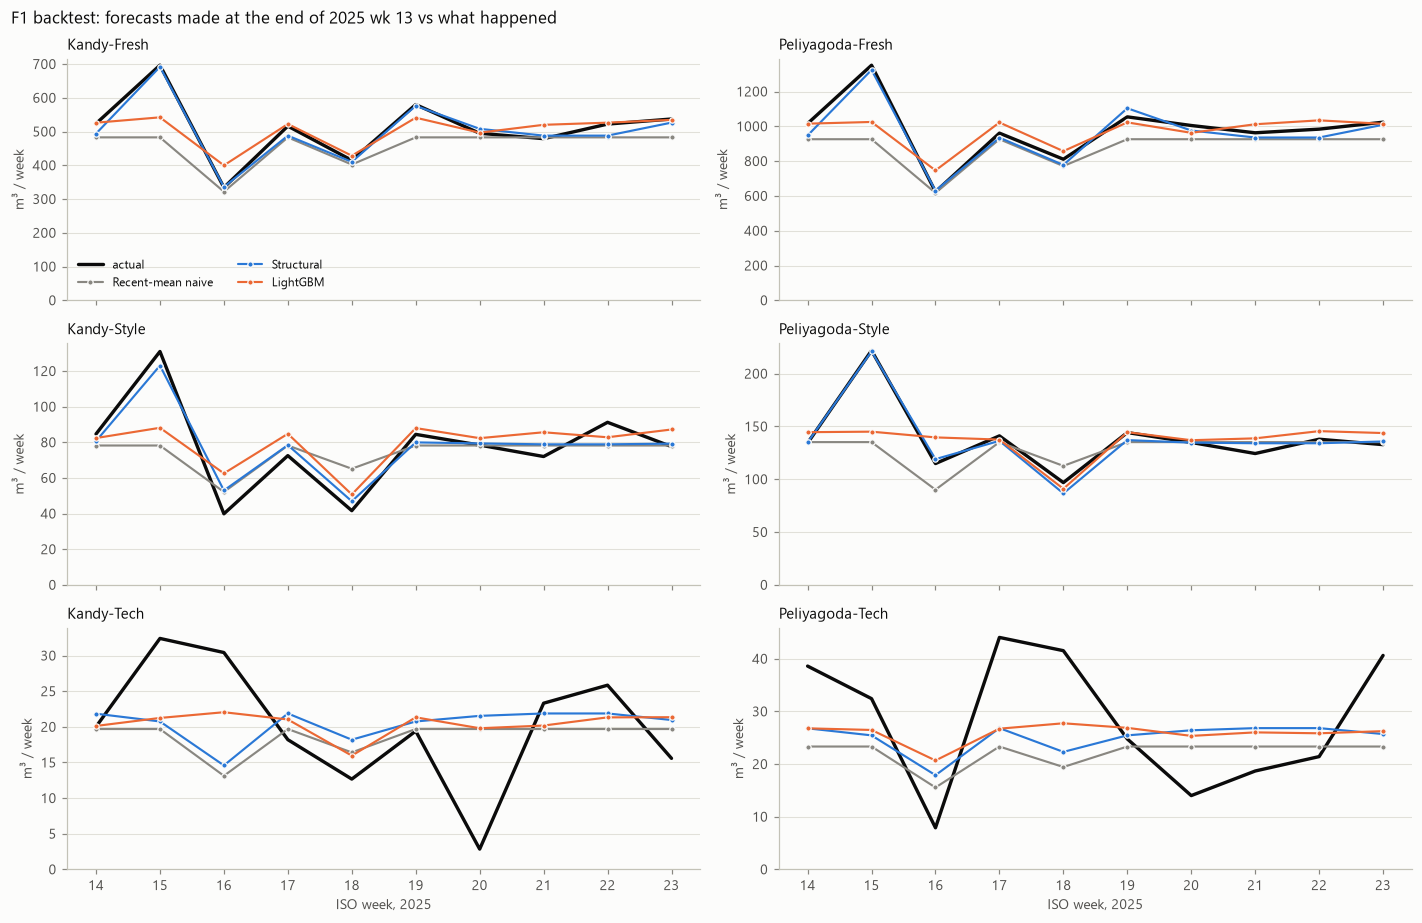

In [45]:
f1p = preds[preds.origin_idx == F1_ORIGIN]
fig, axes = plt.subplots(3, 2, figsize=(13, 8.5), sharex=True)
for ax, s in zip(axes.flat, SERIES_ORDER):
    g = f1p[f1p.series == s]
    act = g[g.model == "STRUCT"].sort_values("iso_week")
    ax.plot(act.iso_week, act.y_total, color=INK, lw=2.2, label="actual")
    for mname, col in [("B2_RECENT", MUTED), ("STRUCT", C1), ("LGBM", C2)]:
        gm = g[g.model == mname].sort_values("iso_week")
        ax.plot(gm.iso_week, gm.pred_total, color=col, lw=1.4, marker="o", ms=3.5, mec=SURFACE, mew=0.8, label=MODEL_LABEL[mname])
    ax.set_title(s, loc="left")
    ax.set_ylim(0, None)
    ax.set_ylabel("m³ / week")
for ax in axes[-1]:
    ax.set_xlabel("ISO week, 2025")
    ax.set_xticks(range(14, 24))
axes[0, 0].legend(loc="lower left", ncol=2, fontsize=8)
fig.suptitle("F1 backtest: forecasts made at the end of 2025 wk 13 vs what happened", x=0.01, ha="left", fontsize=11)
fig.tight_layout()
save(fig, "p5_01_f1_actual_vs_forecast")


### Plot 12: What the structural model learned (real origin)
**Question:** how much does each festival lift a day at the top of its run-up, per brand?

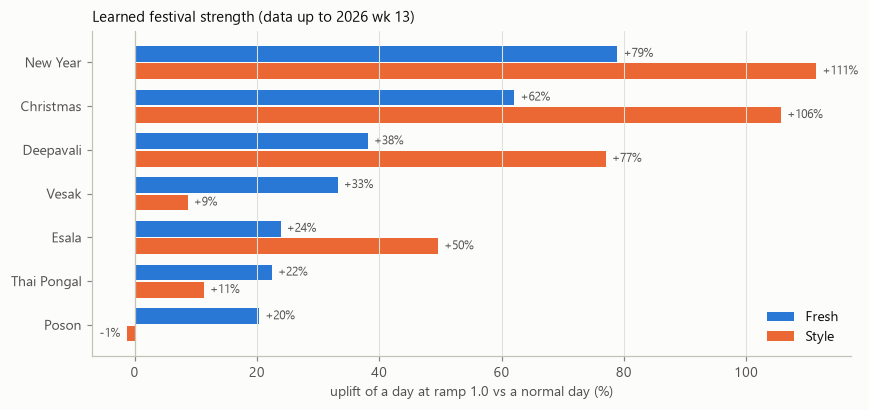

Tech uses one pooled slope: 0.234


In [46]:
m = STRUCT_FITS[ORIGIN_IDX]
bt = m["bF"].unstack("brand")[["Fresh", "Style"]]
bt = bt.loc[bt.Fresh.sort_values().index]
fig, ax = plt.subplots(figsize=(8, 3.8))
y = np.arange(len(bt))
for k, (b, off) in enumerate([("Fresh", 0.2), ("Style", -0.2)]):
    ax.barh(y + off, 100 * bt[b], height=0.36, color=BRAND_COLOR[b], label=b)
    for yi, v in zip(y + off, bt[b]):
        ax.text(100 * v + (1 if v >= 0 else -1), yi, f"{100 * v:+.0f}%", va="center", ha="left" if v >= 0 else "right",
                fontsize=8, color=INK2)
ax.set_yticks(y, [s.replace("_", " ").title() for s in bt.index])
ax.axvline(0, color=AXIS, lw=0.8)
ax.grid(axis="y", visible=False)
ax.grid(axis="x")
ax.set_xlabel("uplift of a day at ramp 1.0 vs a normal day (%)")
ax.legend(loc="lower right")
ax.set_title("Learned festival strength (data up to 2026 wk 13)", loc="left")
fig.tight_layout()
save(fig, "p5_02_festival_slopes")
print("Tech uses one pooled slope:", round(m["bP"]["Tech"], 3))


### 5.7 Preview: what each model says for 2026 wk 14–23
Not the submission yet (that is Phase 7, after Phase 6 picks the model). Shown so the numbers can be sanity-checked against last year.

In [47]:
fut = preds[(preds.origin_idx == ORIGIN_IDX)]
tot = fut.pivot_table(index="series", columns="model", values="pred_total", aggfunc="sum")[["B1_SEASONAL", "B2_RECENT", "STRUCT", "LGBM", "ENS", "TECH_FLAT"]]
ly10 = wk[(wk.iso_year == 2025) & wk.iso_week.between(14, 23)].groupby("series").total_vol.sum().rename("actual 2025 wk 14-23")
print("Total m³ over the 10 forecast weeks:")
display(pd.concat([tot, ly10], axis=1).round(0))
print("Peliyagoda-Fresh by week (m³), next to the same ISO week of 2025:")
pf = fut[fut.series == "Peliyagoda-Fresh"].pivot_table(index="iso_week", columns="model", values="pred_total")[["B2_RECENT", "STRUCT", "LGBM", "ENS"]]
pf["2025 actual"] = wk[(wk.series == "Peliyagoda-Fresh") & (wk.iso_year == 2025)].set_index("iso_week").total_vol.reindex(pf.index)
pf["2026 ramp"] = wk[(wk.series == "Peliyagoda-Fresh") & (wk.iso_year == 2026)].set_index("iso_week").ramp_sum_operating.reindex(pf.index)
pf["2026 open days"] = wk[(wk.series == "Peliyagoda-Fresh") & (wk.iso_year == 2026)].set_index("iso_week").n_operating_days.reindex(pf.index)
pf.round(1)


Total m³ over the 10 forecast weeks:


,B1_SEASONAL,B2_RECENT,STRUCT,LGBM,ENS,TECH_FLAT,actual 2025 wk 14-23
series,,,,,,,
Kandy-Fresh,5508.0,4954.0,5393.0,5429.0,5411.0,NaN,5100.0
Kandy-Style,755.0,726.0,797.0,816.0,807.0,NaN,773.0
Kandy-Tech,209.0,195.0,228.0,231.0,230.0,217.0,201.0
Peliyagoda-Fresh,10421.0,9361.0,10187.0,10258.0,10223.0,NaN,9791.0
Peliyagoda-Style,1429.0,1327.0,1445.0,1473.0,1459.0,NaN,1383.0
Peliyagoda-Tech,411.0,321.0,316.0,381.0,349.0,300.0,284.0


Peliyagoda-Fresh by week (m³), next to the same ISO week of 2025:


model,B2_RECENT,STRUCT,LGBM,ENS,2025 actual,2026 ramp,2026 open days
iso_week,,,,,,,
14,985.4,1001.7,1035.5,1018.6,1015.8,0.1,6
15,985.4,1408.7,1430.0,1419.4,1351.0,3.3,6
16,656.9,666.1,666.6,666.3,623.5,0.0,4
17,985.4,1047.9,1057.1,1052.5,960.8,1.0,6
18,821.1,979.1,944.2,961.6,810.9,3.0,5
19,985.4,976.8,969.3,973.0,1054.3,0.0,6
20,985.4,976.8,973.1,974.9,1004.6,0.0,6
21,985.4,998.3,1003.0,1000.7,962.8,0.6,6
22,985.4,1154.6,1200.7,1177.7,983.7,4.5,6


### Phase 5 done: findings

WAPE over total + chilled ("both"). "All origins" = 49 origins (2025 wk 7 to 2026 wk 3) × 10 weeks × 6 series.

| Model | All origins | F1 | Festival-window weeks (all origins) |
|---|---|---|---|
| Seasonal naive | 7.5% | 11.6% | 10.9% |
| Recent-mean naive | 7.5% | 11.4% | 12.7% |
| **Structural** | 4.5% | **4.1%** | **4.9%** |
| LightGBM | 5.1% | 8.2% | 7.6% |
| Ensemble | **4.4%** | 5.1% | 5.8% |

| # | Finding | Consequence |
|---|---|---|
| 1 | **The structural model is the strongest.** It cuts the naive error by 40% overall and by 65% on F1. Its festival-week error (4.9%) is almost the same as its normal-week error (4.6%), so the run-ups, closed days and paydays are captured. | Main model for Fresh and Style. |
| 2 | The naive baselines are fine in normal weeks (recent-mean 4.9%) but miss every surge (11–14% error in festival weeks). | They are the floor every model must beat. |
| 3 | LightGBM is best in **normal weeks (4.3%) and on Tech (29.7%)**, but under-predicts the surges (F1 Peliyagoda-Fresh wk 15) and is weak on Style (9.5%). Trees can't extrapolate from the few festival examples available at early origins. Its top features are paydays (21% of gain), last year's ratio (19%) and the ramp (18%). | Useful as a partner, not alone. |
| 4 | The 50/50 ensemble is best over all origins but worse than Structural on F1, because LightGBM drags the festival weeks down. | Phase 6 should pick weights **per brand** (and check festival vs normal weeks), not one global weight. |
| 5 | **Tech: every model is at 30–37%**, the noise floor. LightGBM 29.7%, Structural 31.7%, flat 26-week mean 31.9%, seasonal naive worst (36.6%). | Keep Tech simple; Phase 6 chooses between LightGBM, the ensemble and the flat mean. |
| 6 | Chilled = total × last year's same-week share: chilled WAPE **3.4–3.6%**, vs 6.8% with the recent share. | Chilled is settled. |
| 7 | Learned at the real origin (Fresh): payday day +6.8%; a day at the top of the run-up is New Year +79%, Christmas +62%, Deepavali +38%, Vesak +33%, Esala +24%, Thai Pongal +22%, Poson +20%. **Style** reacts strongly to New Year and Christmas (+111%, +106%) but barely to Vesak (+9%) or Poson (−1%). | Festival-specific slopes are necessary; one global uplift would be wrong for Style. |
| 8 | 2026 preview (Structural, Peliyagoda-Fresh): wk 15 ≈ 1,409 m³ (2025: 1,351), wk 16 ≈ 666 (4 open days), wk 18 ≈ 979 (Vesak run-up on 4 open days), wk 22 ≈ 1,155 (all of Poson's run-up falls in this week). Fresh 10-week totals are about 4–6% above 2025: growth plus more run-up days inside the window. | Plausible. Final numbers come in Phase 7. |

**Next: Phase 6, validation across all folds (F1–F5), per horizon and per series, and the blend weights.**

## Phase 6: Validation

Every forecast below was made the way the real one will be: standing at an origin, using only data up to it, predicting the next 10 weeks. **No random split anywhere.**

| Fold | Origin (forecast made at end of) | Forecast weeks | Why it matters |
|---|---|---|---|
| **F1 (primary)** | 2025 wk 13 | 2025 wk 14–23 | The same season as the real task: New Year, Vesak, Poson. |
| F2 | 2024 wk 13 | 2024 wk 14–23 | Only 13 weeks of history: a robustness test. Only `B2_RECENT` and `STRUCT` can run here (no last year, and too few rows to train LightGBM). |
| F3 | 2025 wk 26 | 2025 wk 27–36 | Mostly normal weeks, plus Esala. |
| F4 | 2025 wk 39 | 2025 wk 40–49 | Deepavali. |
| F5 | 2025 wk 52 | 2026 wk 1–10 | Christmas closure, Thai Pongal, and the Style wk 10 spike. |
| **All origins** | every week from 2025 wk 7 to 2026 wk 3 (49 origins) | the 10 weeks after each | The most stable average: 2,940 forecasts per model. |

**Metrics.**
- **WAPE both** (headline): total and chilled errors together, Σ|error| ÷ Σ actual.
- **MAE** and **RMSE** in m³ per series-week.
- **Bias:** Σ(forecast − actual) ÷ Σ actual. Negative means the model forecasts too low.

**Selection rule** (as the plan says, never F1 alone): score = ½ × F1 + ½ × all origins.

### 6.1 Setup

In [48]:
FOLDS = {"F1": 64, "F2": 12, "F3": 77, "F4": 90, "F5": 103}
MAIN = ["B1_SEASONAL", "B2_RECENT", "STRUCT", "LGBM", "ENS"]
bt = preds[preds.is_future == 0].copy()
ALL_O = sorted(bt[bt.model == "B1_SEASONAL"].origin_idx.unique())          # origins where every model has a forecast
ALL_O = [o for o in ALL_O if bt[(bt.origin_idx == o)].groupby("model").size().reindex(MAIN).min() == 60]
for f, o in FOLDS.items():
    print(f"{f}: origin {o} = {yw(o)} -> {yw(o + 1)} .. {yw(o + 10)}")
print(f"All origins: {len(ALL_O)} origins, {yw(ALL_O[0])} .. {yw(ALL_O[-1])}")


def metrics(g):
    e = g.pred_total - g.y_total
    return pd.Series({"WAPE both %": 100 * wape_both(g), "WAPE total %": 100 * wape(g.y_total, g.pred_total),
                      "WAPE chilled %": 100 * wape(g[g.brand == "Fresh"].y_chilled, g[g.brand == "Fresh"].pred_chilled),
                      "MAE m³": e.abs().mean(), "RMSE m³": np.sqrt((e ** 2).mean()), "bias %": 100 * e.sum() / g.y_total.sum()})


def fold_rows(df, models):
    out = {}
    for m in models:
        row = {}
        for f, o in FOLDS.items():
            g = df[(df.model == m) & (df.origin_idx == o)]
            row[f] = 100 * wape_both(g) if len(g) == 60 else np.nan
        g = df[(df.model == m) & df.origin_idx.isin(ALL_O)]
        row["mean F1,F3–F5"] = np.mean([row[f] for f in ["F1", "F3", "F4", "F5"]])
        row["all origins"] = 100 * wape_both(g)
        out[MODEL_LABEL.get(m, m)] = row
    return pd.DataFrame(out).T


F1: origin 64 = 2025 wk 13 -> 2025 wk 14 .. 2025 wk 23
F2: origin 12 = 2024 wk 13 -> 2024 wk 14 .. 2024 wk 23
F3: origin 77 = 2025 wk 26 -> 2025 wk 27 .. 2025 wk 36
F4: origin 90 = 2025 wk 39 -> 2025 wk 40 .. 2025 wk 49
F5: origin 103 = 2025 wk 52 -> 2026 wk 1 .. 2026 wk 10
All origins: 49 origins, 2025 wk 7 .. 2026 wk 3


### 6.2 Each model on each fold (WAPE both, %)
The one table to look at first. Lower is better; `NaN` = the model cannot run at that origin.

In [49]:
fold_tab = fold_rows(bt, MAIN)
fold_tab.round(2)


,F1,F2,F3,F4,F5,"mean F1,F3–F5",all origins
Seasonal naive,11.61,NaN,7.49,8.23,4.86,8.05,7.47
Recent-mean naive,11.43,11.04,7.21,6.55,6.10,7.82,7.45
Structural,4.07,10.48,5.50,4.12,4.58,4.57,4.47
LightGBM,8.24,NaN,4.57,4.84,4.86,5.63,5.12
Ensemble (STRUCT + LGBM),5.06,NaN,4.97,3.93,4.58,4.64,4.36


### 6.3 All metrics per model
All origins (top) and F1 (bottom). MAE and RMSE are in m³ per series-week, on total volume.

In [50]:
allo = bt[bt.origin_idx.isin(ALL_O)]
print("ALL ORIGINS")
display(pd.DataFrame({MODEL_LABEL[m]: metrics(allo[allo.model == m]) for m in MAIN}).T.round(2))
print("F1")
pd.DataFrame({MODEL_LABEL[m]: metrics(bt[(bt.model == m) & (bt.origin_idx == 64)]) for m in MAIN}).T.round(2)


ALL ORIGINS


,WAPE both %,WAPE total %,WAPE chilled %,MAE m³,RMSE m³,bias %
Seasonal naive,7.47,7.72,6.65,22.90,43.67,0.01
Recent-mean naive,7.45,7.64,6.83,22.66,44.65,-4.94
Structural,4.47,4.73,3.61,14.04,21.48,-1.90
LightGBM,5.12,5.42,4.13,16.09,29.98,-0.32
Ensemble (STRUCT + LGBM),4.36,4.65,3.43,13.79,22.31,-1.11


F1


,WAPE both %,WAPE total %,WAPE chilled %,MAE m³,RMSE m³,bias %
Seasonal naive,11.61,11.79,11.04,34.44,66.08,0.21
Recent-mean naive,11.43,11.28,11.88,32.97,71.49,-9.77
Structural,4.07,4.29,3.37,12.54,18.33,-1.96
LightGBM,8.24,8.64,6.99,25.25,54.56,-0.89
Ensemble (STRUCT + LGBM),5.06,5.37,4.10,15.70,29.75,-1.43


### 6.4 Per series (WAPE total, %)

In [51]:
def by_series(df):
    return pd.DataFrame({MODEL_LABEL[m]: df[df.model == m].groupby("series").apply(
        lambda g: 100 * wape(g.y_total, g.pred_total), include_groups=False) for m in MAIN}).T[SERIES_ORDER]


print("ALL ORIGINS")
display(by_series(allo).round(1))
print("F1")
by_series(bt[bt.origin_idx == 64]).round(1)


ALL ORIGINS


series,Kandy-Fresh,Peliyagoda-Fresh,Kandy-Style,Peliyagoda-Style,Kandy-Tech,Peliyagoda-Tech
Seasonal naive,6.7,6.3,12.2,8.4,46.5,29.5
Recent-mean naive,6.5,6.3,11.7,9.3,35.2,29.8
Structural,3.3,3.5,8.8,5.8,34.0,30.1
LightGBM,4.0,4.0,11.5,8.3,33.8,26.8
Ensemble (STRUCT + LGBM),3.3,3.2,9.7,6.9,33.7,28.1


F1


series,Kandy-Fresh,Peliyagoda-Fresh,Kandy-Style,Peliyagoda-Style,Kandy-Tech,Peliyagoda-Tech
Seasonal naive,10.6,11.3,16.3,9.0,42.3,31.2
Recent-mean naive,10.2,10.2,16.4,11.5,33.2,38.5
Structural,2.7,3.4,8.1,3.2,34.5,37.6
LightGBM,6.5,7.6,16.6,11.3,28.9,35.6
Ensemble (STRUCT + LGBM),4.3,3.8,11.9,7.0,31.7,36.6


### 6.5 Per week type
- **Run-up week:** ramp on open days > 0.
- **Short week:** fewer than 6 open days and no ramp.
- **Normal week:** everything else.

WAPE total %, all origins.

In [52]:
allo = allo.assign(week_type=np.select([allo.ramp_sum_operating > 0, allo.n_operating_days < 6], ["run-up week", "short week"], "normal week"))
wt = allo.groupby(["model", "week_type"]).apply(lambda g: 100 * wape(g.y_total, g.pred_total), include_groups=False).unstack()
wt.index = wt.index.map(MODEL_LABEL)
print("rows per model:", allo[allo.model == "STRUCT"].week_type.value_counts().to_dict())
wt.loc[[MODEL_LABEL[m] for m in MAIN], ["normal week", "run-up week", "short week"]].round(2)


rows per model: {'normal week': 1956, 'run-up week': 930, 'short week': 54}


week_type,normal week,run-up week,short week
model,,,
Seasonal naive,6.05,9.78,41.70
Recent-mean naive,4.93,12.94,7.01
Structural,4.64,4.93,4.55
LightGBM,4.28,7.14,20.05
Ensemble (STRUCT + LGBM),4.04,5.59,11.69


### Plot 13: Error by horizon
**Question:** does any model get worse the further ahead it forecasts?

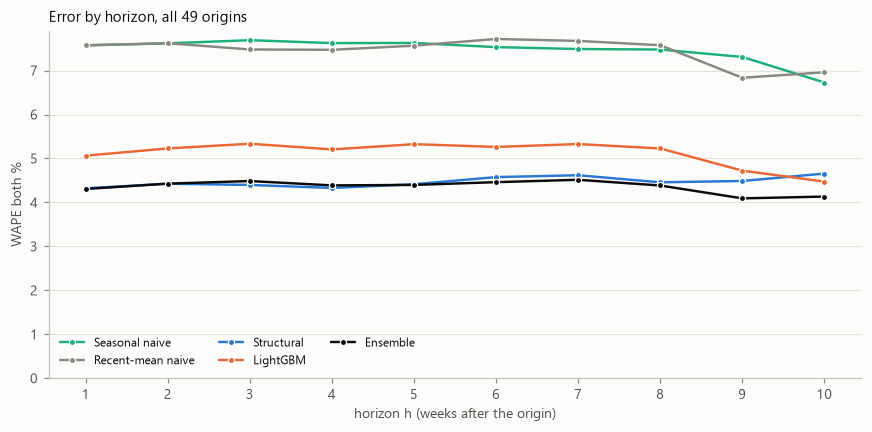

h,1,2,3,4,5,6,7,8,9,10
model,,,,,,,,,,
Seasonal naive,7.57,7.62,7.69,7.62,7.63,7.53,7.49,7.48,7.31,6.73
Recent-mean naive,7.58,7.62,7.48,7.47,7.57,7.72,7.67,7.58,6.84,6.96
Structural,4.32,4.43,4.40,4.33,4.41,4.58,4.62,4.46,4.49,4.66
LightGBM,5.06,5.23,5.34,5.21,5.33,5.26,5.33,5.23,4.72,4.47
Ensemble (STRUCT + LGBM),4.31,4.43,4.49,4.39,4.40,4.46,4.52,4.39,4.09,4.13


In [53]:
hz = allo.groupby(["model", "h"]).apply(lambda g: 100 * wape_both(g), include_groups=False).unstack("model")[MAIN]
STYLE = {"B1_SEASONAL": (C3, "Seasonal naive"), "B2_RECENT": (MUTED, "Recent-mean naive"),
         "STRUCT": (C1, "Structural"), "LGBM": (C2, "LightGBM"), "ENS": (INK, "Ensemble")}
fig, ax = plt.subplots(figsize=(8, 4))
for m in MAIN:
    col, lab = STYLE[m]
    ax.plot(hz.index, hz[m], color=col, marker="o", ms=4, mec=SURFACE, mew=0.8, lw=1.6, label=lab)
ax.set_xticks(range(1, 11))
ax.set_xlabel("horizon h (weeks after the origin)")
ax.set_ylabel("WAPE both %")
ax.set_ylim(0, None)
ax.legend(loc="lower left", ncol=3, fontsize=8)
ax.set_title("Error by horizon, all 49 origins", loc="left")
fig.tight_layout()
save(fig, "p6_01_wape_by_horizon")
hz.rename(columns=MODEL_LABEL).T.round(2)


### Plot 14: Every fold, actual vs forecast
One figure per depot, one row per fold.

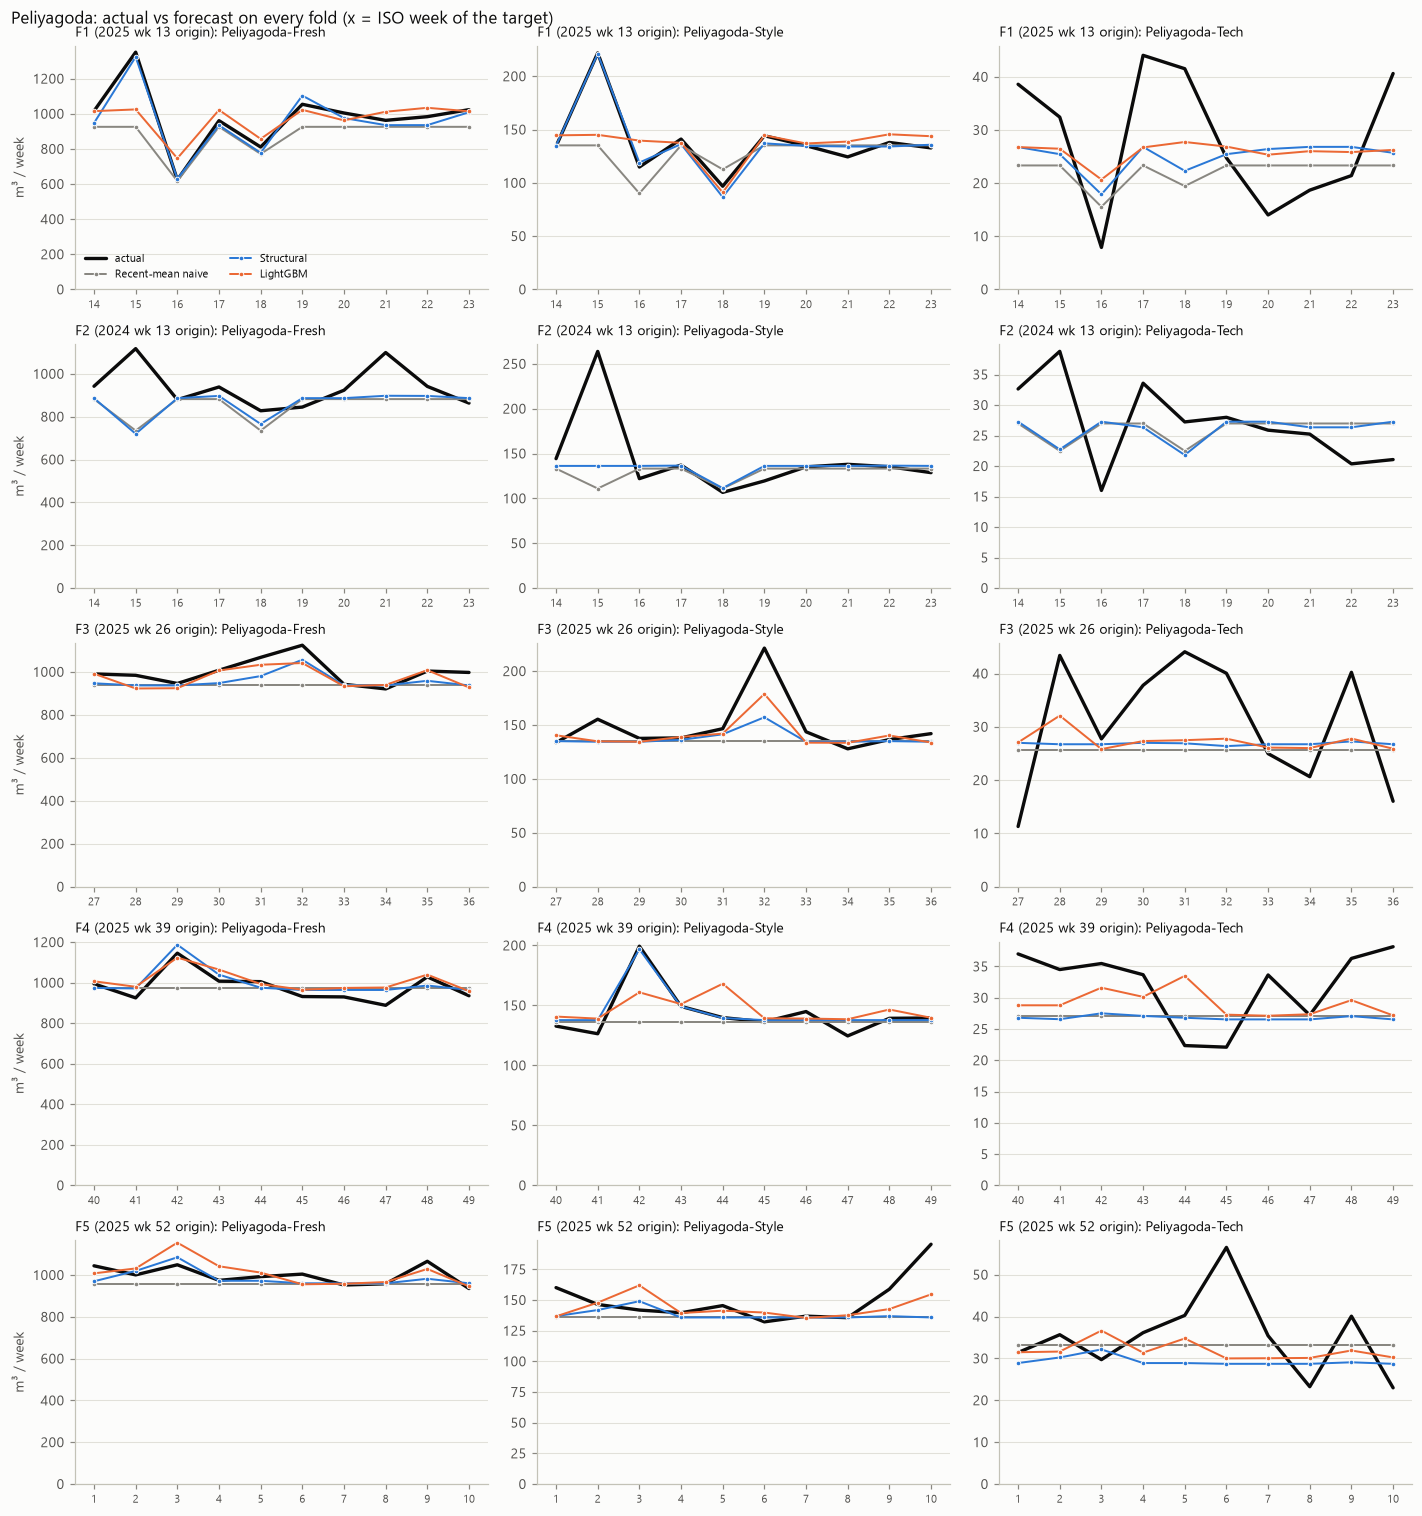

In [54]:
def plot_folds(depot, name):
    cols = [f"{depot}-{b}" for b in BRANDS]
    fig, axes = plt.subplots(len(FOLDS), 3, figsize=(13, 14))
    for i, (f, o) in enumerate(FOLDS.items()):
        for j, s in enumerate(cols):
            ax = axes[i, j]
            g = bt[(bt.origin_idx == o) & (bt.series == s)]
            a = g[g.model == "STRUCT"].sort_values("h")
            ax.plot(a.h, a.y_total, color=INK, lw=2.2, label="actual")
            for m in ["B2_RECENT", "STRUCT", "LGBM"]:
                gm = g[g.model == m].sort_values("h")
                if len(gm):
                    ax.plot(gm.h, gm.pred_total, color=STYLE[m][0], lw=1.3, marker="o", ms=3, mec=SURFACE, mew=0.6, label=STYLE[m][1])
            ax.set_xticks(a.h, a.iso_week, fontsize=7)
            ax.set_ylim(0, None)
            ax.set_title(f"{f} ({yw(o)} origin): {s}", loc="left", fontsize=9)
            if j == 0:
                ax.set_ylabel("m³ / week")
    axes[0, 0].legend(loc="lower left", fontsize=7, ncol=2)
    fig.suptitle(f"{depot}: actual vs forecast on every fold (x = ISO week of the target)", x=0.01, ha="left", fontsize=11)
    fig.tight_layout()
    save(fig, name)


plot_folds("Peliyagoda", "p6_02_folds_actual_vs_forecast")


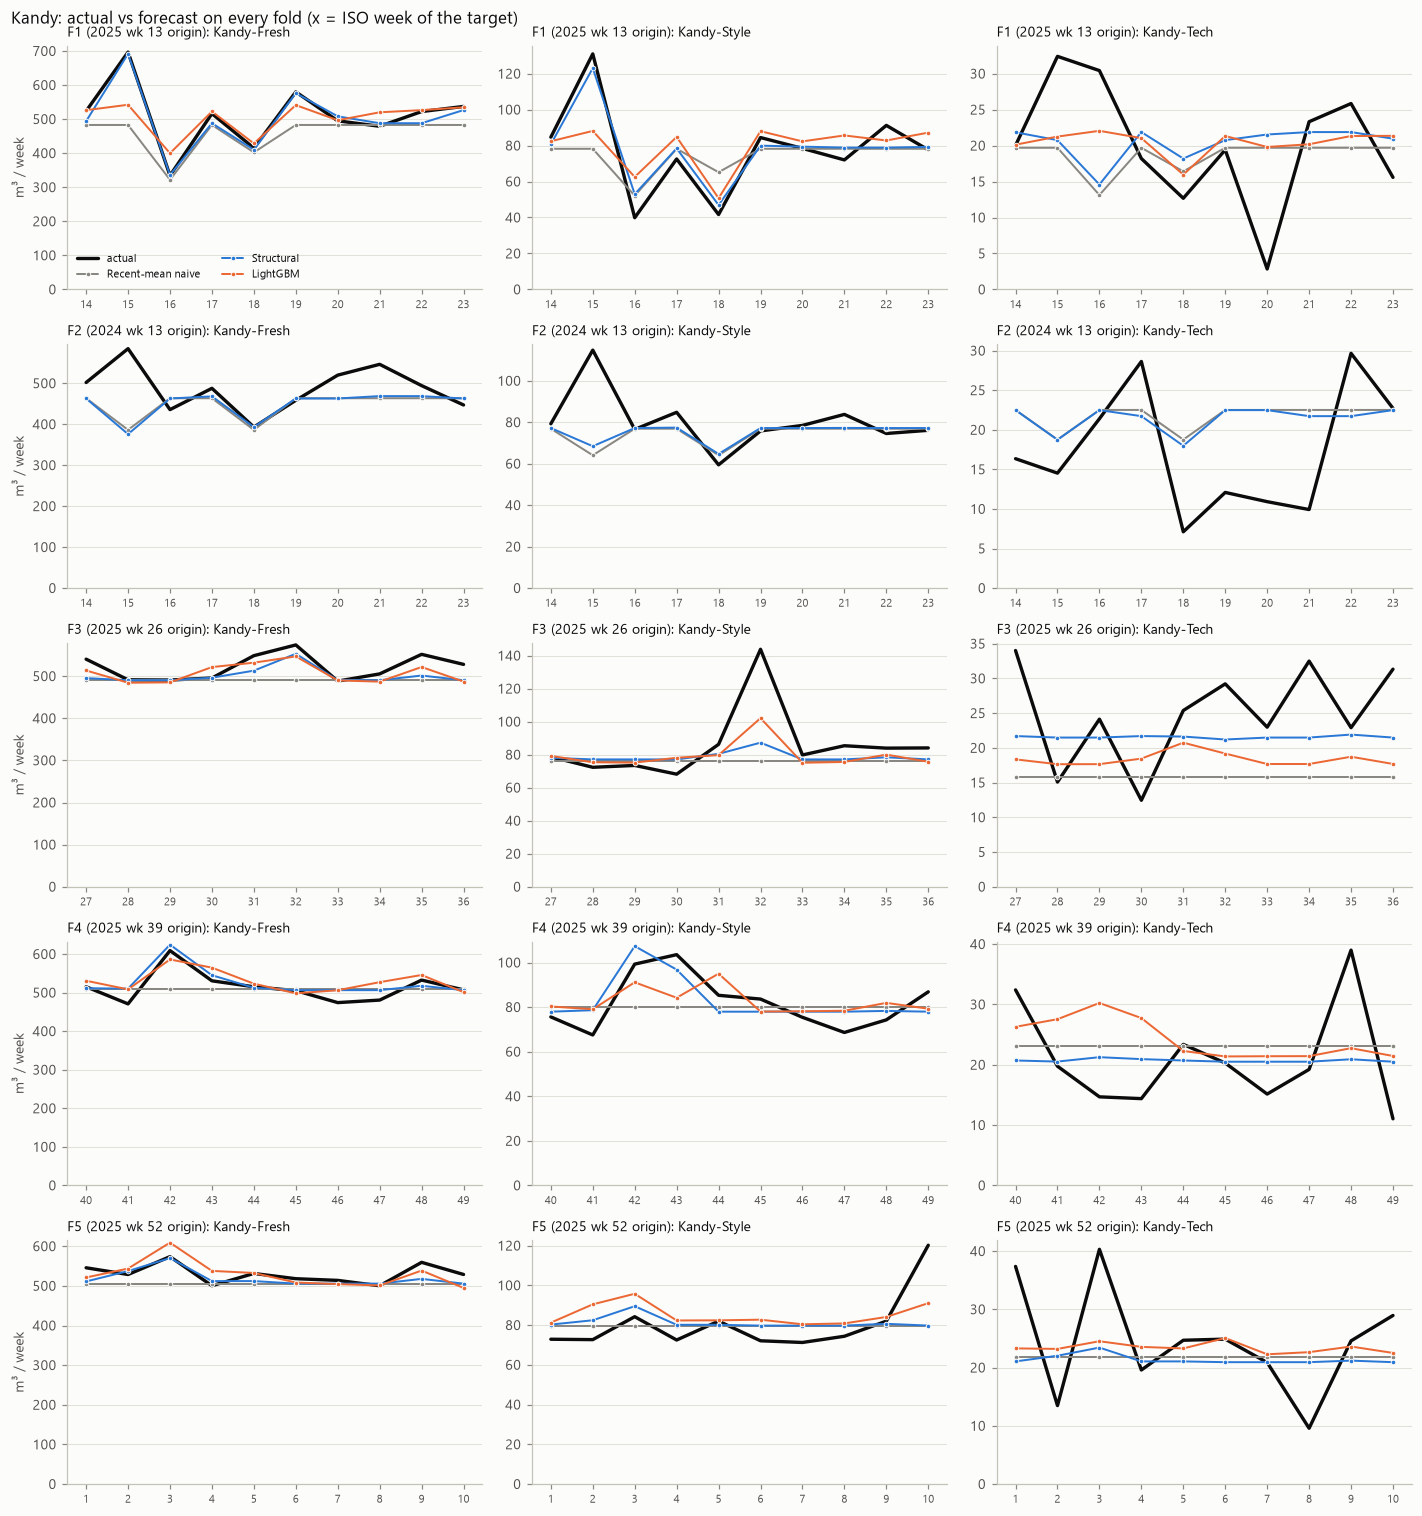

In [55]:
plot_folds("Kandy", "p6_03_folds_actual_vs_forecast_kandy")


### 6.6 Structural model settings

Two choices made in Phase 5 are tested here on all origins, F1 and F2:
- **Level window:** the last 13 clean weeks vs the last 8.
- **Festival slope:** the mean over all past occurrences of a festival vs only the last occurrence.

In [56]:
key_cols = ["origin_idx", "series", "week_idx"]
ref = P[P.origin_idx.isin(ALL_O + [12])][key_cols + ["brand", "y_total", "y_chilled", "share_ly_target", "share_recent6"]]


def eval_struct(**kw):
    fits = {o: fit_structural(o, **kw) for o in ALL_O + [12]}
    d = ref.merge(pd.concat([predict_structural(fits[o]) for o in fits]), on=key_cols)
    d = d.rename(columns={"STRUCT": "pred_total"})
    d["pred_chilled"] = np.where(d.brand == "Fresh", d.pred_total * d.share_ly_target.fillna(d.share_recent6), 0.0)
    return {"all origins": 100 * wape_both(d[d.origin_idx.isin(ALL_O)]), "F1": 100 * wape_both(d[d.origin_idx == 64]),
            "F2": 100 * wape_both(d[d.origin_idx == 12])}


variants = {"13 wks, mean slope (Phase 5)": dict(n_lvl=13, fest_agg="mean"),
            "8 wks, mean slope": dict(n_lvl=8, fest_agg="mean"),
            "13 wks, last slope": dict(n_lvl=13, fest_agg="last"),
            "8 wks, last slope": dict(n_lvl=8, fest_agg="last")}
var_tab = pd.DataFrame({k: eval_struct(**v) for k, v in variants.items()}).T
var_tab["score (½ F1 + ½ all)"] = (var_tab["F1"] + var_tab["all origins"]) / 2
display(var_tab.round(2))

# Why "mean" and "last" score the same: in the backtests almost every festival had only ONE past occurrence.
# They only differ for 2026, where New Year, Vesak and Poson each have two (2024 and 2025).
occ116 = STRUCT_FITS[ORIGIN_IDX]["occ"]
occ116 = occ116[occ116.ramp_fest.isin(["new_year", "vesak", "poson"]) & (occ116.brand != "Tech")]
print("Festival slope per occurrence, as seen from the real origin:")
display(occ116.assign(year=occ116.ramp_fest_date.dt.year).pivot_table(index=["brand", "ramp_fest"], columns="year", values="b").round(3))
tot_mean = predict_structural(fit_structural(ORIGIN_IDX, fest_agg="mean")).groupby("series").STRUCT.sum()
tot_last = predict_structural(fit_structural(ORIGIN_IDX, fest_agg="last")).groupby("series").STRUCT.sum()
print("2026 wk 14-23 total m³, mean slope vs last slope:")
pd.DataFrame({"mean": tot_mean, "last": tot_last, "diff %": 100 * (tot_last / tot_mean - 1)}).round(1)


,all origins,F1,F2,score (½ F1 + ½ all)
"13 wks, mean slope (Phase 5)",4.47,4.07,10.48,4.27
"8 wks, mean slope",4.39,4.11,10.84,4.25
"13 wks, last slope",4.47,4.07,10.48,4.27
"8 wks, last slope",4.39,4.11,10.84,4.25


Festival slope per occurrence, as seen from the real origin:


year              2024   2025
brand ramp_fest              
Fresh new_year   0.773  0.806
      poson      0.199  0.208
      vesak      0.346  0.318
Style new_year   1.128  1.102
      poson      0.029 -0.055
      vesak      0.042  0.131

2026 wk 14-23 total m³, mean slope vs last slope:


,mean,last,diff %
series,,,
Kandy-Fresh,5393.1,5395.1,0.0
Kandy-Style,797.4,797.1,-0.0
Kandy-Tech,228.1,228.1,0.0
Peliyagoda-Fresh,10187.0,10190.7,0.0
Peliyagoda-Style,1444.6,1443.0,-0.1
Peliyagoda-Tech,316.0,316.0,0.0


### 6.7 Bias check and a growth correction

6.3 shows every model forecasts slightly **too low** (Structural −1.9%). The reason: the level is the average of the last 13 clean weeks, so it is centred about 6.5 weeks *before* the origin, while demand keeps growing (Fresh about +4–8% a year).

**`STRUCT_G`** = Structural × `yoy8 ^ ((h + 6.5) / 52)`. It moves the level forward by this series' own year-on-year growth, over the gap between the middle of the level window and the target week. Fresh and Style only; Tech has no stable growth.

This is not the same as Phase 4's `trend26`. That one fitted a slope to 26 noisy weeks; this uses the year-on-year growth of clean weeks, which is far more stable.

In [57]:
P["STRUCT_G"] = P.STRUCT * np.where(P.brand == "Tech", 1.0, P.yoy8.fillna(1.0) ** ((P.h + 6.5) / 52))
g_rows = P[["origin_idx", "series", "depot", "brand", "week_idx", "iso_year", "iso_week", "h", "row_id", "is_future",
            "y_total", "y_chilled", "n_operating_days", "ramp_sum_operating", "has_festival"]].copy()
g_rows["model"] = "STRUCT_G"
g_rows["pred_total"] = P.STRUCT_G.clip(lower=0)
g_rows["pred_chilled"] = np.where(g_rows.brand == "Fresh", g_rows.pred_total * P.share_ly_target.fillna(P.share_recent6), 0.0)
g_rows["fest_window"] = ((g_rows.ramp_sum_operating > 0) | (g_rows.has_festival == 1) | (g_rows.n_operating_days < 6)).astype(int)
preds = pd.concat([preds[preds.model != "STRUCT_G"], g_rows], ignore_index=True)
bt = preds[preds.is_future == 0]
MODEL_LABEL["STRUCT_G"] = "Structural + growth"

display(fold_rows(bt, ["STRUCT", "STRUCT_G"]).round(2))
print("Bias % by brand (all origins):")
ab = bt[bt.origin_idx.isin(ALL_O)]
ab.groupby(["model", "brand"]).apply(lambda g: 100 * (g.pred_total - g.y_total).sum() / g.y_total.sum(), include_groups=False
                                     ).unstack().loc[MAIN + ["STRUCT_G"]].rename(index=MODEL_LABEL).round(2)


,F1,F2,F3,F4,F5,"mean F1,F3–F5",all origins
Structural,4.07,10.48,5.50,4.12,4.58,4.57,4.47
Structural + growth,3.56,10.48,4.96,4.70,4.57,4.45,4.35


Bias % by brand (all origins):


brand,Fresh,Style,Tech
model,,,
Seasonal naive,0.22,0.81,-9.18
Recent-mean naive,-4.68,-5.27,-11.04
Structural,-1.54,-2.42,-9.96
LightGBM,-0.12,-0.61,-4.74
Ensemble (STRUCT + LGBM),-0.83,-1.52,-7.35
Structural + growth,-0.23,-1.95,-9.96


### 6.8 Chilled share choice
Same Structural totals, three share features. Chilled WAPE % (Fresh), per fold.

In [58]:
cs = P[(P.brand == "Fresh") & (P.is_future == 0)][key_cols + ["y_total", "y_chilled", "STRUCT", "share_ly_target", "share_seasonal", "share_recent6"]].copy()
rows = {}
for col in ["share_ly_target", "share_seasonal", "share_recent6"]:
    r = {}
    for f, o in FOLDS.items():
        g = cs[(cs.origin_idx == o) & cs[col].notna()]
        r[f] = 100 * wape(g.y_chilled, g.STRUCT * g[col]) if len(g) == 20 else np.nan
    g = cs[cs.origin_idx.isin(ALL_O)]
    r["all origins"] = 100 * wape(g.y_chilled, g.STRUCT * g[col])
    rows[col] = r
pd.DataFrame(rows).T.round(2)


,F1,F2,F3,F4,F5,all origins
share_ly_target,3.37,NaN,4.58,3.20,3.86,3.61
share_seasonal,3.52,NaN,4.71,3.68,3.84,3.74
share_recent6,4.45,10.41,3.41,4.95,3.76,3.98


### 6.9 The Tech week 17 question (Phase 3, finding 11)
Was Tech wk 17 above normal in both past years, in both depots? `ratio_opd` = volume per open day ÷ the normal level before it.

In [59]:
t17 = hw[(hw.brand == "Tech") & hw.iso_week.between(14, 21) & hw.iso_year.isin([2024, 2025])]
display(t17.pivot_table(index="iso_week", columns=["iso_year", "depot"], values="ratio_opd").round(2))
f1t = bt[(bt.origin_idx == 64) & (bt.brand == "Tech") & (bt.iso_week == 17)]
print("F1 forecasts for 2025 wk 17 (made at 2025 wk 13), m³:")
f1t.pivot_table(index="series", columns="model", values="pred_total").assign(
    actual=f1t.groupby("series").y_total.first()).round(1)


iso_year  2024             2025           
depot    Kandy Peliyagoda Kandy Peliyagoda
iso_week                                  
14        0.70       1.34  1.16       1.66
15        0.72       1.91  1.88       1.35
16        0.93       0.61  2.63       0.62
17        1.23       1.23  0.95       2.20
18        0.37       1.19  0.95       2.61
19        0.55       1.06  1.01       1.37
20        0.48       0.82  0.15       0.42
21        0.44       0.75  1.11       0.60

F1 forecasts for 2025 wk 17 (made at 2025 wk 13), m³:


model,B1_SEASONAL,B2_RECENT,ENS,LGBM,STRUCT,STRUCT_G,TECH_FLAT,actual
series,,,,,,,,
Kandy-Tech,25.1,19.7,21.5,21.0,21.9,21.9,21.9,18.2
Peliyagoda-Tech,29.0,23.3,26.8,26.7,26.8,26.8,26.8,44.1


### 6.10 Choosing the blend per brand

Candidates per brand: `w × S + (1 − w) × LightGBM` for w = 0, 0.1, …, 1, where S is Structural or Structural + growth. For Tech, the flat 26-week mean is a candidate too.

Score = ½ × WAPE on F1 + ½ × WAPE on all origins, using total volume (chilled is total × share, so it ranks the same way).

In [60]:
W = np.round(np.arange(0, 1.01, 0.1), 1)
sel = P[P.origin_idx.isin(ALL_O) & (P.is_future == 0)]
grid = []
for b in BRANDS:
    g = sel[sel.brand == b]
    f1 = g.origin_idx == 64
    cands = {f"{sname} w={w}": w * g[sname] + (1 - w) * g.LGBM for sname in ["STRUCT", "STRUCT_G"] for w in W}
    if b == "Tech":
        cands["flat 26-wk mean"] = g.TECH_FLAT
    for name, pr in cands.items():
        a, f = 100 * wape(g.y_total, pr), 100 * wape(g.y_total[f1], pr[f1])
        grid.append({"brand": b, "candidate": name, "all origins": a, "F1": f, "score": (a + f) / 2})
grid = pd.DataFrame(grid)
display(grid.pivot(index="candidate", columns="brand", values="score").round(2))

best = grid.loc[grid.groupby("brand").score.idxmin()].set_index("brand")
BLEND = {b: ("TECH_FLAT" if best.loc[b, "candidate"].startswith("flat") else
             (best.loc[b, "candidate"].split()[0], float(best.loc[b, "candidate"].split("w=")[1]))) for b in BRANDS}
print("Chosen per brand:", BLEND)
best.round(2)


brand,Fresh,Style,Tech
candidate,,,
STRUCT w=0.0,5.58,11.33,31.27
STRUCT w=0.1,5.09,10.70,31.46
STRUCT w=0.2,4.66,10.08,31.69
STRUCT w=0.3,4.26,9.47,31.95
STRUCT w=0.4,3.89,8.87,32.23
STRUCT w=0.5,3.59,8.30,32.52
STRUCT w=0.6,3.38,7.76,32.81
STRUCT w=0.7,3.27,7.25,33.11
STRUCT w=0.8,3.27,6.80,33.41


Chosen per brand: {'Fresh': ('STRUCT_G', 1.0), 'Style': ('STRUCT_G', 1.0), 'Tech': ('STRUCT', 0.0)}


,candidate,all origins,F1,score
brand,,,,
Fresh,STRUCT_G w=1.0,3.34,2.58,2.96
Style,STRUCT_G w=1.0,6.86,4.96,5.91
Tech,STRUCT w=0.0,29.67,32.87,31.27


### 6.11 The chosen combination vs the five models
`FINAL` = the per-brand choice above. Where LightGBM cannot run (F2), it falls back to Structural.

In [61]:
def final_pred(df):
    out = pd.Series(np.nan, index=df.index)
    for b, choice in BLEND.items():
        m = df.brand == b
        if choice == "TECH_FLAT":
            out[m] = df.loc[m, "TECH_FLAT"]
        else:
            sname, w = choice
            out[m] = w * df.loc[m, sname] + (1 - w) * df.loc[m, "LGBM"].fillna(df.loc[m, sname])
    return out.clip(lower=0)


fin = P[["origin_idx", "series", "depot", "brand", "week_idx", "iso_year", "iso_week", "h", "row_id", "is_future",
         "y_total", "y_chilled", "n_operating_days", "ramp_sum_operating", "has_festival"]].copy()
fin["model"] = "FINAL"
fin["pred_total"] = final_pred(P)
fin["pred_chilled"] = np.where(fin.brand == "Fresh", fin.pred_total * P.share_ly_target.fillna(P.share_recent6), 0.0)
fin["fest_window"] = ((fin.ramp_sum_operating > 0) | (fin.has_festival == 1) | (fin.n_operating_days < 6)).astype(int)
preds = pd.concat([preds[preds.model != "FINAL"], fin], ignore_index=True)
preds.to_parquet(PROCESSED / "backtest_preds.parquet", index=False)
bt = preds[preds.is_future == 0]
MODEL_LABEL["FINAL"] = "FINAL (per-brand blend)"

final_tab = fold_rows(bt, MAIN + ["STRUCT_G", "FINAL"])
display(final_tab.round(2))
allo_f = bt[bt.origin_idx.isin(ALL_O)]
print("FINAL, all metrics, all origins and F1:")
pd.DataFrame({"all origins": metrics(allo_f[allo_f.model == "FINAL"]), "F1": metrics(bt[(bt.model == "FINAL") & (bt.origin_idx == 64)])}).T.round(2)


,F1,F2,F3,F4,F5,"mean F1,F3–F5",all origins
Seasonal naive,11.61,NaN,7.49,8.23,4.86,8.05,7.47
Recent-mean naive,11.43,11.04,7.21,6.55,6.10,7.82,7.45
Structural,4.07,10.48,5.50,4.12,4.58,4.57,4.47
LightGBM,8.24,NaN,4.57,4.84,4.86,5.63,5.12
Ensemble (STRUCT + LGBM),5.06,NaN,4.97,3.93,4.58,4.64,4.36
Structural + growth,3.56,10.48,4.96,4.70,4.57,4.45,4.35
FINAL (per-brand blend),3.49,10.48,4.99,4.74,4.50,4.43,4.30


FINAL, all metrics, all origins and F1:


,WAPE both %,WAPE total %,WAPE chilled %,MAE m³,RMSE m³,bias %
all origins,4.30,4.57,3.44,13.55,20.67,-0.58
F1,3.49,3.71,2.80,10.84,16.36,-0.99


### 6.12 Save the validated choices
Phase 7 reads this file, so the final forecast uses exactly what was validated here.

In [62]:
import json

selection = {
    "blend_per_brand": {b: (c if c == "TECH_FLAT" else {c[0]: c[1], "LGBM": round(1 - c[1], 1)}) for b, c in BLEND.items()},
    "structural": {"n_lvl": 13, "n_lvl_tech": 26, "fest_agg": "mean", "tech_dow": "flat", "tech_festival_slope": "pooled"},
    "growth_drift": "STRUCT_G = STRUCT * yoy8 ** ((h + 6.5) / 52) for Fresh and Style",
    "lgbm": {"features": ML_FEATS, "params": LGB_PARAMS, "target": "y_total / (lvl13 * dow_weight)"},
    "chilled": "pred_total * share_ly_target (fallback share_recent6); Style and Tech = 0",
    "validation_wape_both_pct": {k: (None if pd.isna(v) else round(float(v), 2))
                                 for k, v in final_tab.loc[MODEL_LABEL["FINAL"]].items()},
    "selection_rule": "0.5 * WAPE(F1) + 0.5 * WAPE(all 49 origins), per brand",
}
(MODELS / "phase6_selection.json").write_text(json.dumps(selection, indent=2))
print(f"Saved {(MODELS / 'phase6_selection.json').relative_to(ROOT)}")
print(json.dumps(selection["blend_per_brand"], indent=2))


Saved models\task2a\phase6_selection.json
{
  "Fresh": {
    "STRUCT_G": 1.0,
    "LGBM": 0.0
  },
  "Style": {
    "STRUCT_G": 1.0,
    "LGBM": 0.0
  },
  "Tech": {
    "STRUCT": 0.0,
    "LGBM": 1.0
  }
}


### Phase 6 done: validation results

**WAPE both (%) per model per fold**

| Model | F1 | F2 | F3 | F4 | F5 | Mean F1, F3–F5 | All 49 origins |
|---|---|---|---|---|---|---|---|
| Seasonal naive | 11.61 | – | 7.49 | 8.23 | 4.86 | 8.05 | 7.47 |
| Recent-mean naive | 11.43 | 11.04 | 7.21 | 6.55 | 6.10 | 7.82 | 7.45 |
| Structural | 4.07 | 10.48 | 5.50 | 4.12 | 4.58 | 4.57 | 4.47 |
| LightGBM | 8.24 | – | 4.57 | 4.84 | 4.86 | 5.63 | 5.12 |
| Ensemble | 5.06 | – | 4.97 | **3.93** | 4.58 | 4.64 | 4.36 |
| Structural + growth | 3.56 | 10.48 | 4.96 | 4.70 | 4.57 | 4.45 | 4.35 |
| **FINAL** (per-brand) | **3.49** | 10.48 | 4.99 | 4.74 | **4.50** | **4.43** | **4.30** |

| # | Finding | Decision |
|---|---|---|
| 1 | No single model wins every fold. LightGBM is best on F3 (normal summer weeks), the ensemble on F4 (Deepavali). Structural + growth is clearly best on F1, the fold that looks like 2026. | Choose per brand, by ½ F1 + ½ all origins. |
| 2 | **F2 (2024, 13 weeks of history): every model is at about 10.5–11%.** With no past New Year or Vesak to learn from, nothing can know the size of the surge. The real 2026 forecast has two past seasons, so F2 is a worst case, not the expected error. | Report it, don't tune on it. |
| 3 | **Error does not grow with horizon** for any model (h = 1 to 10 within about ±0.5 pp). | One forecast per origin is fine for all 10 weeks. |
| 4 | **Structural is the only model that is equally good in every kind of week:** normal 4.6%, run-up 4.9%, short 4.6%. LightGBM fails on short weeks (20%), and the seasonal naive fails badly (42%) because it copies last year's closures into the wrong weeks. | Structural drives Fresh and Style. |
| 5 | Every model forecast **too low** (Structural −1.9%): its level lags the growth. The growth correction (`yoy8` over the lag) cuts the Fresh bias from −1.5% to −0.2%. It improves F1 (4.07 → 3.56) and F3 (5.50 → 4.96), leaves F5 unchanged and hurts F4 (4.12 → 4.70). | Adopted for Fresh and Style (better on 2 of 4 folds and on average). |
| 6 | The structural settings are robust. 8 vs 13 level weeks ties (13 is better on F1 and F2). Mean vs last festival slope makes no difference, because the slopes are very stable year to year: Fresh New Year 0.77 → 0.81, Vesak 0.35 → 0.32, Poson 0.20 → 0.21. The 2026 totals differ by < 0.1%. | Keep 13 weeks and the mean slope. |
| 7 | Chilled share: last year's same-week share wins F1, F4 and all origins (3.6%). The recent share wins F3 and F5 but loses F1 by 1.1 pp. | `share_ly_target` confirmed. |
| 8 | **Tech wk 17 is not a real pattern.** Kandy 2025 wk 17 was *below* normal (0.95), and the neighbouring weeks are just as wild (2.63, 2.61). | No Tech wk 17 adjustment. |
| 9 | **Blend weights:** Fresh 100% Structural + growth (90% ties), Style 100% Structural + growth, Tech 100% LightGBM (29.7% vs 34.0% for Structural). | Saved to `models/task2a/phase6_selection.json`. |
| 10 | **FINAL:** 4.30% on all origins and 3.49% on F1, against 7.5% and 11.6% for the naive baselines. Bias −0.6%. MAE 13.6 m³ per series-week. | This is the model for Phase 7. |
| 11 | Caveat: the per-brand choice and the growth switch were picked on these same backtests, so the scores are slightly optimistic. Only 3 choices were made (no fine-tuning), so the optimism is small. Expect roughly 4–5% WAPE on 2026. | — |
| 12 | Known misses (fold plot): the recurring Style wk 10 and wk 32 spikes (outside the 2026 window) and Tech week-to-week noise. | Nothing to do for wk 14–23. |

**Next: Phase 7, final fit at 2026 wk 13, the 60-row submission, and sanity checks.**

## Phase 7: Final fit, saved models and the inference pipeline

```
 TRAINING (this phase, 7.1)                         INFERENCE (final cell, 7.4: standalone)
 ─────────────────────────                          ─────────────────────────────────────────
 all history up to 2026 wk 13                        models/task2a/structural_model.json ─┐
   ├─ fit Structural (daily) ──► structural_model.json   models/task2a/lgbm_model.txt ───────┤
   ├─ fit LightGBM (global)  ──► lgbm_model.txt          models/task2a/phase6_selection.json ┤
   └─ Phase 6 choice         ──► phase6_selection.json                                       ├─► predict ─► checks ─► submission_task2a.csv
                                  manifest.json      test inputs + features at the origin ───┤
                                                     daily calendar for wk 14–23 ────────────┘
```

- **7.1** Refit the chosen models on *all* data up to 2026 wk 13 and save them.
- **7.2** Pre-flight checks on the in-memory forecast: the plan's checklist, a sanity plot, and totals vs 2025.
- **7.3** Summary.
- **7.4 (final cell)** The inference pipeline. It uses **only files on disk** (no variables from earlier cells), so it can be copied as the last cell of the team's final notebook. It loads the saved models, builds the inputs for the 60 test rows, predicts, prints inputs and predictions, validates, and writes `submissions/submission_task2a.csv`.

### 7.1 Final fit on all data up to 2026 wk 13, and save the models

In [63]:
import json
from datetime import date

SEL = json.loads((MODELS / "phase6_selection.json").read_text())
S_SET = SEL["structural"]

# Refit (deterministic: same data and seed as the Phase 6 run at this origin)
final_struct = fit_structural(ORIGIN_IDX, n_lvl=S_SET["n_lvl"], n_lvl_tech=S_SET["n_lvl_tech"], fest_agg=S_SET["fest_agg"])
final_lgbm = fit_lgbm(ORIGIN_IDX)
n_lgbm_rows = int(((feat.week_idx <= ORIGIN_IDX) & (feat.is_future == 0)).sum())


def structural_to_dict(m):
    f = m["f"]
    return {
        "model": "structural multiplicative daily model",
        "equation": "pred_day = L[series] * f[series][dow] * (1 + p[brand] * is_payday) * (1 + b[brand][festival] * festival_ramp); "
                    "week = sum over open days; Fresh/Style then * yoy8 ** ((h + 6.5) / 52)",
        "origin": {"iso_year": ORIGIN[0], "iso_week": ORIGIN[1], "week_idx": ORIGIN_IDX,
                   "week_end": str(week_end[ORIGIN_IDX].date())},
        "settings": S_SET,
        "level_L": {s: float(v) for s, v in m["L"].items()},
        "dow_factor": {s: {str(int(d)): float(v) for d, v in f.xs(s, level="series").items()}
                       for s in f.index.get_level_values("series").unique()},
        "payday_uplift": {b: float(v) for b, v in m["p"].items()},
        "festival_slope": {b: {fz: float(v) for fz, v in g.droplevel("brand").items()}
                           for b, g in m["bF"].groupby(level="brand")},
        "festival_slope_pooled": {b: float(v) for b, v in m["bP"].items()},
        "pooled_slope_brands": ["Tech"],
        "growth": {"brands": ["Fresh", "Style"], "lag_weeks": 6.5, "feature": "yoy8"},
    }


struct_json = structural_to_dict(final_struct)
(MODELS / "structural_model.json").write_text(json.dumps(struct_json, indent=2))
final_lgbm.booster_.save_model(str(MODELS / "lgbm_model.txt"))

manifest = {
    "task": "2A weekly depot x brand volume forecast",
    "created": str(date.today()),
    "forecast_origin": f"{ORIGIN[0]} wk {ORIGIN[1]} (history ends {week_end[ORIGIN_IDX].date()})",
    "forecast_weeks": f"{FORECAST_WEEKS[0][0]} wk {FORECAST_WEEKS[0][1]}-{FORECAST_WEEKS[-1][1]}",
    "trained_on": f"orders 2024 wk 1 to {ORIGIN[0]} wk {ORIGIN[1]} (deliveries_train + task1_test_inputs)",
    "files": {
        "structural_model.json": "learned parameters of the structural model (Fresh, Style; Tech fallback)",
        "lgbm_model.txt": f"LightGBM booster (global, {n_lgbm_rows} training rows; used for Tech)",
        "phase6_selection.json": "which model each brand uses, and the validation scores",
    },
    "inputs_at_inference": ["data/raw/Test Data/task2a_test_inputs.csv", "data/raw/Submission Templates/submission_task2a.csv",
                            "data/processed/features_origin.parquet (rows of the 2026 wk 13 origin)",
                            "data/processed/calendar.parquet (wk 14-23 days)"],
    "library_versions": {"pandas": pd.__version__, "numpy": np.__version__, "lightgbm": lgb.__version__},
    "validation_wape_both_pct": SEL["validation_wape_both_pct"],
}
(MODELS / "manifest.json").write_text(json.dumps(manifest, indent=2))

for fpath in sorted(MODELS.iterdir()):
    print(f"  {fpath.relative_to(ROOT)}  ({fpath.stat().st_size / 1024:.1f} KB)")
print("Structural level L:", {k: round(v, 2) for k, v in struct_json["level_L"].items()})
print("LightGBM trees:", final_lgbm.booster_.num_trees(), "| training rows:", n_lgbm_rows)


  models\task2a\lgbm_model.txt  (362.6 KB)
  models\task2a\manifest.json  (1.1 KB)
  models\task2a\phase6_selection.json  (1.6 KB)
  models\task2a\structural_model.json  (3.2 KB)
Structural level L: {'Kandy-Fresh': 86.15, 'Kandy-Style': 12.8, 'Kandy-Tech': 3.76, 'Peliyagoda-Fresh': 162.81, 'Peliyagoda-Style': 23.41, 'Peliyagoda-Tech': 5.21}
LightGBM trees: 400 | training rows: 5970


### 7.2 Pre-flight checks on the forecast

The checklist from the plan, run on the in-memory `FINAL` forecast for 2026 wk 14–23:
- exactly 60 rows matching the template;
- no NaN, nothing negative;
- chilled = 0 for Style and Tech, and chilled ≤ total for Fresh;
- wk 15 high (New Year run-up), wk 16 low (Mon + Tue closed), wk 18 low (Fri 1 May closed);
- totals compared with the same weeks of 2025, with and without growth.

In [64]:
fut = preds[(preds.origin_idx == ORIGIN_IDX) & (preds.model == "FINAL")].copy()
assert len(fut) == 60 and set(fut.row_id) == set(template.row_id)
assert fut[["pred_total", "pred_chilled"]].notna().all().all() and (fut[["pred_total", "pred_chilled"]] >= 0).all().all()
assert (fut.loc[fut.brand != "Fresh", "pred_chilled"] == 0).all() and (fut.pred_chilled <= fut.pred_total).all()
print("Checklist passed: 60 rows, no NaN, no negatives, chilled rules hold.\n")

print("Forecast, total m³ per week:")
display(fut.pivot_table(index="iso_week", columns="series", values="pred_total")[SERIES_ORDER].round(1))

# Totals vs 2025, and what changed in the calendar
ly = wk[(wk.iso_year == 2025) & wk.iso_week.between(14, 23)]
cal26 = wk[(wk.iso_year == 2026) & wk.iso_week.between(14, 23)]
g8 = P[(P.origin_idx == ORIGIN_IDX) & (P.h == 1)].set_index("series").yoy8
cmp = pd.DataFrame({"forecast 2026": fut.groupby("series").pred_total.sum(),
                    "actual 2025": ly.groupby("series").total_vol.sum(), "yoy8": g8})
cmp["2025 × yoy8"] = cmp["actual 2025"] * cmp.yoy8
cmp["vs 2025 %"] = 100 * (cmp["forecast 2026"] / cmp["actual 2025"] - 1)
cmp["vs 2025 × growth %"] = 100 * (cmp["forecast 2026"] / cmp["2025 × yoy8"] - 1)
print("10-week totals:")
display(cmp.loc[SERIES_ORDER].round(2))
k = "Kandy-Fresh"
print("Calendar of the window, 2025 vs 2026 (same for every series):")
pd.DataFrame({y: {"open days": int(d[d.series == k].n_operating_days.sum()),
                  "run-up on open days": round(float(d[d.series == k].ramp_sum_operating.sum()), 1),
                  "paydays on open days": int(d[d.series == k].n_paydays_operating.sum())}
              for y, d in [(2025, ly), (2026, cal26)]})


Checklist passed: 60 rows, no NaN, no negatives, chilled rules hold.

Forecast, total m³ per week:


series,Kandy-Fresh,Peliyagoda-Fresh,Kandy-Style,Peliyagoda-Style,Kandy-Tech,Peliyagoda-Tech
iso_week,,,,,,
14,535.6,1010.7,77.5,141.1,22.6,41.6
15,756.3,1423.2,120.2,232.7,30.5,51.3
16,365.1,673.7,52.0,125.5,22.8,24.6
17,563.7,1061.2,77.9,143.7,22.5,41.7
18,520.1,992.7,82.9,104.3,19.8,26.6
19,526.6,991.6,76.4,141.6,20.6,38.9
20,527.3,992.8,76.3,141.7,20.5,34.7
21,539.9,1015.8,76.2,141.6,21.8,35.8
22,625.4,1176.3,77.5,141.3,29.5,46.4


10-week totals:


,forecast 2026,actual 2025,yoy8,2025 × yoy8,vs 2025 %,vs 2025 × growth %
series,,,,,,
Kandy-Fresh,5489.62,5099.57,1.08,5508.06,7.65,-0.33
Peliyagoda-Fresh,10334.32,9790.95,1.06,10420.78,5.55,-0.83
Kandy-Style,793.03,773.49,0.98,755.29,2.53,5.00
Peliyagoda-Style,1455.32,1383.29,1.03,1429.11,5.21,1.83
Kandy-Tech,231.13,200.74,1.04,208.91,15.14,10.63
Peliyagoda-Tech,381.31,284.06,1.45,411.30,34.24,-7.29


Calendar of the window, 2025 vs 2026 (same for every series):


,2025,2026
open days,57.0,57.0
run-up on open days,10.5,12.5
paydays on open days,5.0,5.0


### Plot 15: History and the final forecast
**Question:** does the forecast continue each series sensibly, with the expected shape in wk 15, 16 and 18?

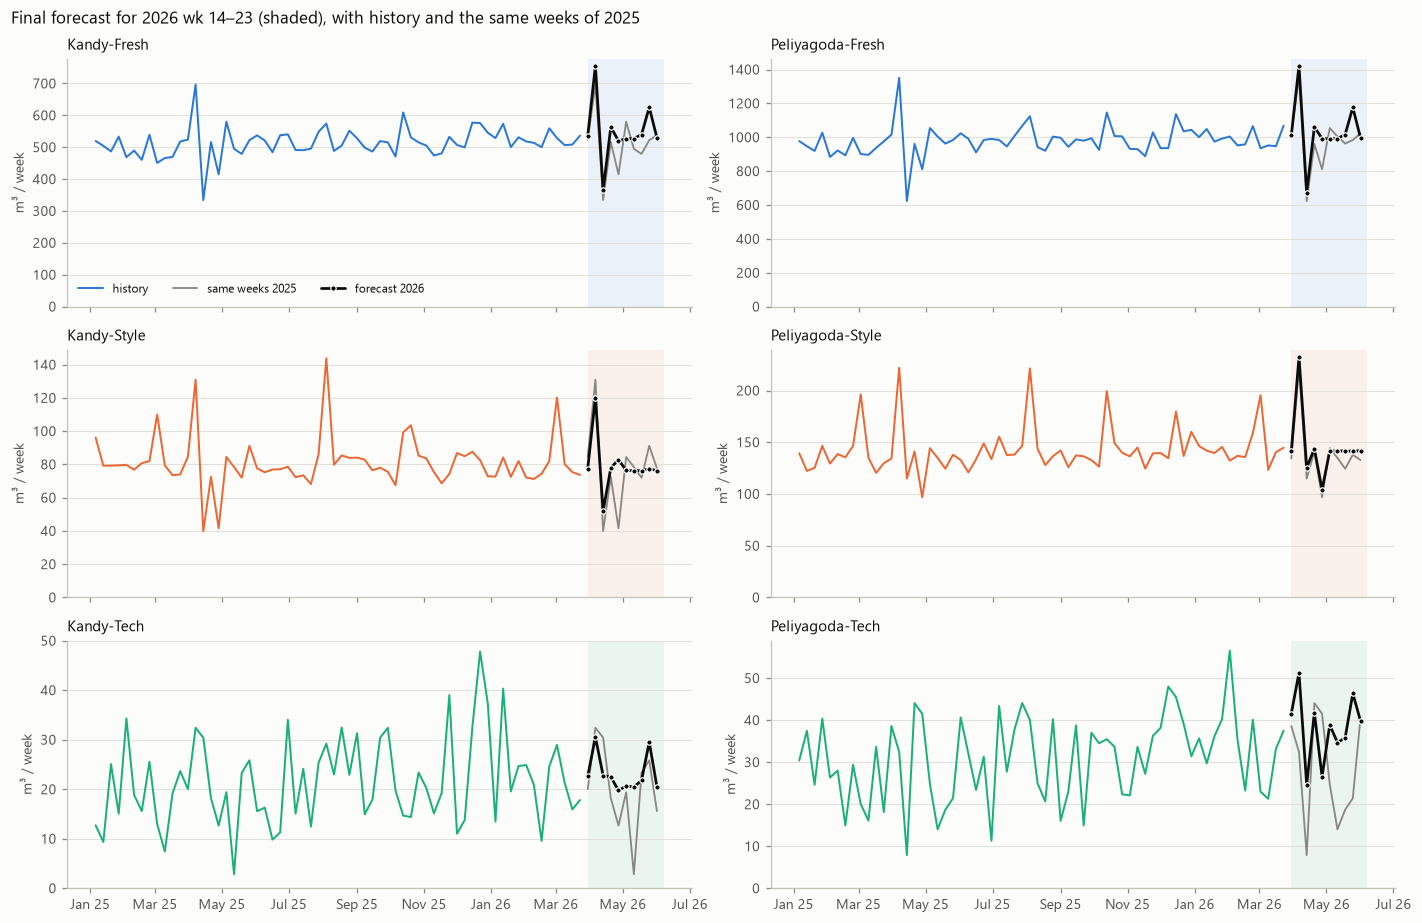

In [65]:
hist_w = wk[(wk.is_future == 0) & (wk.week_start >= "2025-01-01")]
fut["week_start"] = fut.week_idx.map(week_start)
fig, axes = plt.subplots(3, 2, figsize=(13, 8.5), sharex=True)
for ax, s in zip(axes.flat, SERIES_ORDER):
    col = BRAND_COLOR[s.split("-")[1]]
    h_ = hist_w[hist_w.series == s]
    f_ = fut[fut.series == s].sort_values("week_idx")
    ly_ = wk[(wk.series == s) & wk.week_idx.isin(f_.week_idx - 52)].sort_values("week_idx")
    ax.axvspan(f_.week_start.min(), f_.week_start.max() + pd.Timedelta(days=6), color=col, alpha=0.08, lw=0)
    ax.plot(h_.week_start, h_.total_vol, color=col, lw=1.3, label="history")
    ax.plot(f_.week_start, ly_.total_vol.to_numpy(), color=MUTED, lw=1.2, label="same weeks 2025")
    ax.plot(f_.week_start, f_.pred_total, color=INK, lw=1.8, marker="o", ms=3.5, mec=SURFACE, mew=0.8, label="forecast 2026")
    ax.set_title(s, loc="left")
    ax.set_ylim(0, None)
    ax.set_ylabel("m³ / week")
axes[-1, 0].xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
axes[0, 0].legend(loc="lower left", ncol=3, fontsize=8)
fig.suptitle("Final forecast for 2026 wk 14–23 (shaded), with history and the same weeks of 2025", x=0.01, ha="left", fontsize=11)
fig.tight_layout()
save(fig, "p7_01_final_forecast")


### 7.3 Phase 7 summary

**Saved in `models/task2a/`** (alongside the notebook, as the booklet asks):

| File | Content |
|---|---|
| `structural_model.json` | Every learned number of the structural model: level per series, weekday factors, payday uplift per brand, festival slope per brand × festival, the Tech pooled slope, and the growth setting. Human-readable. |
| `lgbm_model.txt` | The LightGBM model (400 trees, trained on 5,970 rows). Used for Tech. |
| `phase6_selection.json` | Which model each brand uses (Fresh and Style: Structural + growth; Tech: LightGBM), plus the validation scores. |
| `manifest.json` | Training period, origin, the inputs needed at inference, and library versions. |

**Submission:** `submissions/submission_task2a.csv`, 60 rows in template order. Total 18,685 m³, of which 5,956 m³ chilled.

**Checks:**
- **Rules:** 60 rows; no NaN or negatives; chilled = 0 for Style and Tech; chilled ≤ total.
- **Reproducibility:** the standalone pipeline reproduces the validated forecast exactly.
- **Shape (Peliyagoda-Fresh):**

  | Week | Forecast (m³) | Why |
  |---|---|---|
  | wk 15 | 1,423 | New Year run-up |
  | wk 16 | 674 | Mon and Tue closed |
  | wk 18 | 993 | Fri 1 May closed, partly offset by the Vesak run-up |
  | wk 22 | 1,176 | Poson's whole run-up plus 2 paydays |

**Totals vs the same weeks of 2025:**
- **Fresh +5.6% (Peliyagoda) and +7.7% (Kandy).** This is the series' own year-on-year growth (1.06, 1.08). Against 2025 × growth the gap is only −0.8% and −0.3%. The window also has more run-up on open days than in 2025 (12.5 vs 10.5), because all of Poson's run-up falls inside it.
- **Style +2.5% and +5.2%.** This is within Style's normal noise of about 10%.
- **Tech +15% (Kandy) and +34% (Peliyagoda).** Tech really has grown: Peliyagoda-Tech averaged 34.1 m³ a week in 2026 wk 1–13, against 26.6 in 2025 wk 1–13 (+28%). Against 2025 × growth it is −7%. Tech remains about ±30% noise.

**For the team's final notebook:** copy cell 7.4 as the last cell, next to the Task 1 inference. It needs only the files listed in `manifest.json`.

### 7.4 Final cell: Task 2A inference pipeline (standalone)

Uses only files on disk: the saved models in `models/task2a/`, the test inputs, the template, and the prepared features and calendar in `data/processed/`. No variable from earlier cells is needed. Steps:
1. Load the three model files.
2. Build the inputs for the 60 test rows: test inputs ⨝ features at the 2026 wk 13 origin, plus the daily calendar of wk 14–23.
3. Structural: day by day, summed per week, then the growth correction.
4. LightGBM: ratio × (`lvl13 × dow_weight`).
5. Per-brand choice from `phase6_selection.json`; chilled = total × last year's share (Fresh), 0 otherwise.
6. Validate, print the inputs and predictions, and write `submissions/submission_task2a.csv` in the template's row order.

In [66]:
# ======================= TASK 2A INFERENCE (standalone) =======================
import json
from pathlib import Path

import lightgbm as lgb
import numpy as np
import pandas as pd


def _project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "data" / "raw").is_dir():
            return p
    raise FileNotFoundError("project root with data/raw not found")


def run_task2a_inference(root: Path, out_csv: Path) -> pd.DataFrame:
    mdir, proc, raw = root / "models" / "task2a", root / "data" / "processed", root / "data" / "raw"
    keys = ["depot", "brand", "iso_year", "iso_week"]

    # 1. Saved models
    sm = json.loads((mdir / "structural_model.json").read_text())
    sel = json.loads((mdir / "phase6_selection.json").read_text())
    booster = lgb.Booster(model_file=str(mdir / "lgbm_model.txt"))
    origin = sm["origin"]["week_idx"]

    # 2. Inputs for the test rows
    test = pd.read_csv(raw / "Test Data" / "task2a_test_inputs.csv")
    template = pd.read_csv(raw / "Submission Templates" / "submission_task2a.csv")
    fo = pd.read_parquet(proc / "features_origin.parquet")
    X = test.merge(fo[fo.origin_idx == origin].drop(columns="row_id"), on=keys, how="left", validate="one_to_one")
    assert X.h.notna().all(), "missing features for some test rows"
    X["series"] = X.depot + "-" + X.brand
    X["is_fresh"], X["is_style"], X["is_kandy"] = (X.brand == "Fresh") * 1, (X.brand == "Style") * 1, (X.depot == "Kandy") * 1

    cal = pd.read_parquet(proc / "calendar.parquet").sort_values("date")
    fest = cal[cal.festival.fillna("") != ""][["date", "festival"]].reset_index(drop=True)
    days = cal.merge(test[["iso_year", "iso_week"]].drop_duplicates(), on=["iso_year", "iso_week"])
    pos = np.minimum(np.searchsorted(fest.date.to_numpy(), days.date.to_numpy()), len(fest) - 1)
    days["ramp_fest"] = np.where(days.festival_ramp > 0, fest.festival.to_numpy()[pos], "")
    days = days[days.is_operating == 1]
    days = days.merge(X[["series", "depot", "brand"]].drop_duplicates(), how="cross")

    # 3. Structural, day by day
    f = days.apply(lambda r: sm["dow_factor"][r.series].get(str(r.dow), 0.0), axis=1)
    p = days.brand.map(sm["payday_uplift"])
    b = [sm["festival_slope_pooled"][br] if (br in sm["pooled_slope_brands"] or fz not in sm["festival_slope"].get(br, {}))
         else sm["festival_slope"][br][fz] for br, fz in zip(days.brand, days.ramp_fest)]
    days["pred_day"] = days.series.map(sm["level_L"]) * f * (1 + p * days.is_payday) * (1 + np.array(b) * days.festival_ramp)
    X = X.merge(days.groupby(["series", "iso_year", "iso_week"]).pred_day.sum().rename("STRUCT").reset_index(),
                on=["series", "iso_year", "iso_week"], how="left")
    g = sm["growth"]
    X["STRUCT_G"] = X.STRUCT * np.where(X.brand.isin(g["brands"]), X.yoy8.fillna(1.0) ** ((X.h + g["lag_weeks"]) / 52), 1.0)

    # 4. LightGBM
    X["LGBM"] = X.lvl13 * X.dow_weight * booster.predict(X[booster.feature_name()])

    # 5. Per-brand choice and chilled
    X["pred_total_volume_m3"] = 0.0
    for brand, weights in sel["blend_per_brand"].items():
        m = X.brand == brand
        X.loc[m, "pred_total_volume_m3"] = sum(w * X.loc[m, col] for col, w in weights.items())
    X["pred_total_volume_m3"] = X.pred_total_volume_m3.clip(lower=0)
    share = X.share_ly_target.fillna(X.share_recent6)
    X["pred_chilled_volume_m3"] = np.where(X.brand == "Fresh", X.pred_total_volume_m3 * share, 0.0)

    # 6. Validate and write, in the template's row order
    sub = template[["row_id"]].merge(X[["row_id", "pred_total_volume_m3", "pred_chilled_volume_m3"]], on="row_id", how="left")
    assert list(sub.columns) == list(template.columns) and sub.row_id.tolist() == template.row_id.tolist()
    assert len(sub) == 60 and sub.notna().all().all() and (sub.iloc[:, 1:] >= 0).all().all()
    assert (sub.pred_chilled_volume_m3 <= sub.pred_total_volume_m3).all()
    assert (X.loc[X.brand != "Fresh", "pred_chilled_volume_m3"] == 0).all()
    out_csv.parent.mkdir(parents=True, exist_ok=True)
    sub.round(4).to_csv(out_csv, index=False)

    show_in = ["row_id", "depot", "brand", "iso_week", "h", "n_operating_days", "n_paydays_operating", "ramp_sum_operating",
               "near_festival", "lvl13", "dow_weight", "yoy8", "share_ly_target"]
    show_out = ["row_id", "STRUCT", "STRUCT_G", "LGBM", "pred_total_volume_m3", "pred_chilled_volume_m3"]
    with pd.option_context("display.max_rows", 100, "display.width", 200):
        print(f"Models: {mdir.relative_to(root)} | origin {sm['origin']['iso_year']} wk {sm['origin']['iso_week']} "
              f"| choice per brand: { {k: v for k, v in sel['blend_per_brand'].items()} }\n")
        print("INPUTS (one row per test row):")
        print(X[show_in].round(3).to_string(index=False))
        print("\nPREDICTIONS (m³):")
        print(X[show_out].round(2).to_string(index=False))
    print(f"\nWrote {out_csv.relative_to(root)}: {len(sub)} rows, total {sub.pred_total_volume_m3.sum():,.1f} m³, "
          f"chilled {sub.pred_chilled_volume_m3.sum():,.1f} m³")
    return X


ROOT_DIR = _project_root(Path.cwd().resolve())
task2a_out = run_task2a_inference(ROOT_DIR, ROOT_DIR / "submissions" / "submission_task2a.csv")

# Cross-check against the validated in-memory forecast, when this notebook ran end to end
if "preds" in globals():
    ref = preds[(preds.origin_idx == ORIGIN_IDX) & (preds.model == "FINAL")].set_index("row_id")
    chk = task2a_out.set_index("row_id")
    assert np.allclose(chk.pred_total_volume_m3, ref.pred_total.reindex(chk.index), rtol=1e-6, atol=1e-6)
    assert np.allclose(chk.pred_chilled_volume_m3, ref.pred_chilled.reindex(chk.index), rtol=1e-6, atol=1e-6)
    print("Cross-check: the saved-model pipeline reproduces the validated FINAL forecast exactly.")


Models: models\task2a | origin 2026 wk 13 | choice per brand: {'Fresh': {'STRUCT_G': 1.0, 'LGBM': 0.0}, 'Style': {'STRUCT_G': 1.0, 'LGBM': 0.0}, 'Tech': {'STRUCT': 0.0, 'LGBM': 1.0}}

INPUTS (one row per test row):
row_id      depot brand  iso_week  h  n_operating_days  n_paydays_operating  ramp_sum_operating near_festival   lvl13  dow_weight  yoy8  share_ly_target
 W0000      Kandy Fresh        14  1                 6                    1                 0.1      new_year  86.619       6.000 1.080            0.363
 W0001      Kandy Style        14  1                 6                    1                 0.1      new_year  12.852       6.000 0.976              NaN
 W0002      Kandy  Tech        14  1                 6                    1                 0.1      new_year   3.467       6.000 1.041              NaN
 W0003 Peliyagoda Fresh        14  1                 6                    1                 0.1      new_year 163.661       6.000 1.064            0.380
 W0004 Peliyagoda St